In [4]:
# Import necessary libraries
import pandas as pd
from collections import defaultdict
import geopandas as gpd
from shapely import wkt
import shapely

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
%matplotlib inline
import datetime
import time
import numpy as np
import xml.etree.ElementTree as ET 
import matsim

import utm
from shapely.geometry import Polygon, Point
import gzip
from matplotlib import cm

import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
import matplotlib as mpl
from matplotlib.lines import Line2D
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap
import json



In [16]:
with open('input/regionclusters.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    regionclusters = pd.read_pickle(pickle_file)

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}


# Wende die Funktion auf die Spalte raumtyp an und erstelle die neue Spalte area_type
regionclusters['area_type_agg'] = regionclusters['raumtyp'].apply(determine_area_type)
regionclusters['area_type'] = regionclusters['raumtyp'].astype(str).map(category_dict)

# Explode the multipolygons into individual polygons
regionclusters_split = regionclusters.explode(index_parts=False)

# Reset index to clean up the DataFrame
regionclusters_split.reset_index(drop=True, inplace=True)

# Ensure regionclusters_split has a unique 'id' column for each geometry
if 'id' not in regionclusters_split.columns:
    regionclusters_split = regionclusters_split.reset_index().rename(columns={'index': 'id'})


# Display the resulting DataFrame
regionclusters_split

C:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


,id,name,raumtyp,area_type_agg,area_type,geometry
0,0,Metropoles Zentrum,1,Urban,Metropolitan Center,"POLYGON ((550245.757 5803780.217, 550498.506 5..."
1,1,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((551841.918 5799807.714, 551822.177 5..."
2,2,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((548246.648 5803396.842, 548436.729 5..."
3,3,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((551382.558 5803547.894, 551322.051 5..."
4,4,Zentrumsnah verdichtete Mischnutzung,3,Urban,Dense Mixed Use,"POLYGON ((550296.319 5800661.942, 550326.482 5..."
...,...,...,...,...,...,...
92,92,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((555171.141 5811301.777, 555348.531 5..."
93,93,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((553603.43 5818427.593, 553504.77 581..."
94,94,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((569144.127 5792666.928, 569149.889 5..."
95,95,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((567727.813 5795421.313, 567684.597 5..."


In [54]:
# --- Demand-Shape einlesen (Dienstag) ---
demand_path = "input/hagrid_parcel_demand_2025-05-13_(Tuesday).shp"
parcel_input_demand_tuesday = gpd.read_file(demand_path)
# CRS prüfen
assert parcel_input_demand_tuesday.crs.to_epsg() == 25832, "Demand CRS ist nicht EPSG:25832"

demand_agg = parcel_input_demand_tuesday.groupby("name")[["dhl_b2b", "dhl_b2c"]].sum()
demand_agg["total_dhl"] = demand_agg["dhl_b2b"] + demand_agg["dhl_b2c"]

In [6]:
# Read the CSV file
folder = "input/"
areas = pd.read_csv( folder + "plz_areas.csv")  

# Convert the 'WKT' column to Shapely MultiPolygon geometry
areas['geometry'] = areas['WKT'].apply(lambda wkt_str: wkt.loads(wkt_str))

# Create a GeoDataFrame
gdf_areas = gpd.GeoDataFrame(areas, geometry='geometry')

# Set the coordinate reference system (CRS)
gdf_areas.crs = 'EPSG:25832'  # Set the appropriate CRS if it's different


# Import Network
# MATSim network als Geopandas dataframe inkl. LINESTRINGS einlesen
# network = matsim.read_network('D:\\Hannover Daten\\MatSim\\Network XT\\car_network_encfix.xml.gz').as_geo().set_crs('epsg:25832') # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
network = matsim.read_network('input/car_network_encfix.xml.gz').as_geo().set_crs('epsg:25832')
# dict mit Netzwerk Link Längen
# link_length = network[['link_id', 'length']].set_index('link_id').to_dict()['length']
network.head()

# falls vorhanden Ergebnisse der nächsten Zellen laden, sonst überspringen
with open('input/regionclusters.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    regionclusters = pd.read_pickle(pickle_file)
with open('input/networkplus.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    networkplus = pd.read_pickle(pickle_file)     




C:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


In [7]:
link_length = network[['link_id', 'length']].set_index('link_id').to_dict()['length']
link_geometry = network[['link_id', 'geometry']].set_index('link_id').to_dict()['geometry']
# dict mit Netzwerk Link Raumtypen
link_raumtyp = networkplus['raumtyp'].to_dict()

In [8]:
# Create a dictionary linking each area type code to its description
area_type_dict = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

from matplotlib.colors import to_hex
# Define the desired order of legend labels in English
# Create a dictionary linking each category to a color



category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}



category_color_dict_num = {
    0: "#482878",
    1: "#3f4989",
    2: "#31688e",
    3: "#26828e",
    4: "#1f9e89",
    5: "#35b779",
    6: "#6fce58",
    7: "#b5de2b"
}



# Create a dictionary linking each category to a color
category_color = {category: i / (len(category_color_dict) - 1) for i, category in enumerate(category_color_dict)}

# Create the colormap
cmap = LinearSegmentedColormap.from_list("custom_cmap", sns.color_palette("viridis_r", len(category_color_dict))[::-1])

# Convert the colormap to a dictionary
palette_dict = {cat: to_hex(cmap(category_color[cat])) for cat in category_color_dict}


In [61]:
# --- Calculate parcel delivery density per area type (parcels/km², 8 area types) ---
import geopandas as gpd

# 1. Assign area type to each point via spatial join
parcel_input_demand_tuesday = gpd.sjoin(
    parcel_input_demand_tuesday,
    regionclusters[['geometry', 'raumtyp']],
    how='left', predicate='within')

# 2. Optionally assign area type name
category_dict_int = {int(k): v for k, v in category_dict.items()}
parcel_input_demand_tuesday['main_area_type_name'] = parcel_input_demand_tuesday['raumtyp'].map(category_dict_int)

# 3. Calculate total parcels per point (sum of all B2B/B2C columns)
carrier_cols = ['ama_b2b','ama_b2c','dhl_b2b','dhl_b2c','dpd_b2b','dpd_b2c','fxt_b2b','fxt_b2c','gls_b2b','gls_b2c','her_b2b','her_b2c','ups_b2b','ups_b2c']
parcel_input_demand_tuesday['total_parcels'] = parcel_input_demand_tuesday[carrier_cols].sum(axis=1)

# 4. Area per area type (in km²)
if regionclusters.crs.to_epsg() != 25832:
    regionclusters = regionclusters.to_crs(25832)
    
regionclusters['area_km2'] = regionclusters.geometry.area / 1e6  # m² -> km²
area_by_type = regionclusters.groupby('raumtyp')['area_km2'].sum()

# area_by_type = regionclusters.groupby('raumtyp').geometry.area / 1e6  # m² -> km²

# 5. Total parcels per area type
parcels_by_type = parcel_input_demand_tuesday.groupby('raumtyp')['total_parcels'].sum()

# 6. Parcel delivery density per area type (parcels/km²)
density = (parcels_by_type / area_by_type).rename('parcels_per_km2')

# 7. Output as DataFrame, sorted by area type 1-8
density_df = density.reset_index()
density_df['area_type'] = density_df['raumtyp'].map(category_dict_int)
density_df = density_df.sort_values('raumtyp')
density_df = density_df[['raumtyp','area_type','parcels_per_km2']]
density_df['parcels_per_km2'] = density_df['parcels_per_km2'].round(1)
density_df

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\1871155891.py:5: FutureWarning: Passing 'suffixes' which cause duplicate columns {'raumtyp_left'} in the result is deprecated and will raise a MergeError in a future version.
  parcel_input_demand_tuesday = gpd.sjoin(


KeyError: 'raumtyp'

In [58]:
# --- Parcel delivery density per regionclusters_split geometry (fine-grained, not aggregated by raumtyp) ---
import geopandas as gpd

# Ensure CRS is correct
if regionclusters_split.crs.to_epsg() != 25832:
    regionclusters_split = regionclusters_split.to_crs(25832)

# 1. Spatial join: assign regionclusters_split geometry to each parcel point
parcel_input_demand_tuesday = gpd.sjoin(
    parcel_input_demand_tuesday,
    regionclusters_split[['geometry', 'id', 'raumtyp']],
    how='left', predicate='within', rsuffix='_split')

# 2. Calculate total parcels per point (already present as 'total_parcels')

# 3. Area per regionclusters_split geometry (in km²)
regionclusters_split['area_km2'] = regionclusters_split.geometry.area / 1e6

# 4. Total parcels per regionclusters_split geometry
parcels_by_geom = parcel_input_demand_tuesday.groupby('id')['total_parcels'].sum()

# 5. Parcel delivery density per regionclusters_split geometry (parcels/km²)
density_split = (parcels_by_geom / regionclusters_split.set_index('id')['area_km2']).rename('parcels_per_km2')

# 6. Output as DataFrame, sorted by id
density_split_df = density_split.reset_index()
density_split_df = density_split_df.merge(regionclusters_split[['id', 'raumtyp']], on='id', how='left')
density_split_df['parcels_per_km2'] = density_split_df['parcels_per_km2'].round(1)
density_split_df = density_split_df[['id', 'raumtyp', 'parcels_per_km2']]


print("Density Median: ", density_split_df["parcels_per_km2"].median())


Density Median:  63.7


In [ ]:
# def Methoden

# vehicle string pattern
def parse_events(event_file):
    """
    This function parses events from a given event file. It filters out events of type 'left link' and 'actstart'.
    It also counts the number of events for different types of vehicles and stores the last link for each vehicle.
    
    Args:
        event_file (str): The path to the event file to be parsed.
        
    Returns:
        vehicle_tour (dict): A dictionary mapping each vehicle to a list of links in its tour.
        service_events (dict): A dictionary mapping each person to a list of service events.
        network_volumes (DataFrame): A DataFrame containing the counts of each type of vehicle on each link.
    """
    
    # Only returns events of type 'left link' and 'actstart:
    events = matsim.event_reader(event_file, types='left link,actstart')

    # defaultdict creates a blank dict entry on first reference; similar to {} but more friendly
    link_counts_trucks = defaultdict(int)
    link_counts_vans = defaultdict(int)
    link_counts_bikes = defaultdict(int)
    link_counts_cars = defaultdict(int)

    vehicle_tour = defaultdict(list)
    service_events = defaultdict(list)
    last_link = defaultdict(str)
    
    vehicle_services = defaultdict(list)

    for event in events:
        # skip next day events
        if event['time'] > DAYEND: continue

        # on link left
        if event['type'] == 'left link':
            vehicle = event['vehicle']
            # fix broken ID encodings in basecase
            # vehicle = vehicle.encode('Windows 1252').decode('UTF-8') # für die Auswertung egal
            # identify CEP truck
            if '_Supply_Vehicle_' in vehicle or '_veh_supply_' in vehicle:
                if event['link'] != last_link[vehicle]:
                    link_counts_trucks[event['link']] += 1
                    vehicle_tour[vehicle].append(event['link'])
                    last_link[vehicle] = event['link']
            # identify vans (CEP & eGrocery)
            elif '_CEP_Vehicle_' in vehicle or '_veh_cep_' in vehicle or '_egrocery_van_' in vehicle:
                if event['link'] != last_link[vehicle]:
                    link_counts_vans[event['link']] += 1
                    vehicle_tour[vehicle].append(event['link'])
                    last_link[vehicle] = event['link']
            # identify bikes
            elif '_cargoBike_' in vehicle or '_cargobike_' in vehicle:
                if event['link'] != last_link[vehicle]:
                    link_counts_bikes[event['link']] += 1
                    vehicle_tour[vehicle].append(event['link'])
                    last_link[vehicle] = event['link']
        elif event['type'] == 'actstart':
            person = event['person']
            # fix broken ID encodings in basecase
            # person = person.encode('Windows 1252').decode('UTF-8') # für die Auswertung egal
            # catch last tour link
            if event['actType'] == 'end':
            # identify CEP truck persons
                if '_Supply_Vehicle_' in person or '_veh_supply_' in person:
                    link_counts_trucks[event['link']] += 1
                    vehicle_tour[person].append(event['link'])
                # identify van persons
                elif '_CEP_Vehicle_' in person or '_veh_cep_' in person or '_egrocery_van_' in person:
                    link_counts_vans[event['link']] += 1
                    vehicle_tour[person].append(event['link'])
                # identify bike persons
                elif '_cargoBike_' in person or '_cargobike_' in vehicle:
                    link_counts_bikes[event['link']] += 1
                    vehicle_tour[person].append(event['link'])
            # catch services
            elif event['actType'] == 'service':
                service_events[person].append(event['link'])
                vehicle_services[person].append(event)
    


    # convert link_counts dict to a pandas dataframe
    link_counts_trucks = pd.DataFrame.from_dict(link_counts_trucks, orient='index', columns=['truck_count']).rename_axis('link_id')
    link_counts_vans = pd.DataFrame.from_dict(link_counts_vans, orient='index', columns=['van_count']).rename_axis('link_id')
    link_counts_bikes = pd.DataFrame.from_dict(link_counts_bikes, orient='index', columns=['bike_count']).rename_axis('link_id')
    link_counts_cars = pd.DataFrame.from_dict(link_counts_cars, orient='index', columns=['car_count']).rename_axis('link_id')

    # attach counts to our Geopandas network from above
    network_volumes = network.merge(link_counts_trucks, on='link_id', how='left').merge(link_counts_vans, on='link_id', how='left').merge(link_counts_bikes, on='link_id', how='left').merge(link_counts_cars, on='link_id', how='left')
    network_volumes['car_count'] = network_volumes['car_count'].fillna(0)
    network_volumes['truck_count'] = network_volumes['truck_count'].fillna(0)
    network_volumes['van_count'] = network_volumes['van_count'].fillna(0)
    network_volumes['bike_count'] = network_volumes['bike_count'].fillna(0)
    network_volumes['total_count'] = network_volumes['truck_count'] + network_volumes['van_count'] + network_volumes['bike_count']

    return vehicle_tour, service_events, network_volumes, vehicle_services


def vehicle_stats(vehicle_tour, service_events):
    """
    This function calculates statistics for each vehicle, including the number of services, total tour length,
    distance to the first service, and distribution of services over different types of areas.
    
    Args:
        vehicle_tour (dict): A dictionary mapping each vehicle to a list of links in its tour.
        service_events (dict): A dictionary mapping each person to a list of service events.
        
    Returns:
        veh_df (DataFrame): A DataFrame containing statistics for each vehicle.
    """
        
    # init Ergebnis Objekte
    vehicle_stats = list()

    # Loop über Fahrzeuge und ihre Services
    for veh, ser in service_events.items():
        # Unterscheidung Fahrzeugtypen
        if '_Supply_Vehicle_' in veh or '_veh_supply_' in veh:
            c = 'truck'            
        if '_CEP_Vehicle_' in veh or '_veh_cep_' in veh or '_egrocery_van_' in veh:
            c = 'van'
        if '_cargoBike_' in veh or '_cargobike_' in veh:
            c = 'bike'
        
        # tourlen = 0
        # firstservicedist = None
        # # Loop über alle Tourlinks des Fahrzeuges
        # for link in vehicle_tour[veh]:
        #     # falls erster Service erreicht, Strecke bis dahin speichern
        #     if link == ser[0] and firstservicedist is None:
        #         firstservicedist = tourlen
        #     # Streckenlänge aufsummieren
        #     tourlen += link_length[link]
        # # Sonderfälle abfangen, wo ein Service kurz vor Tagesende beginnt und am nächsten Tag weitergefahren wird
        # if firstservicedist is None: firstservicedist = tourlen

        tourlen = 0
        firstservicedist = None
        service_dists = dict()

        visited_links = vehicle_tour[veh]
        if not ser:
            continue

        for link in visited_links:
            # Strecke aufsummieren
            link_km = link_length[link] / 1000  # Direkt km
            tourlen += link_km
            for s in ser:
                # Sobald Servicepunkt erreicht (einmalig erfassen)
                if link == s and s not in service_dists:
                    service_dists[s] = tourlen
                    if firstservicedist is None:
                        firstservicedist = tourlen  # Speichere ersten Treffer

        # Fallback: falls ein Service nicht in der Tour auftaucht
        for s in ser:
            if s not in service_dists:
                service_dists[s] = tourlen
        if firstservicedist is None:
            firstservicedist = tourlen
           
        indexService = 0
        start_service_distance_count = False
        currentServiceDist = 0
        serviceDistList= []    

        # Service Verteilung über Raumtypen ermitteln
        raumtypen_services = defaultdict(int)
        for s in ser:
            rt = link_raumtyp.get(s, 0) # keinem Raumtyp zugeordnet -> 0
            raumtypen_services[rt] += 1        
    

        summ_service_distances = 0
        previous_time = 0     


        vehicle_stats.append([
            veh, c, len(ser),
            tourlen ,
            firstservicedist ,
            raumtypen_services,
            service_dists,
            firstservicedist   # explizite Spalte für initial_delivery_distance
        ])


    # Dataframe aus Liste
    veh_df = pd.DataFrame(vehicle_stats, columns=[
        'vehicle_id', 'veh_class', 'service_num',
        'tour_km', 'first_service_dist',
        'raumsplit', 'service_dists',
        'initial_delivery_distance'
    ])

    return veh_df

# Definition of help-methods needed for the convertion process

# Method returning the index of an element of a dictionary
def get_nth_key(dictionary, n=0):
    """
    This function returns the nth key of a dictionary.
    
    Args:
        dictionary (dict): The dictionary to get the key from.
        n (int): The index of the key to get. Default is 0.
        
    Returns:
        key: The nth key of the dictionary.
    """
        
    if n < 0:
        n += len(dictionary)
    for i, key in enumerate(dictionary.keys()):
        if i == n:
            return key
    raise IndexError("dictionary index out of range") 

    
# Get Logistic Provider from XML ID
def getProviderFromID(carrierID):
    """
    This function returns the provider name based on the carrier ID.
    
    Args:
        carrierID (str): The ID of the carrier.
        
    Returns:
        str: The name of the provider.
    """
        
    if("dhl" in str(carrierID)):
        return "dhl"  
    elif("amazon" in str(carrierID)):
        return "amazon"  
    elif("ups" in str(carrierID)):
        return "ups"  
    elif("gls" in str(carrierID)):
        return "gls"  
    elif("dpd" in str(carrierID)):
        return "dpd"  
    elif("fedex" in str(carrierID)):
        return "fedex"  
    elif("hermes" in str(carrierID)):
        return "hermes"  
    elif("wl" in str(carrierID)):
        return "White-Label"  
    else:
        raise ValueError('Carrier Provider unknown: ' + str(carrierID))
        
# Definition of needen Classes: Carrier, Vehicle, Plan & Service with Variables

# A carrier object has an ID and dictionaries with all Vehicles and all Services
class Carrier:  
    """
    This class represents a Carrier with an ID and dictionaries with all Vehicles and all Services.
    """
        
    def __init__(self, carrierID): 
        self.carrierID = carrierID 
        self.vehicles = {} 
        self.services = {}   
        self.missedDeliveries = []
        self.logisticProvider = getProviderFromID(self.carrierID)
        
    def __str__(self):
        return "[Carrier ID: " + str(self.carrierID) + " with " + str(len(self.vehicles)) + " Vehicles and " + str(len(self.services)) + " Services]"
    
    def __repr__(self):
        return self.__str__()
    
    def getNumberOfVehicles(self):
        return (len(self.vehicles))
    
    def getNumberOfServices(self):
        return (len(self.services))
        
    def addVehicle(self, vehicle): 
        self.vehicles[vehicle.getVehicleId] = vehicle
        
    def addService(self, service): 
        self.services[service.getServiceID] = service

    def getTotalNumberofServices(self):  
        return sum((s.getDemand() for s in self.services.values()))
    
    def getProvider(self):
        return self.logisticProvider
    
    def getServices(self): 
        return [s for s in self.services.values()]   
    
    def getCarrierId(self): 
        return self.carrierID    
    
    def getVehicles(self): 
        return self.vehicles
    
    def getMissedDeliveries(self): 
        return self.missedDeliveries  
    
    def setMissedDeliveries(self, missDeliveries): 
        self.missedDeliveries = missDeliveries


# A Vehicle has an ID, a Typ and you can add Plans to this vehicles with services and Routes. 
# These Vehicles / Plans have to be converted to Sumo! 
class Vehicle: 
    """
    This class represents a Vehicle with an ID, a Type and you can add Plans to this vehicles with services and Routes.
    """
        
    def __init__(self, vehicleID, vehicleType): 
        self.vehicleID = vehicleID 
        self.vehicleType = vehicleType 
        self.plans = []
        
    def __str__(self):
        return "[Vehicle ID: " + str(self.vehicleID) + " with Type: " + self.vehicleType +"]"
    
    def __repr__(self):
        return self.__str__()
    
    def addVehiclePlan(self, plan): 
        self.plans.append(plan)
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getVehicleId(self): 
        return self.vehicleID
    
    def getPlans(self):
        return self.plans


# A Plan is a sequence of Activies (start, service, service, ... , end)
# all important Information are stored in the activities / legs dictionary
# The Order of the sequence is stored as a list called "planSequence"
class Plan:  
    """
    This class represents a Plan which is a sequence of Activities (start, service, service, ... , end).
    """
        
    def __init__(self, planId, vehicle, activities, legs): 
        self.planId = planId
        self.vehicle = vehicle
        self.activities = activities 
        self.legs = legs 
        self.planSequence = [] 
        
    def __str__(self):
        return "[Plan ID: " + str(self.planId) + " with " + str(len(self.activities)) +" Activities and " + str(len(self.legs)) + " Legs]"
    
    def __repr__(self):
        return self.__str__()
    
    def getPlanSequence(self):
        return self.planSequence
    
    def createInternalPlanSequence(self):
        for i in range (len(self.legs)):            
            self.planSequence.append(get_nth_key(self.activities, i))
            self.planSequence.append(get_nth_key(self.legs, i))
        self.planSequence.append(get_nth_key(self.activities, len(self.activities)-1))    

# A Service is a data Container storing all availble Infomation from the CSV-File
class Service(): 
    """
    This class represents a Service which is a data Container storing all available Information from the CSV-File.
    """
        
    def __init__(self, serviceType , serviceID, capacityDemand, duration, link, extra_attributes=None):
        self.serviceType = serviceType
        self.serviceID = serviceID 
        self.capacityDemand = capacityDemand 
        self.duration = duration 
        self.link = link 
        self.extra_attributes = extra_attributes or {}
        
    def __str__(self):
        return "[Service ID: " + str(self.serviceID) + "(Type: " + str(self.serviceType) + ") with a CapacityDemand of " + str(self.capacityDemand) +" to Link: " + str(self.link) + "]"
    
    def __repr__(self):
        return self.__str__()

    def getAttribute(self, key, default=None):
        return self.extra_attributes.get(key, default)
    
    def getServiceType(self): 
        return self.serviceType
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getDemand(self): 
        return self.capacityDemand
        
    def getServiceID(self): 
        return self.serviceID
    
    def getServiceLink(self): 
        return self.link
    
def extract_provider(vehicle_id):
    """
    This function extracts the provider from the vehicle ID.
    
    Args:
        vehicle_id (str): The ID of the vehicle.
        
    Returns:
        str: The name of the provider.
    """
        
    return vehicle_id.split("_")[1]

def extract_veh_size(vehicle_id):
    """
    Extracts the vehicle size from the vehicle ID by looking for 'size_' and returning the next token.
    
    Args:
        vehicle_id (str): The ID of the vehicle.
        
    Returns:
        str: The vehicle size (e.g., 'l', 'm', 'l'), or 'unknown' if not found.
    """
    try:
        parts = vehicle_id.split("size_")
        if len(parts) > 1:
            return parts[1].split("_")[0]
        else:
            return "unknown"
    except Exception as e:
        print(f"Error extracting vehicle size from '{vehicle_id}': {e}")
        return "unknown"

def extract_main_area_type(raumsplit):
    """
    This function extracts the main area type from the raumsplit.
    
    Args:
        raumsplit (dict): The dictionary containing the raumsplit.
        
    Returns:
        str: The main area type.
    """
        
    return max(raumsplit.items(), key=lambda x: x[1])[0]

def process_vehicle_data(veh_df_van):
    """
    This function processes the vehicle data and adds provider, vehicle size, and main area type to the DataFrame.
    
    Args:
        veh_df_van (DataFrame): The DataFrame containing the vehicle data.
        
    Returns:
        DataFrame: The processed DataFrame.
    """
        
    veh_df_van['provider'] = veh_df_van['vehicle_id'].apply(extract_provider)
    veh_df_van['veh_size'] = veh_df_van['vehicle_id'].apply(extract_veh_size)
    veh_df_van['main_area_type'] = veh_df_van['raumsplit'].apply(extract_main_area_type)

    return veh_df_van

def get_vehicles(vehicle_tour):
    """
    This function gets the vehicles from the vehicle tour.
    
    Args:
        vehicle_tour (dict): The dictionary containing the vehicle tour.
        
    Returns:
        list: The list of vehicles.
    """
        
    return [vehicle for vehicle in vehicle_tour if "_supply_" not in vehicle]

def create_plot_data(vehicles, event_file):
    """
    This function creates the plot data.
    
    Args:
        vehicles (list): The list of vehicles.
        event_file (str): The path to the event file.
        
    Returns:
        DataFrame: The DataFrame containing the plot data.
    """
        
    plot_data = pd.DataFrame({
    "Start time" : [0],
    "End time" : [0],
    "Tour Duration" : [0],
    "Service Duration" : [0],
    "Travel Duration" : [0],
    }, index=[vehicles,])

    #calculate start and end time
    events = matsim.event_reader(event_file, types='actstart,actend')
    event_lists = { 'start': [], 'end': [] }

    for event in events:
        if "_supply_" in event["person"]:
            continue
        if event['actType'] == "start" and event['type'] == "actend":
            event_lists['start'].append(event)
        if event['actType'] == "end" and event['type'] == "actstart":
            event_lists['end'].append(event)
    df_start = pd.DataFrame(event_lists['start'])
    df_end = pd.DataFrame(event_lists['end'])

    for event in range(len(df_start)):
            plot_data["Start time"][df_start.iloc[event]["person"]] = df_start.iloc[event]['time']
    for event in range(len(df_end)):
            plot_data["End time"][df_end.iloc[event]["person"]] = df_end.iloc[event]['time']


    #calculate travel time - need to remove the service time
    events = matsim.event_reader(event_file, types='actstart,actend')
    event_lists = { 'start': [], 'end': [] }

    for event in events:
        if "_supply_" in event["person"]:
            continue
        if event['actType'] == "service" and event['type'] == "actend":
            event_lists['start'].append(event)
        if event['actType'] == "service" and event['type'] == "actstart":
            event_lists['end'].append(event)
    df_start = pd.DataFrame(event_lists['start'])
    df_end = pd.DataFrame(event_lists['end'])

    for row in range(len(plot_data)):
        plot_data.iloc[row]["Tour Duration"] = plot_data.iloc[row]["End time"] - (plot_data.iloc[row]["Start time"])

    startG = df_start.groupby("person")
    endG = df_end.groupby("person")

    for n,g in startG:
        time = 0

        g = g.reset_index(drop=True)   

        g2 = endG.get_group(n)
        g2 = g2.reset_index(drop=True)

        result = pd.merge(g, g2, left_index=True, right_index=True)

        for i in range(len(result)):
            time = time + (result.loc[i]["time_y"] - result.loc[i]["time_x"])

            plot_data.loc[n, "Service Duration"] = abs(time)

    for row in range(len(plot_data)):
        plot_data.iloc[row]["Travel Duration"] = plot_data.iloc[row]["Tour Duration"] - (plot_data.iloc[row]["Service Duration"])

    plot_data = plot_data.astype(str)
    # for row in range(len(plot_data)):
    #     plot_data.iloc[row]["Start time"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Start time"])))
    #     plot_data.iloc[row]["End time"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["End time"])))
    #     plot_data.iloc[row]["Tour Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Tour Duration"])))
    #     plot_data.iloc[row]["Service Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Service Duration"])))
    #     plot_data.iloc[row]["Travel Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Travel Duration"])))



    plot_data.reset_index(inplace=True)
    plot_data = plot_data.rename(columns={'level_0': 'vehicle_id'})

    plot_data["Start time formatted"] = pd.to_datetime(plot_data['Start time'], unit='s')
    plot_data["End time formatted"] = pd.to_datetime(plot_data['End time'], unit='s')
    plot_data["Tour Duration formatted"] = pd.to_datetime(plot_data['Tour Duration'], unit='s')
    plot_data["Service Duration formatted"] = pd.to_datetime(plot_data['Service Duration'], unit='s')
    plot_data["Travel Duration formatted"] = pd.to_datetime(plot_data['Travel Duration'], unit='s')

    plot_data["Start time"] = pd.to_numeric(plot_data["Start time"])
    plot_data["End time"] = pd.to_numeric(plot_data["End time"])
    plot_data["Tour Duration"] = pd.to_numeric(plot_data["Tour Duration"])
    plot_data["Service Duration"] = pd.to_numeric(plot_data["Service Duration"])
    plot_data["Travel Duration"] = pd.to_numeric(plot_data["Travel Duration"])
    
    return plot_data

def parse_carriers_from_xml(root):
    """
    This function parses carriers from an XML root.
    
    Args:
        root (ElementTree): The XML root to parse carriers from.
        
    Returns:
        list: The list of carriers.
    """

    carriers = []
    totalVeh = 0
    ns = {"m": "http://www.matsim.org/files/dtd"}

    for carrierXML in root.findall("m:carrier", ns):
        carrierID = carrierXML.attrib.get("id")
        if "supply" in carrierID:
            continue

        newCarrier = Carrier(carrierID)

        for attributeXML in carrierXML.findall("m:attributes", ns):
            for attribute in attributeXML.findall("m:attribute", ns):
                if attribute.attrib.get("name") == "missedParcelDeliveriesAsString":
                    missedParcels = attribute.text
                    missedParcels = missedParcels.replace("[", "").replace("]", "").replace(" ", "")
                    missedServicePerCarrier = missedParcels.split(",")
                    newCarrier.setMissedDeliveries(missedServicePerCarrier)

        for serviceXML in carrierXML.findall(".//m:service", ns):
            serviceID = serviceXML.attrib.get("id")

            serviceCapacityDemand = int(serviceXML.attrib.get("capacityDemand"))
            serviceDuration = serviceXML.attrib.get("serviceDuration")
            serviceLink = serviceXML.attrib.get("to")

            known_keys = {"id", "capacityDemand", "serviceDuration", "to"}
            extra_attrs = {k: v for k, v in serviceXML.attrib.items() if k not in known_keys}

            attributes_element = serviceXML.find("m:attributes", ns)
            if attributes_element is not None:
                for attr in attributes_element.findall("m:attribute", ns):
                    key = attr.attrib.get("name")
                    value = attr.text
                    if key in ["b2b", "b2c"]:
                        try:
                            value = int(value)
                        except ValueError:
                            value = 0
                    extra_attrs[key] = value

            newService = Service(
                "service",
                serviceID,
                serviceCapacityDemand,
                serviceDuration,
                serviceLink,
                extra_attributes=extra_attrs
            )
            newCarrier.addService(newService)

        for plan in carrierXML.findall(".//m:plan", ns):
            if plan.attrib.get("selected") == "true":
                i = 0
                for tour in plan.findall(".//m:tour", ns):
                    i += 1
                    vehID = tour.attrib.get("vehicleId") + "_" + str(i)
                    vehicle = Vehicle(vehID, "cep")                    

                    b = 0
                    c = 0

                    activities = {}
                    legs = {}
                    routes = {}

                    for act in tour.findall(".//m:act", ns):
                        actType = act.attrib.get("type")
                        if actType == "start":
                            activities[actType] = act
                        elif actType == "end":
                            activities[actType] = act
                        else:
                            actID = act.attrib.get("serviceId")
                            activities[actID] = act

                    for leg in tour.findall(".//m:leg", ns):
                        legs["leg_" + str(b)] = leg
                        b += 1

                    for route in tour.findall(".//m:route", ns):
                        if route.text is None:
                            routes["route_" + str(c)] = None
                        else:
                            routes["route_" + str(c)] = route.text.split(" ")
                        c += 1

                    for key, value in legs.items():
                        routeKey = "route_" + str(key.split("_")[1])
                        route = routes.get(routeKey)
                        value.attrib["route"] = route

                    vehiclePlan = Plan("plan_" + vehID, vehicle, activities, legs)
                    vehiclePlan.createInternalPlanSequence()
                    vehicle.addVehiclePlan(vehiclePlan)
                    newCarrier.addVehicle(vehicle)

                totalVeh += newCarrier.getNumberOfVehicles()

        carriers.append(newCarrier)

    return carriers



def calculate_costs(row):
    veh_time_cost = 22.87 / 3600  # Kosten pro Sekunde

    if "size_l" in row['vehicle_id']:
        veh_cap, veh_fix, veh_km_cost = 230, 189.15, 0.386
    elif "size_m" in row['vehicle_id']: 
        veh_cap, veh_fix, veh_km_cost = 165, 171.78, 0.372
    else:
        if "supply_light_van" in row['vehicle_id']:
            veh_cap, veh_fix, veh_km_cost = 230, 189.15, 0.386
        elif "light" in row['vehicle_id']:
            veh_cap, veh_fix, veh_km_cost = 1000, 550.63, 0.48643
        else:
            veh_cap, veh_fix, veh_km_cost = 2000, 618.55, 0.555126     
      
     
    vehicle_fix_cost = veh_fix
    vehicle_km_cost = row["tour_km"] * veh_km_cost
    vehicle_time_cost = row["Tour Duration"] * veh_time_cost

    overtime_seconds = max(0, row["Tour Duration"] - (7.5 * 3600))
    overtime_cost = overtime_seconds * veh_time_cost

    vehicle_cost = vehicle_fix_cost + vehicle_km_cost + overtime_cost

    return pd.Series([vehicle_fix_cost, vehicle_km_cost, vehicle_time_cost, overtime_cost, vehicle_cost])



def add_vehicle_demand_to_result(carriers, result):
    
    """
    This function adds vehicle demand to the result DataFrame.
    
    Args:
        carriers (list):The list of carriers.
        result (DataFrame): The DataFrame to add vehicle demand to.
        
    Returns:
        DataFrame: The DataFrame with added vehicle demand.
    """

    required_cols = [
        'deliveries', 'missed deliveries', 'b2b_ration', 'b2c_ration',
        'ration_check', 'vehicle_load_factor', 'vehicle_deliver_factor',
        'vehicle_fix_cost', 'vehicle_km_cost', 'vehicle_time_cost',
        'overtime_cost', 'vehicle_cost', 'service_num'
    ]
    for col in required_cols:
        if col not in result.columns:
            result[col] = np.nan
    expected_ids = []
    
        
    veh = 0
    fail = 0

    # 1. Create a new dictionary to hold vehicle-service mappings
    vehicle_services_dict = {}

    for c in carriers:
        missedDeliveries = c.getMissedDeliveries()
        missed_deliveries_set = set(missedDeliveries) 

        services = c.getServices()

        print(f"🔍 Carrier {c.getCarrierId()} has {len(c.getVehicles())} vehicles")
        
        
        for k, v in c.getVehicles().items():
            veh = veh + 1 
            result_df_id = "freight_" + c.getCarrierId()+"_veh_"+v.getVehicleId()     
            expected_ids.append(result_df_id)   
         
            veh_df_res = result[result.vehicle_id == result_df_id]    
            if (len(veh_df_res) != 1):
                print(result_df_id)
                fail = fail + 1    
                
            mask = result.vehicle_id == result_df_id
            if mask.sum() == 0:
                print(f"⚠️ ID not found in result: {result_df_id}")   
            
            totalVehDemand = 0            
            missedParcels = 0

            b2b = 0
            b2c = 0

            # 2. Extract services for this vehicle
            veh_services = []
            services_dict = {s.getServiceID(): s for s in services}

            for a in v.getPlans()[0].activities:
                if "service" in a:
                    for s in services:
                        if a == s.getServiceID():
                            service = services_dict.get(a)
                            veh_services.append(service)

                            service_id = s.getServiceID()
                            service_b2b = int(s.getAttribute("b2b", 0))
                            service_b2c = int(s.getAttribute("b2c", 0))

                            # Nachfrage aufsummieren
                            b2b += service_b2b
                            b2c += service_b2c
                            serviceDemand = service_b2b + service_b2c
                            totalVehDemand += serviceDemand


                            merged = s.getAttribute("mergedMetadata", None)
                            
                            if service_id in missed_deliveries_set:
                                missedParcels += serviceDemand  
                            elif merged:
                                try:
                                    merged_dict = json.loads(merged)

                                    # Validierung: mixed muss zu merged passen
                                    if "MIXED" not in service_id.upper():
                                        print(f"⚠️ Warning: mergedMetadata found, but service ID does not indicate MIXED: {service_id}")

                                    for sid, md in merged_dict.items():
                                        if sid in missed_deliveries_set:
                                            # Sub-service demand: prefer capacity, else len(weights), else 1
                                            sub_cap_raw = md.get("capacity", 0)
                                            try:
                                                sub_cap = int(sub_cap_raw)
                                            except Exception:
                                                sub_cap = 0

                                            sub_weights_raw = md.get("weights", [])
                                            # Normalize weights to a list
                                            if isinstance(sub_weights_raw, str):
                                                try:
                                                    parsed = json.loads(sub_weights_raw)
                                                    sub_weights = parsed if isinstance(parsed, list) else [parsed]
                                                except Exception:
                                                    sub_weights = [sub_weights_raw]
                                            elif isinstance(sub_weights_raw, (list, tuple)):
                                                sub_weights = list(sub_weights_raw)
                                            else:
                                                # float/None/other
                                                sub_weights = []

                                            # Assert consistency if both present
                                            if sub_cap > 0 and len(sub_weights) > 0:
                                                assert sub_cap == len(sub_weights), (
                                                    f"Mismatch in merged service {sid}: "
                                                    f"capacity={sub_cap}, len(weights)={len(sub_weights)}"
                                                )

                                            # Final sub-demand
                                            sub_demand = sub_cap if sub_cap > 0 else (len(sub_weights) if len(sub_weights) > 0 else 1)

                                            # Count only missed sub-services
                                            if sid in missed_deliveries_set:
                                                missedParcels += sub_demand
                                except Exception as e:
                                    print(f"⚠️ Error while parsing mergedMetadata for {service_id}: {e}")


                                
                                    
            vehicle_services_dict[result_df_id] = veh_services                         
            veh_cap = 230 if "size_l" in result_df_id else 165

            b2b_ration = b2b / totalVehDemand
            b2c_ration = b2c / totalVehDemand
            
            result.loc[result.vehicle_id == result_df_id, 'b2b_ration'] = b2b_ration
            result.loc[result.vehicle_id == result_df_id, 'b2c_ration'] = b2c_ration
            result.loc[result.vehicle_id == result_df_id, 'ration_check'] = b2b_ration + b2c_ration

            result.loc[result.vehicle_id == result_df_id, 'deliveries'] = totalVehDemand
            if result[result.vehicle_id == result_df_id].empty:
                print(f"Assignment failed for: {result_df_id}")
            
            result.loc[result.vehicle_id == result_df_id, 'missed deliveries'] = round(missedParcels,0)
            
             # Anwenden der Funktion auf den DataFrame
            cols = ['vehicle_fix_cost', 'vehicle_km_cost', 'vehicle_time_cost', 'overtime_cost', 'vehicle_cost']
            result[cols] = result.apply(calculate_costs, axis=1)
             

            result.loc[result.vehicle_id == result_df_id, 'vehicle_load_factor'] = totalVehDemand / veh_cap
            result.loc[result.vehicle_id == result_df_id, 'vehicle_deliver_factor'] = (totalVehDemand - missedParcels) / totalVehDemand
    
    validate_vehicle_id_assignment(result, expected_ids)
    
    result['deliveries_per_stop'] = result['deliveries'] / result['service_num']
    result['Hannover'] = result['vehicle_id'].apply(lambda x: any(plz in x for plz in plzList))

    result['services'] = result['vehicle_id'].map(vehicle_services_dict)
    
    return result

def validate_vehicle_id_assignment(result, expected_ids):
    """
    Validates whether all expected vehicle IDs are present in the result DataFrame.
    Prints helpful diagnostics for debugging.
    
    Args:
        result (DataFrame): The result DataFrame after add_vehicle_demand_to_result.
        expected_ids (list): List of vehicle_id strings that should exist in result.
    """
    actual_ids = result['vehicle_id'].astype(str).tolist()

    missing_ids = [vid for vid in expected_ids if vid not in actual_ids]
    duplicate_ids = result['vehicle_id'][result['vehicle_id'].duplicated()].unique().tolist()
    empty_ids = result['vehicle_id'].isna().sum()

    print("\n📋 Vehicle ID Validation Report")
    print("──────────────────────────────")
    print(f"🔢 Expected IDs total: {len(expected_ids)}")
    print(f"✅ Found: {len(expected_ids) - len(missing_ids)}")
    print(f"❌ Missing: {len(missing_ids)}")
    print(f"🔁 Duplicates: {len(duplicate_ids)}")
    print(f"⚠️ Empty vehicle_id entries: {empty_ids}")
    
    if missing_ids:
        print("\n❌ Missing IDs (first 10 shown):")
        for mid in missing_ids[:10]:
            print(f"  - {mid}")
    
    if duplicate_ids:
        print("\n🔁 Duplicate vehicle_ids:")
        for did in duplicate_ids:
            print(f"  - {did}")



In [8]:
# This is a constant representing the number of seconds in a day.
DAYEND = 24*3600

# This is a list of postal codes (it seems) that the script will be working with.
plzList = ["30159", "30161", "30163", "30165", "30167", "30169", "30171", "30173", "30175", "30177", "30179", "30419", "30449"
           ,"30451" ,"30453" ,"30455" ,"30457" ,"30459" ,"30519" ,"30521" ,"30539" ,"30559" ,"30625" ,"30627" ,"30629",
           "30625" , "30627", "30629", "30655", "30657", "30659", "30669", "31303", "31303"]

# This is the path to the folder where input files are stored.
folderPath = "Input/SimRes/500-it/basecase_13052025/"
# folderPath = "Input/SimRes/BC_500_it_no_reduction/"

file = ""

# This is the name of the file where event data will be loaded.
eventFileName = "basecase_13052025.output_events.xml.gz"

# This is the name of the file where carrier data will be loaded.
carrierFileName = "basecase_13052025.output_carriers.xml.gz"


city = regionclusters[regionclusters.raumtyp < 7]

result_dataframes = {}
result_networks= {}

event_file = folderPath + file + eventFileName
carrier_file = folderPath + file + carrierFileName

print("Start Reading Event-file from: ", event_file)

vehicle_tour, service_events, network_volumes, vehicle_services = parse_events(event_file)    
# Clip the network_volumes GeoDataFrame to the shape of gdf_areas
clipped_network_volumes = gpd.clip(network_volumes, gdf_areas)

veh_df = vehicle_stats(vehicle_tour, service_events)
veh_df_van = veh_df[veh_df.veh_class == "van"]

veh_df_truck = veh_df[~(veh_df.veh_class == "van")]

# Call the optimized function to process the vehicle data
veh_df_van = process_vehicle_data(veh_df_van)

vehicles = get_vehicles(vehicle_tour)
plot_data = create_plot_data(vehicles, event_file)

result = plot_data.merge(veh_df_van, left_on='vehicle_id', right_on='vehicle_id')

with gzip.open(carrier_file, mode="rt") as f:
    tree = ET.parse(f)
    root = tree.getroot()

carriers = parse_carriers_from_xml(root)
result = add_vehicle_demand_to_result(carriers, result)


Start Reading Event-file from:  Input/SimRes/500-it/basecase_13052025/basecase_13052025.output_events.xml.gz


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\3940661734.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  network_volumes['car_count'] = network_volumes['car_count'].fillna(0)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\3940661734.py:96: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  network_volumes['bike_count'] = network_volumes['bike_count'].fillna(0)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\3940661734.py:96: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change 

🔍 Carrier dhl_30926_1 has 8 vehicles
🔍 Carrier dhl_30926_0 has 8 vehicles
🔍 Carrier dhl_30926_0 has 8 vehicles
🔍 Carrier amazon_31535_0 has 7 vehicles
🔍 Carrier amazon_31535_0 has 7 vehicles
🔍 Carrier dpd_30890 has 6 vehicles
🔍 Carrier dpd_30890 has 6 vehicles
🔍 Carrier dpd_30419 has 4 vehicles
🔍 Carrier dpd_30419 has 4 vehicles
🔍 Carrier dpd_30539 has 2 vehicles
🔍 Carrier dpd_30659 has 2 vehicles
🔍 Carrier dpd_30539 has 2 vehicles
🔍 Carrier dpd_30659 has 2 vehicles
🔍 Carrier dpd_30657 has 3 vehicles
🔍 Carrier dpd_30657 has 3 vehicles
🔍 Carrier dpd_30655 has 2 vehicles
🔍 Carrier amazon_31535_1 has 7 vehicles
🔍 Carrier dpd_30655 has 2 vehicles
🔍 Carrier amazon_31535_1 has 7 vehicles
🔍 Carrier hermes_31535_0 has 5 vehicles
🔍 Carrier hermes_31535_0 has 5 vehicles
🔍 Carrier gls_31535 has 7 vehicles
🔍 Carrier gls_31535 has 7 vehicles
🔍 Carrier gls_30449 has 2 vehicles
🔍 Carrier hermes_31535_1 has 6 vehicles
🔍 Carrier gls_30449 has 2 vehicles
🔍 Carrier hermes_31535_1 has 6 vehicles
🔍 Carrier

In [9]:
import json
import re
from shapely.geometry import Point
from collections import defaultdict

vehicle_coords = defaultdict(list)
vehicle_weights = defaultdict(list)

for carrier in carriers:
    services = carrier.getServices()
    vehicles = carrier.getVehicles()

    for v in vehicles.values():
        vehicle_id = f"freight_{carrier.getCarrierId()}_veh_{v.getVehicleId()}"
        for a in v.getPlans()[0].activities:
            if "service" not in a:
                continue

            for s in services:
                if a == s.getServiceID():
                    # --- Normale Koordinate ---
                    coord_raw = s.getAttribute("coord", None)
                    if coord_raw:
                        match = re.match(r"\(([\d\.]+);([\d\.]+)\)", coord_raw)
                        if match:
                            x, y = float(match.group(1)), float(match.group(2))
                            vehicle_coords[vehicle_id].append(Point(x, y))

                    # --- Normale Gewichte ---
                    weights_raw = s.getAttribute("weights", None)
                    if weights_raw:
                        for w in re.split(r"[;,\s]+", weights_raw.strip()):
                            try:
                                weight = max(float(w), 0.1)
                                vehicle_weights[vehicle_id].append(weight)
                            except:
                                pass

                    # --- Merged Subservices ---
                    merged = s.getAttribute("mergedMetadata", None)
                    if merged:
                        try:
                            merged_dict = json.loads(merged)
                            for sub_id, meta in merged_dict.items():
                                # Koordinaten
                                if "coord" in meta and isinstance(meta["coord"], list):
                                    x, y = meta["coord"]
                                    vehicle_coords[vehicle_id].append(Point(float(x), float(y)))

                                # Gewichte
                                if "weights" in meta:
                                    for w in meta["weights"]:
                                        try:
                                            weight = max(float(w), 0.1)
                                            vehicle_weights[vehicle_id].append(weight)
                                        except:
                                            pass
                        except Exception as e:
                            print(f"⚠️ Error parsing mergedMetadata for {s.getServiceID()}: {e}")

# Koordinaten als Liste speichern (Shapely-Points oder Tupel)
vehicle_coords_df = pd.DataFrame([
    {"vehicle_id": vid, "coords_list": points}
    for vid, points in vehicle_coords.items()
])

# Gewichte als Liste speichern
vehicle_weights_df = pd.DataFrame([
    {"vehicle_id": vid, "weights_list": ws}
    for vid, ws in vehicle_weights.items()
])

# Erst Gewichte mergen
result = result.merge(vehicle_weights_df, how="left", on="vehicle_id")

# Dann Koordinaten mergen
result = result.merge(vehicle_coords_df, how="left", on="vehicle_id")

from shapely.geometry import MultiPoint
from shapely.ops import transform
import pyproj

# Funktion: Fläche in km² berechnen
project = pyproj.Transformer.from_crs("epsg:25832", "epsg:3857", always_xy=True).transform  # UTM → Meter
def calc_area_km2(coords):
    if not coords or len(coords) < 3:
        return 0.0
    try:
        poly = MultiPoint(coords).convex_hull
        poly_m = transform(project, poly)
        return round(poly_m.area / 1e6, 3)  # m² → km²
    except:
        return 0.0

# Neue Spalten berechnen
result["total_weight"] = result["weights_list"].apply(lambda ws: round(sum(ws), 2) if isinstance(ws, list) else 0.0)
result["avg_weight_per_parcel"] = result["weights_list"].apply(lambda ws: round(sum(ws)/len(ws), 2) if isinstance(ws, list) and ws else 0.0)
result["delivery_area_km2"] = result["coords_list"].apply(lambda cs: calc_area_km2(cs))


In [ ]:
import ast
# result = pd.read_csv("result_3.csv")


# # Convert service_dists column from string to dict
# result['service_dists'] = result['service_dists'].apply(ast.literal_eval)
# result = result.drop(columns=[col for col in result.columns if col.endswith('.1')])

# columns_to_drop = [
#     'avg_dist_with_init', 'avg_dist_wo_init',
#     'median_dist_with_init', 'median_dist_wo_init',
#     'max_dist_with_init', 'max_dist_wo_init'
# ]
# result = result.drop(columns=[col for col in columns_to_drop if col in result.columns])


In [10]:
import numpy as np
import pandas as pd

def calculate_service_dist_metrics(service_dists: dict, initial_dist: float) -> dict:
    """
    Calculates average, median, and maximum distance between services,
    with and without the initial delivery distance.

    Args:
        service_dists (dict): Mapping of service_id → cumulative distance (in km)
        initial_dist (float): Distance to the first delivery (in km)

    Returns:
        dict: Contains average, median, and maximum distance with/without initial delivery distance
    """
    if not service_dists:
        return {
            'avg_dist_with_init': 0,
            'avg_dist_wo_init': 0,
            'median_dist_with_init': 0,
            'median_dist_wo_init': 0,
            'max_dist_with_init': 0,
            'max_dist_wo_init': 0
        }

    # Sort service distances by tour distance
    distances = sorted(service_dists.values())

    # Distance list including initial delivery distance
    dist_with_init = [initial_dist] + [distances[i + 1] - distances[i] for i in range(len(distances) - 1)]

    # Distance list excluding initial delivery distance (only between services)
    dist_wo_init = [distances[i + 1] - distances[i] for i in range(len(distances) - 1)] if len(distances) > 1 else []

    return {
        'avg_dist_with_init': sum(dist_with_init) / len(dist_with_init),
        'avg_dist_wo_init': sum(dist_wo_init) / len(dist_wo_init) if dist_wo_init else 0,
        'median_dist_with_init': float(np.median(dist_with_init)) if dist_with_init else 0,
        'median_dist_wo_init': float(np.median(dist_wo_init)) if dist_wo_init else 0,
        'max_dist_with_init': max(dist_with_init) if dist_with_init else 0,
        'max_dist_wo_init': max(dist_wo_init) if dist_wo_init else 0
    }

# Apply the function to each row in your DataFrame
metrics = result.apply(
    lambda row: calculate_service_dist_metrics(row['service_dists'], row['first_service_dist']), axis=1
)
metrics_df = pd.DataFrame(metrics.tolist())  # Flatten list of dicts into columns
result = pd.concat([result, metrics_df], axis=1)


In [ ]:
# result.to_csv("result_500_it.csv", index=False)
# result.to_csv("result_500_it_no_reduction.csv", index=False)

In [ ]:
# result = pd.read_csv("result_500_it_no_reduction.csv")

In [11]:
import pandas as pd

# Regex für carrier, PLZ und optionalen Split
pattern = r'^freight_([a-z]+)_(\d+)(?:_(\d+))?_veh'

# 1) Teile extrahieren
result[["carrier_name", "plz_gebiet", "split"]] = result["vehicle_id"].str.extract(pattern)

# 2) Split als Integer mit NA-Unterstützung
result["split"] = result["split"].astype("Int64")

# 3) Kombinierte Zielspalte carrier bauen
result["carrier"] = result.apply(
    lambda row: f"{row['carrier_name']}_{row['plz_gebiet']}"
                + (f"_{row['split']}" if pd.notna(row['split']) else ""),
    axis=1
)

# Optional prüfen
# print(result[["vehicle_id", "carrier"]].head())


In [12]:
def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'

# Umbenennen der Spalten für besser lesbare KPIs
rename_map = {
    'tour_km': 'Tour Length (km)',
    'Tour Duration': 'Tour Duration (hrs)',
    'Travel Duration': 'Driving Time (hrs)',
    'vehicle_load_factor': 'Vehicle Utilization (%)',
    'initial_delivery_distance': 'Initial Delivery Distance (km)',
    'avg_dist_wo_init': 'Mean Distance Between Stops (km)'
}
result = result.rename(columns=rename_map)

# Konvertiere Sekunden → Stunden (nur wenn noch nicht konvertiert)
for col in ['Tour Duration (hrs)', 'Driving Time (hrs)']:
    result[col] = result[col] / 3600

# Durchschnittsgeschwindigkeit berechnen (km/h)
result['Average Speed (km/h)'] = result['Tour Length (km)'] / result['Driving Time (hrs)']

result['main_area_type_agg'] = result['main_area_type'].apply(determine_area_type)
# Prozentualer Anteil der reinen Fahrzeit an der Gesamttourdauer
result['Driving Share of Tour (%)'] = (result['Driving Time (hrs)'] / result['Tour Duration (hrs)']) * 100

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
result['area_type_agg'] = result['main_area_type'].apply(determine_area_type)
result['main_area_description'] = result['main_area_type'].map(area_type_dict)


In [13]:
lowUtilization = result[result["Vehicle Utilization (%)"] < 0.05]
lowUtilization

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,max_dist_wo_init,carrier_name,plz_gebiet,split,carrier,Average Speed (km/h),main_area_type_agg,Driving Share of Tour (%),area_type_agg,main_area_description
617,freight_dhl_30938_0_veh_cep_size_m_7_8,28392,30415,0.561944,483,0.427778,1970-01-01 07:53:12,1970-01-01 08:26:55,1970-01-01 00:33:43,1970-01-01 00:08:03,...,7.494239,dhl,30938,0,dhl_30938_0,51.513708,Rural,76.124567,Rural,Rural without Industrial Influence
649,freight_dhl_30880_1_veh_cep_size_l_7_7,28438,30112,0.465000,242,0.397778,1970-01-01 07:53:58,1970-01-01 08:21:52,1970-01-01 00:27:54,1970-01-01 00:04:02,...,1.063930,dhl,30880,1,dhl_30880_1,49.220919,Suburban,85.543608,Suburban,Urbanized Periphery
747,freight_hermes_30890_veh_cep_size_m_8_8,28618,34611,1.664722,362,1.564167,1970-01-01 07:56:58,1970-01-01 09:36:51,1970-01-01 01:39:53,1970-01-01 00:06:02,...,0.520609,hermes,30890,<NA>,hermes_30890,38.330646,Suburban,93.959620,Suburban,Urbanized Periphery
791,freight_dhl_30823_0_veh_cep_size_m_8_6,28731,31139,0.668889,726,0.467222,1970-01-01 07:58:51,1970-01-01 08:38:59,1970-01-01 00:40:08,1970-01-01 00:12:06,...,3.032260,dhl,30823,0,dhl_30823_0,31.463244,Suburban,69.850498,Suburban,Residential Use
947,freight_dhl_31515_0_veh_cep_size_m_8_9,29521,31796,0.631944,866,0.391389,1970-01-01 08:12:01,1970-01-01 08:49:56,1970-01-01 00:37:55,1970-01-01 00:14:26,...,1.356363,dhl,31515,0,dhl_31515_0,33.835304,Suburban,61.934066,Suburban,Industrial Use
955,freight_dhl_30952_1_veh_cep_size_m_8_7,29560,31068,0.418889,361,0.318611,1970-01-01 08:12:40,1970-01-01 08:37:48,1970-01-01 00:25:08,1970-01-01 00:06:01,...,0.000000,dhl,30952,1,dhl_30952_1,25.999228,Suburban,76.061008,Suburban,Urbanized Periphery
961,freight_hermes_30900_veh_cep_size_m_8_7,29617,32142,0.701389,495,0.563889,1970-01-01 08:13:37,1970-01-01 08:55:42,1970-01-01 00:42:05,1970-01-01 00:08:15,...,0.500919,hermes,30900,<NA>,hermes_30900,41.115807,Rural,80.396040,Rural,Rural with Industrial Influence
1305,freight_dhl_30855_2_veh_cep_size_m_9_12,33255,35508,0.625833,481,0.492222,1970-01-01 09:14:15,1970-01-01 09:51:48,1970-01-01 00:37:33,1970-01-01 00:08:01,...,0.000000,dhl,30855,2,dhl_30855_2,34.529255,Suburban,78.650688,Suburban,Urbanized Periphery
1337,freight_hermes_30519_veh_cep_size_m_9_5,33524,37727,1.167500,242,1.100278,1970-01-01 09:18:44,1970-01-01 10:28:47,1970-01-01 01:10:03,1970-01-01 00:04:02,...,0.777226,hermes,30519,<NA>,hermes_30519,31.690577,Suburban,94.242208,Suburban,Residential Use
1554,freight_amazon_30851_veh_cep_size_m_10_4,37765,40531,0.768333,253,0.698056,1970-01-01 10:29:25,1970-01-01 11:15:31,1970-01-01 00:46:06,1970-01-01 00:04:13,...,0.000000,amazon,30851,<NA>,amazon_30851,34.802065,Suburban,90.853218,Suburban,Industrial Use


In [14]:
for id in lowUtilization["vehicle_id"]:
    print(f"Low Utilization Vehicle ID: {id}")

Low Utilization Vehicle ID: freight_dhl_30938_0_veh_cep_size_m_7_8
Low Utilization Vehicle ID: freight_dhl_30880_1_veh_cep_size_l_7_7
Low Utilization Vehicle ID: freight_hermes_30890_veh_cep_size_m_8_8
Low Utilization Vehicle ID: freight_dhl_30823_0_veh_cep_size_m_8_6
Low Utilization Vehicle ID: freight_dhl_31515_0_veh_cep_size_m_8_9
Low Utilization Vehicle ID: freight_dhl_30952_1_veh_cep_size_m_8_7
Low Utilization Vehicle ID: freight_hermes_30900_veh_cep_size_m_8_7
Low Utilization Vehicle ID: freight_dhl_30855_2_veh_cep_size_m_9_12
Low Utilization Vehicle ID: freight_hermes_30519_veh_cep_size_m_9_5
Low Utilization Vehicle ID: freight_amazon_30851_veh_cep_size_m_10_4
Low Utilization Vehicle ID: freight_dhl_30890_0_veh_cep_size_l_11_7
Low Utilization Vehicle ID: freight_ups_31303_veh_cep_size_m_11_4
Low Utilization Vehicle ID: freight_fedex_30938_veh_cep_size_m_10_5
Low Utilization Vehicle ID: freight_dpd_31515_veh_cep_size_m_11_9
Low Utilization Vehicle ID: freight_hermes_30625_veh_cep

In [15]:
result = result[result['Vehicle Utilization (%)'] >= 0.05]

In [16]:
bc = result.copy()

In [17]:
# 1) Bins und Labels definieren
bins   = [0, 50, 100, 150, 200, 250, np.inf]
labels = ['≤ 50 km', '≤ 100 km', '≤ 150 km', '≤ 200 km', '≤ 250 km', '> 250 km']

# 2) Neue Spalte mit der Klassen-Einteilung
bc['distance_class'] = pd.cut(bc['Tour Length (km)'], 
                              bins=bins, 
                              labels=labels, 
                              right=True)

# 4) Prozentuale Verteilung insgesamt
dist_overall = bc['distance_class'] \
    .value_counts(normalize=True) \
    .reindex(labels) \
    .mul(100) \
    .round(1)
dist_overall

import pandas as pd
import numpy as np


# Werte aus beiden Tabellen manuell übertragen (Prozentwerte als Zahlen)
data_site1 = pd.DataFrame({
    "≤ 50 km": [14, 12, 15, 26],
    "≤ 100 km": [41, 40, 40, 45],
    "≤ 150 km": [38, 43, 39, 25],
    "≤ 200 km": [7, 5, 6, 2],
    "≤ 250 km": [0, 0, 0, 0],
    "> 250 km": [0, 0, 1, 1]
}, index=["Januar", "Mai", "August", "Dezember"])

data_site2 = pd.DataFrame({
    "≤ 50 km": [18, 22, 20, 34],
    "≤ 100 km": [41, 38, 36, 43],
    "≤ 150 km": [27, 29, 27, 22],
    "≤ 200 km": [10, 8, 11, 1],
    "≤ 250 km": [4, 2, 4, 1],
    "> 250 km": [0, 1, 1, 0]
}, index=["Januar", "Mai", "August", "Dezember"])

# Mittelwert über alle Monate und beide Standorte
combined = pd.concat([data_site1, data_site2])
average_distribution = combined.mean().round(1)

# Als DataFrame formatieren
average_distribution_df = average_distribution.reset_index()
average_distribution_df.columns = ["Distance Class", "Average Share (%)"]

average_distribution_df


,Distance Class,Average Share (%)
0,≤ 50 km,20.1
1,≤ 100 km,40.5
2,≤ 150 km,31.2
3,≤ 200 km,6.2
4,≤ 250 km,1.4
5,> 250 km,0.5


In [18]:
import pandas as pd
import datetime

# Wähle die relevanten Spalten für die KPI-Tabelle
kpi_cols = [
    'Tour Length (km)',
    'Tour Duration (hrs)',
    'Driving Share of Tour (%)',
    'Vehicle Utilization (%)',
    'Mean Distance Between Stops (km)',
    'Average Speed (km/h)'
]

# Datumsangaben für Start/Ende extrahieren
bc['Start time formatted'] = pd.to_datetime(bc['Start time formatted'], errors='coerce')
bc['End time formatted'] = pd.to_datetime(bc['End time formatted'], errors='coerce')

# Füge Zeit-KPIs als separate Zeilen ein
time_kpis = {
    '2.1 Start Time': bc['Start time formatted'],
    '2.2 End Time': bc['End time formatted']
}

# Berechne deskriptive Statistik für numerische KPIs
desc = bc[kpi_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc = desc.rename(columns={
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev',
    'min': 'Min', '25%': '25%', '50%': 'Median', '75%': '75%', 'max': 'Max'
})

# IQR berechnen
desc['IQR'] = desc['75%'] - desc['25%']

# Füge Zeitangaben hinzu (Min, 25%, Median, 75%, Max, IQR)
for label, series in time_kpis.items():
    std = series.std()
    if pd.notna(std):
        std_seconds = int(round(std.total_seconds()))
        std_time = str(datetime.timedelta(seconds=std_seconds))
        std_time = std_time if std_time.count(':') == 2 else f"0:{std_time}"  # für < 1h
    else:
        std_time = None

    # Quartile berechnen
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    if pd.notna(q1) and pd.notna(q3):
        iqr_seconds = int((q3 - q1).total_seconds())
        iqr_time = str(datetime.timedelta(seconds=iqr_seconds))
        iqr_time = iqr_time if iqr_time.count(':') == 2 else f"0:{iqr_time}"
    else:
        iqr_time = None

    desc.loc[label] = {
        'Count': series.notna().sum(),
        'Mean': series.mean().strftime('%H:%M:%S') if pd.notna(series.mean()) else None,
        'Std Dev': std_time,
        'Min': series.min().strftime('%H:%M:%S') if pd.notna(series.min()) else None,
        '25%': q1.strftime('%H:%M:%S') if pd.notna(q1) else None,
        'Median': series.median().strftime('%H:%M:%S') if pd.notna(series.median()) else None,
        '75%': q3.strftime('%H:%M:%S') if pd.notna(q3) else None,
        'Max': series.max().strftime('%H:%M:%S') if pd.notna(series.max()) else None,
        'IQR': iqr_time
    }

# Ausgabe (z. B. als gerundete Tabelle)
desc = desc[['Count', 'Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max', 'IQR']]
desc['Count'] = desc['Count'].astype(int)

# Relevante Spalten runden, wenn sie numerisch sind
for col in ['Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max', 'IQR']:
    desc[col] = pd.to_numeric(desc[col], errors='coerce').round(2).fillna(desc[col])

desc['Count'] = desc['Count'].astype(int)

desc


,Count,Mean,Std Dev,Min,25%,Median,75%,Max,IQR
Tour Length (km),1715,90.33,47.37,6.52,55.38,83.31,116.76,435.82,61.38
Tour Duration (hrs),1715,7.68,1.74,0.82,7.35,8.06,8.65,13.56,1.31
Driving Share of Tour (%),1715,42.43,15.62,7.19,31.06,42.66,54.0,86.63,22.93
Vehicle Utilization (%),1715,0.69,0.21,0.05,0.58,0.74,0.84,1.0,0.27
Mean Distance Between Stops (km),1715,1.18,0.57,0.17,0.82,1.05,1.36,7.82,0.54
Average Speed (km/h),1715,27.46,5.03,15.39,24.12,26.85,30.11,58.98,5.99
2.1 Start Time,1715,08:41:43,1:24:46,06:56:11,07:47:03,08:02:24,09:12:00,17:16:53,1:24:57
2.2 End Time,1715,16:22:28,1:30:01,08:42:28,15:38:44,16:17:05,17:14:26,20:59:27,1:35:42


In [19]:
# Define the category_dict
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}

# Group by "main_area_type" and count the values
tour_counts = bc.groupby('main_area_type').size().reset_index(name='Tour Count')

# Map the numbers to the area descriptions
tour_counts['main_area_type'] = tour_counts['main_area_type'].astype(str).map(category_dict)

# Rename the column
tour_counts = tour_counts.rename(columns={'main_area_type': 'Area Type'})

# Define the category_dict
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}

# Group by "main_area_type" and count the values
del_counts = bc.groupby('main_area_type')["deliveries"].sum().reset_index(name='Parcel Count')

# Map the numbers to the area descriptions
del_counts['main_area_type'] = del_counts['main_area_type'].astype(str).map(category_dict)

# Rename the column
del_counts = del_counts.rename(columns={'main_area_type': 'Area Type'})



# Merge the two DataFrames on "Area Type"
merged_df = pd.merge(tour_counts, del_counts, on='Area Type')

# Calculate the total for Tour Count and Parcel Count
total_tour_count = merged_df['Tour Count'].sum()
total_parcel_count = merged_df['Parcel Count'].sum()

# Compute the percentages
merged_df['Tour Count Percent'] = (merged_df['Tour Count'] / total_tour_count) * 100
merged_df['Parcel Count Percent'] = (merged_df['Parcel Count'] / total_parcel_count) * 100


merged_df

,Area Type,Tour Count,Parcel Count,Tour Count Percent,Parcel Count Percent
0,Metropolitan Center,36,6157.0,2.099125,2.752125
1,High-Density Residential Use,139,22905.0,8.104956,10.238336
2,Dense Mixed Use,148,20969.0,8.629738,9.372961
3,Residential Use,439,59710.0,25.597668,26.689851
4,Industrial Use,102,14897.0,5.947522,6.658829
5,Urbanized Periphery,466,57382.0,27.172012,25.649255
6,Rural with Industrial Influence,249,26357.0,14.518950,11.781350
7,Rural without Industrial Influence,136,15341.0,7.930029,6.857294


In [20]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

def quote_if_needed(column_name):
    return f"`{column_name}`" if not column_name.isidentifier() else column_name

def compute_eta_squared(df, group_col, target_col):
    """
    Compute eta squared (effect size) from ANOVA.
    """
    formula = f"{quote_if_needed(target_col)} ~ C({group_col})"
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    eta_sq = anova_table['sum_sq'][0] / anova_table['sum_sq'].sum()
    return eta_sq

# Mapping readable → technical names
rename_back = {
    'Initial Delivery Distance (km)': 'initial_delivery_distance',
    'avg_dist_with_init': 'avg_dist_with_init',
    'Mean Distance Between Stops (km)': 'avg_dist_wo_init',
    'median_dist_with_init': 'median_dist_with_init',
    'median_dist_wo_init': 'median_dist_wo_init',
    'max_dist_with_init': 'max_dist_with_init',
    'max_dist_wo_init': 'max_dist_wo_init'
}

# Revert to technical names for statsmodels compatibility
clean_df = result.rename(columns=rename_back).dropna(subset=list(rename_back.values()) + ['main_area_type'])

# Run Eta² computation
variables_to_plot = list(rename_back.values())
eta_results = {
    var: compute_eta_squared(clean_df, 'main_area_type', var)
    for var in variables_to_plot
}

# Create and format results DataFrame
eta_df = pd.DataFrame.from_dict(eta_results, orient='index', columns=['eta_squared']).sort_values(by='eta_squared', ascending=False)

# Optionally revert index to readable names
readable_names = {v: k for k, v in rename_back.items()}
eta_df.index = [readable_names.get(idx, idx) for idx in eta_df.index]
eta_df.index.name = "Variable"

# Display the result
eta_df


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\549500270.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eta_sq = anova_table['sum_sq'][0] / anova_table['sum_sq'].sum()
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\549500270.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eta_sq = anova_table['sum_sq'][0] / anova_table['sum_sq'].sum()
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\549500270.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To a

,eta_squared
Variable,
max_dist_wo_init,0.197675
Mean Distance Between Stops (km),0.177207
avg_dist_with_init,0.152613
median_dist_wo_init,0.110320
median_dist_with_init,0.102037
max_dist_with_init,0.101608
Initial Delivery Distance (km),0.081589


In [ ]:
sns.set_theme(style='white', palette='mako', rc={'figure.figsize':(7.8, 7.8)})


mpl.rc('font', weight='bold')

# Adjust the size of ticks
mpl.rc('xtick', labelsize=8)
mpl.rc('ytick', labelsize=8)

# sns.set()
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

In [21]:
import pandas as pd

# Gruppiere nach AreaType und VehicleType, zähle Fahrzeuge
vehicle_counts = (
    bc.groupby(['main_area_type_agg', 'veh_size'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Berechne Gesamtanzahl und prozentuale Anteile
# Berechne Anzahl und prozentuale Verteilung
output_lines = []
for _, row in vehicle_counts.iterrows():
    area = row['main_area_type_agg']
    n_medium = row.get('m', 0)
    n_large = row.get('l', 0)
    total = n_medium + n_large

    p_medium = (n_medium / total * 100) if total > 0 else 0
    p_large = (n_large / total * 100) if total > 0 else 0

    line = f"There are {total} delivery vehicles operating in {area} areas " \
           f"({p_medium:.1f}\\% medium vs. {p_large:.1f}\\% large)."
    output_lines.append(line)

# Ausgabe
for line in output_lines:
    print(line)


There are 385 delivery vehicles operating in Rural areas (77.9\% medium vs. 22.1\% large).
There are 1007 delivery vehicles operating in Suburban areas (64.2\% medium vs. 35.8\% large).
There are 323 delivery vehicles operating in Urban areas (47.4\% medium vs. 52.6\% large).


In [22]:
import pandas as pd
import numpy as np

# Counts je Area, Provider und Vehicle Size
vehicle_counts = (
    bc.groupby(['main_area_type_agg', 'provider', 'veh_size'])
      .size()
      .unstack(fill_value=0)            # Spalten sind z. B. 'm' und 'l'
      .reset_index()
)

# Fehlende Spalten sicherstellen
for col in ['m', 'l']:
    if col not in vehicle_counts.columns:
        vehicle_counts[col] = 0

# Totale und Anteile
vehicle_counts['total'] = vehicle_counts[['m', 'l']].sum(axis=1)
vehicle_counts['p_medium'] = np.where(
    vehicle_counts['total'] > 0,
    vehicle_counts['m'] / vehicle_counts['total'] * 100,
    0.0
)
vehicle_counts['p_large'] = np.where(
    vehicle_counts['total'] > 0,
    vehicle_counts['l'] / vehicle_counts['total'] * 100,
    0.0
)

# Textausgabe je Area und Provider
output_lines = []
for _, row in vehicle_counts.sort_values(['main_area_type_agg', 'provider']).iterrows():
    area = row['main_area_type_agg']
    prov = row['provider']
    total = int(row['total'])
    p_m = row['p_medium']
    p_l = row['p_large']
    line = (
        f"{prov} in {area}: {total} delivery vehicles "
        f"({p_m:.1f}\\% medium vs. {p_l:.1f}\\% large)."
    )
    output_lines.append(line)

for line in output_lines:
    print(line)


amazon in Rural: 82 delivery vehicles (85.4\% medium vs. 14.6\% large).
dhl in Rural: 149 delivery vehicles (68.5\% medium vs. 31.5\% large).
dpd in Rural: 41 delivery vehicles (80.5\% medium vs. 19.5\% large).
fedex in Rural: 12 delivery vehicles (83.3\% medium vs. 16.7\% large).
gls in Rural: 33 delivery vehicles (84.8\% medium vs. 15.2\% large).
hermes in Rural: 53 delivery vehicles (83.0\% medium vs. 17.0\% large).
ups in Rural: 15 delivery vehicles (86.7\% medium vs. 13.3\% large).
amazon in Suburban: 173 delivery vehicles (76.3\% medium vs. 23.7\% large).
dhl in Suburban: 343 delivery vehicles (36.7\% medium vs. 63.3\% large).
dpd in Suburban: 102 delivery vehicles (78.4\% medium vs. 21.6\% large).
fedex in Suburban: 82 delivery vehicles (63.4\% medium vs. 36.6\% large).
gls in Suburban: 90 delivery vehicles (92.2\% medium vs. 7.8\% large).
hermes in Suburban: 113 delivery vehicles (85.8\% medium vs. 14.2\% large).
ups in Suburban: 104 delivery vehicles (73.1\% medium vs. 26.9\% 

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\2705015668.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Vehicle\nUtilization\n[%]'] *= 100
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\2705015668.py:99: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000022B99949E50>' will be ignored
  coll.set_rasterized(True)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\2705015668.py:99: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000022B9996DE50>' will be ignored
  coll.set_rasterized(True)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\2705015668.py:99: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000022BBBCEC

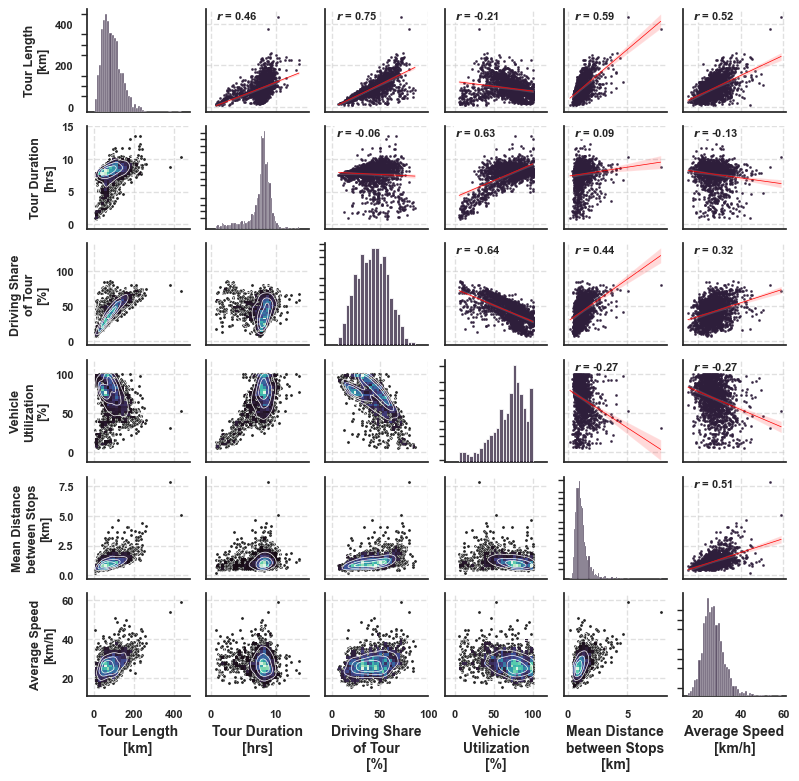

In [766]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from scipy import stats

# Set theme
# sns.set_theme(palette='mako', rc={'figure.figsize':(7.8, 7.8)})
# sns.set()
mpl.rc('font', weight='bold')

# Adjust the size of ticks
mpl.rc('xtick', labelsize=8)
mpl.rc('ytick', labelsize=8)

# Define the data
data = bc[['Tour Length (km)', 'Tour Duration (hrs)', 'Driving Share of Tour (%)',
                  'Vehicle Utilization (%)', 'Mean Distance Between Stops (km)', 
                  'Average Speed (km/h)']]

# Rename the columns for better readability
data.columns = ['Tour Length\n[km]', 
                'Tour Duration\n[hrs]', 
                'Driving Share\nof Tour\n[%]',
                'Vehicle\nUtilization\n[%]', 
                'Mean Distance\nbetween Stops\n[km]', 
                'Average Speed\n[km/h]']

data['Vehicle\nUtilization\n[%]'] *= 100
# data['Driving Share\nof Tour\n(%)'] *= 100

# Create a PairGrid
g = sns.PairGrid(data, height=1.66, aspect=1.41, diag_sharey=False)

# 1) Diagonale: Histogramm, Balken rasterisieren
def diag_hist(x, **kwargs):
    ax = plt.gca()
    # Farbe nur setzen, wenn sie nicht schon in kwargs steckt
    if "color" not in kwargs:
        kwargs["color"] = ".3"
    sns.histplot(x=x, kde=False, **kwargs)
    for p in ax.patches:
        p.set_rasterized(True)
    ax.minorticks_on()
    ax.grid(True, linestyle="--", alpha=0.6)

# Map a histogram to the diagonal
g.map_diag(diag_hist)

# For the upper side, use regplot to create a scatterplot with a regression line
def regplot(x, y, **kwargs):
    sns.regplot(x=x, y=y, ci=95,scatter_kws={'s':1, 'rasterized': True}, line_kws={'color': 'red', 'linewidth': 0.5}, **kwargs)
    
    r, _ = stats.pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f'$r$ = {r:.2f}', xy=(.1, .9), xycoords=ax.transAxes, 
            bbox=dict(boxstyle="round,pad=0.1", ec="white", fc="white", lw=0.01), fontsize=8)

    ax.minorticks_on()
    ax.grid(True, linestyle='--', alpha=0.6)

g.map_upper(regplot)

# For the lower side
def plot_lower(x, y, **kwargs):
    sns.scatterplot(x=x, y=y, s=5, color=".15", rasterized=True)
    sns.histplot(x=x, y=y, bins=30, pthresh=.1, cmap="mako")
    sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=0.5)
    ax = plt.gca()
    ax.minorticks_on()
    ax.grid(True, linestyle='--', alpha=0.6)

g.map_lower(plot_lower)

# Adjust the font size of the labels
for i in range(len(data.columns)):
    for j in range(len(data.columns)):
        xlabel = g.axes[i][j].get_xlabel()
        ylabel = g.axes[i][j].get_ylabel()
        
        if xlabel in data.columns:
            # g.axes[i][j].set_xlabel(xlabel, fontsize=10, fontweight='bold')
            g.axes[i][j].set_xlabel(xlabel, fontsize=10, fontweight='bold')
        if ylabel in data.columns:
            # g.axes[i][j].set_ylabel(ylabel, fontsize=9, fontweight='bold')
            g.axes[i][j].set_ylabel(ylabel, fontsize=9, fontweight='bold')

# Remove y ticks from the histograms on the diagonal
for ax in g.diag_axes:
    ax.yaxis.set_ticks([])
    
for ax in g.axes.flatten():
    # Heatmaps und Bilder
    for im in ax.images:
        im.set_rasterized(True)
    # Collections wie QuadMesh oder große Scatter
    for coll in ax.collections:
        try:
            coll.set_rasterized(True)
        except Exception:
            pass

# Adjust figure size
g.fig.set_size_inches(7.8, 7.8)
# g.fig.set_size_inches(17, 9)

# Save the figure
# g.savefig("multivariate_visualization_neu_4.png", dpi=300, bbox_inches='tight')
g.savefig("multivariate_visualization_neu_4.svg", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [ ]:
sns.set()
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

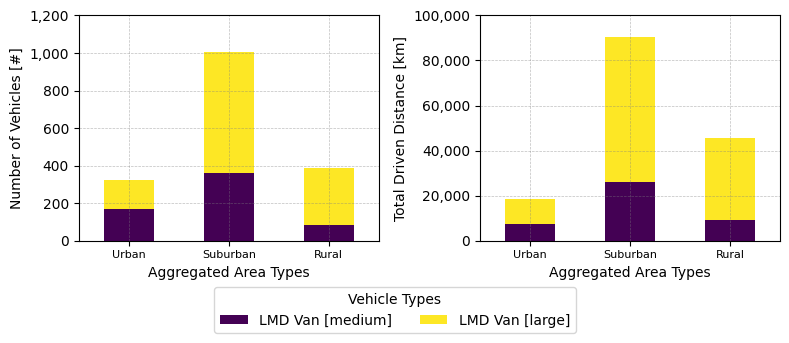

In [753]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as mticker

# Group by 'main_area_type' and aggregate data
aggregated_df = bc.groupby(['area_type_agg', "veh_size"]).agg({
    'vehicle_id': 'count',
    'Tour Length (km)': 'sum'
})

# Calculate total 'Tour Length (km)' per scenario
total_tour_length = bc.groupby('area_type_agg')['Tour Length (km)'].sum().rename('Total Tour Length (km)')

# Merge the total back into the aggregated DataFrame
aggregated_df = aggregated_df.join(total_tour_length, on='area_type_agg')

# Round the values to 2 decimal places
aggregated_df = aggregated_df.round(2)

# # Rename the scenarios for clarity
# scenario_rename = {'bc': 'Baseline', 'rural': 'RCLMD', 'full': 'FCLMD'}
# aggregated_df['scenario'] = aggregated_df['scenario'].map(scenario_rename)

# Assuming aggregated_df is your DataFrame
# Ensure the index is reset for easier plotting
aggregated_df = aggregated_df.reset_index()



# Order the scenarios as per your requirement
scenario_order = ['Urban', 'Suburban', 'Rural']
aggregated_df = aggregated_df[aggregated_df['area_type_agg'].isin(scenario_order)]
aggregated_df['area_type_agg'] = pd.Categorical(aggregated_df['area_type_agg'], categories=scenario_order, ordered=True)
aggregated_df.sort_values('area_type_agg', inplace=True)



# Creating subplots
fig, axs = plt.subplots(1, 2, figsize=(8,3))

# Plot for the number of vehicles
vehicle_count_plot = aggregated_df.pivot(index='area_type_agg', columns='veh_size', values='vehicle_id')
vehicle_count_plot.plot(kind='bar', stacked=True, ax=axs[0], cmap = "viridis")
axs[0].set_ylabel('Number of Vehicles [#]', fontsize=10)
axs[0].set_xlabel('Aggregated Area Types', fontsize=10)
axs[0].set_xticklabels(vehicle_count_plot.index, rotation=0, fontsize=10)
axs[0].set_ylim(0 , 1200)

axs[0].set_xticklabels(['Urban', 'Suburban', 'Rural'], rotation=0, fontsize=8)
axs[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Plot for the total driven distance
tour_length_plot = aggregated_df.pivot(index='area_type_agg', columns='veh_size', values='Tour Length (km)')
tour_length_plot.plot(kind='bar', stacked=True, ax=axs[1] , cmap = "viridis")
axs[1].set_ylabel('Total Driven Distance [km]', fontsize=10)
axs[1].set_xlabel('Aggregated Area Types', fontsize=10)
axs[1].set_xticklabels(vehicle_count_plot.index, rotation=0, fontsize=10)
axs[1].set_ylim(0 , 100000)
axs[1].set_xticklabels(['Urban', 'Suburban', 'Rural'], rotation=0, fontsize=8)
axs[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))


# # Unified legend below the plots
handles, labels = axs[0].get_legend_handles_labels()

# labels = ["Van [<2t]", "Van [>2t]", "Semi [10-20t]", "Truck [<10t]"]

# Modified labels list to switch 'Semi' and 'Truck'
labels = ["LMD Van [medium]", "LMD Van [large]"]


fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), title="Vehicle Types", fontsize=10, ncol=len(labels))


# Remove individual legends
axs[0].get_legend().remove()
axs[1].get_legend().remove()

plt.tight_layout()

# Reduce the visibility of the grid
axs[0].grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5, zorder = 100)
axs[1].grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5, zorder = 100)

# plt.savefig('veh_distance_comparison.png', dpi=fig.dpi)
plt.savefig("veh_distance_comparison.pdf", format='pdf', dpi=300 , bbox_inches='tight')
plt.show()


In [23]:

# Angenommen, 'vans' ist Ihr DataFrame

# Summen und Mittelwerte nach 'area_type_3' berechnen
grouped = bc.groupby('area_type_agg').agg({
    'service_num': ['sum', 'mean'],
    'Tour Length (km)': ['sum', 'mean'],
    'deliveries': ['sum', 'mean'],
    'Vehicle Utilization (%)': ['mean'],  # Sum makes no sense for percentages
    'deliveries_per_stop': ['mean'],  # Sum makes no sense for factors
    'Tour Duration (hrs)': ['sum', 'mean'],
    'Driving Time (hrs)': ['sum', 'mean'],
    'Average Speed (km/h)': ['mean'],  # Sum makes no sense for speed

})

# Ergebnis anzeigen
grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
grouped.reset_index(inplace=True)
grouped

,area_type_agg,service_num_sum,service_num_mean,Tour Length (km)_sum,Tour Length (km)_mean,deliveries_sum,deliveries_mean,Vehicle Utilization (%)_mean,deliveries_per_stop_mean,Tour Duration (hrs)_sum,Tour Duration (hrs)_mean,Driving Time (hrs)_sum,Driving Time (hrs)_mean,Average Speed (km/h)_mean
0,Rural,22962,59.641558,45758.690759,118.853742,41698.0,108.306494,0.610456,1.957952,2944.964444,7.649258,1505.972500,3.911617,30.212703
1,Suburban,54882,54.500497,90634.330039,90.004300,131989.0,131.071500,0.697785,2.978874,7748.242222,7.694382,3269.480278,3.246753,27.612295
2,Urban,14989,46.405573,18514.743063,57.321186,50031.0,154.894737,0.774064,4.488082,2476.333056,7.666666,783.295556,2.425064,23.683903


In [24]:
import pandas as pd

# IQR-Funktion definieren
def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

# Aggregationen festlegen
agg_funcs = {
    'service_num': ['sum', 'mean', 'std', iqr, 'min', 'median', 'max'],
    'Tour Length (km)': ['sum', 'mean', 'std', iqr, 'min', 'median', 'max'],
    'deliveries': ['sum', 'mean', 'std', iqr, 'min', 'median', 'max'],
    'Vehicle Utilization (%)': ['mean', 'std', iqr, 'min', 'median', 'max'],
    'deliveries_per_stop': ['mean', 'std', iqr, 'min', 'median', 'max'],
    'Tour Duration (hrs)': ['sum', 'mean', 'std', iqr, 'min', 'median', 'max'],
    'Driving Time (hrs)': ['sum', 'mean', 'std', iqr, 'min', 'median', 'max'],
    'Average Speed (km/h)': ['mean', 'std', iqr, 'min', 'median', 'max']
}

# Gruppierung durchführen
grouped = bc.groupby('area_type_agg').agg(agg_funcs)

# Spaltennamen flatten
grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
grouped.reset_index(inplace=True)

# Ergebnis anzeigen
grouped


,area_type_agg,service_num_sum,service_num_mean,service_num_std,service_num_iqr,service_num_min,service_num_median,service_num_max,Tour Length (km)_sum,Tour Length (km)_mean,...,Driving Time (hrs)_iqr,Driving Time (hrs)_min,Driving Time (hrs)_median,Driving Time (hrs)_max,Average Speed (km/h)_mean,Average Speed (km/h)_std,Average Speed (km/h)_iqr,Average Speed (km/h)_min,Average Speed (km/h)_median,Average Speed (km/h)_max
0,Rural,22962,59.641558,20.328586,23.0,2,61.0,126,45758.690759,118.853742,...,2.208056,0.443889,3.840278,8.038889,30.212703,4.865595,6.173207,17.985001,29.884720,58.983165
1,Suburban,54882,54.500497,22.338881,33.0,4,54.0,124,90634.330039,90.004300,...,2.122639,0.151944,3.083056,9.113611,27.612295,4.824627,5.597134,15.495215,27.044492,53.756222
2,Urban,14989,46.405573,22.058214,32.0,4,44.0,110,18514.743063,57.321186,...,1.715694,0.231111,2.290000,5.890278,23.683903,3.205173,4.261587,15.389056,23.791073,35.084917


In [ ]:
# sns.set_theme(style='white', palette='mako', rc={'figure.figsize':(7.8, 7.8)})


# mpl.rc('font', weight='bold')

# # Adjust the size of ticks
# mpl.rc('xtick', labelsize=8)
# mpl.rc('ytick', labelsize=8)

sns.set()
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

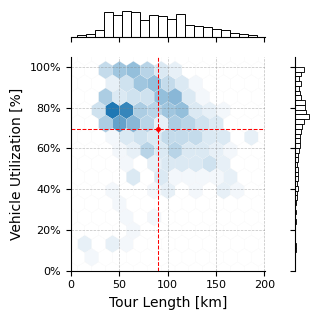

In [754]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]

def get_color_gradient(hex_color, n_shades):
    color_rgb = np.array(hex_to_rgb(hex_color))
    gradient = [color_rgb + (255 - color_rgb) * i / (n_shades - 1) for i in range(n_shades)]
    gradient = np.clip(gradient, 0, 255).astype(int)
    return gradient

colors = {
    'Urban': '#808080',
    'Suburban': '#1f78b4',
    'Rural': '#33a02c',
    'Total': '#fde725'  # Gelb aus der Viridis-Farbkarte
}

n_shades = 20
gradients = {name: get_color_gradient(color, n_shades)[::-1] for name, color in colors.items()}

gradients_rgb = {name: [(r/255, g/255, b/255) for r, g, b in gradient] for name, gradient in gradients.items()}

def create_transparent_cmap(hex_color, n_shades):
    color_rgb = np.array(hex_to_rgb(hex_color)) / 255.0
    alpha = np.linspace(0, 1, n_shades)
    cmap_colors = np.column_stack([np.tile(color_rgb, (n_shades, 1)), alpha])
    return LinearSegmentedColormap.from_list(f'{hex_color}_cmap', cmap_colors)

urban_cmap = create_transparent_cmap(colors['Urban'], n_shades)
suburban_cmap = create_transparent_cmap(colors['Suburban'], n_shades)
rural_cmap = create_transparent_cmap(colors['Rural'], n_shades)
viridis_yellow_cmap = create_transparent_cmap(colors['Total'], n_shades)

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Convert RGB tuples to matplotlib color format
suburban_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in gradients['Suburban']]
suburban_cmap = LinearSegmentedColormap.from_list('suburban_cmap', suburban_gradient, N=n_shades)


vans_rural = bc[bc.area_type_agg =="Suburban"]

# Ensure that the x and y axes are the same for both datasets
x_min, x_max = 0, 201
y_min, y_max = 0, 1.05  # The y-axis range as a fraction

# Calculate the mean values
mean_x = vans_rural['Tour Length (km)'].mean()
mean_y = vans_rural['Vehicle Utilization (%)'].mean()

# Function to format the y-axis labels as percentages without decimals
def to_percent(y, position):
    return f"{int(100 * y)}%"

# Create the percentage formatter
percent_formatter = FuncFormatter(to_percent)

# Set common axis limits
x_lim = (0, x_max)
y_lim = (0, y_max)

# Set a common gridsize
gridsize = 14  # Choose a gridsize that suits your data density

# Plot for the first dataset
g1 = sns.jointplot(
    data=vans_rural[vans_rural["Tour Length (km)"] < 500], 
    x='Tour Length (km)', 
    y='Vehicle Utilization (%)',
    kind='hex', 
    cmap=suburban_cmap, 
    marginal_kws=dict(bins=40, fill=True, color = "white"),
    gridsize=gridsize,
    joint_kws={'extent': x_lim + y_lim, 'edgecolors': 'whitesmoke', 'linewidths': 0.1}
)
g1.fig.set_size_inches(3.3, 3.3)
g1.ax_joint.set_xticks([0, 50, 100, 150, 200, 250])
g1.ax_joint.set_xlim([x_min, x_max])
g1.ax_joint.set_ylim([y_min, y_max])



# Draw dashed lines from the axes to the mean point
g1.ax_joint.axhline(mean_y, ls='--', lw=0.75, color='red')
g1.ax_joint.axvline(mean_x, ls='--', lw=0.75, color='red')

# Highlight the hexagon with the mean x and y values
g1.ax_joint.plot(mean_x, mean_y, '.', markersize=5, color = "red")

# Apply the percentage formatter to the y-axis
g1.ax_joint.yaxis.set_major_formatter(percent_formatter)

# Adjust the tick label size
g1.ax_joint.tick_params(axis='both', which='major', labelsize=8)
# Set the axis label sizes
g1.set_axis_labels('Tour Length [km]', 'Vehicle Utilization [%]', fontsize=10)

# Reduce the visibility of the grid
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.tight_layout()

plt.savefig("suburban-hex.pdf", format='pdf', dpi=300 , bbox_inches='tight')

plt.show()





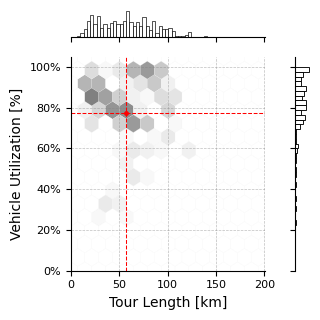

In [755]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Convert RGB tuples to matplotlib color format
suburban_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in gradients['Urban']]
suburban_cmap = LinearSegmentedColormap.from_list('suburban_cmap', suburban_gradient, N=n_shades)

vans_rural = bc[bc.area_type_agg =="Urban"]

# Ensure that the x and y axes are the same for both datasets
x_min, x_max = 0, 201
y_min, y_max = 0, 1.05  # The y-axis range as a fraction

# Calculate the mean values
mean_x = vans_rural['Tour Length (km)'].mean()
mean_y = vans_rural['Vehicle Utilization (%)'].mean()

# Function to format the y-axis labels as percentages without decimals
def to_percent(y, position):
    return f"{int(100 * y)}%"

# Create the percentage formatter
percent_formatter = FuncFormatter(to_percent)

# Set common axis limits
x_lim = (0, x_max)
y_lim = (0, y_max)

# Set a common gridsize
gridsize = 14  # Choose a gridsize that suits your data density

# Plot for the first dataset
g1 = sns.jointplot(
    data=vans_rural[vans_rural["Tour Length (km)"] < 500], 
    x='Tour Length (km)', 
    y='Vehicle Utilization (%)',
    kind='hex', 
    cmap=suburban_cmap, 
    marginal_kws=dict(bins=40, fill=True, color = "white"),
    gridsize=gridsize,
    joint_kws={'extent': x_lim + y_lim, 'edgecolors': 'whitesmoke', 'linewidths': 0.1}
)
g1.fig.set_size_inches(3.3, 3.3)
g1.ax_joint.set_xticks([0, 50, 100, 150, 200, 250])
g1.ax_joint.set_xlim([x_min, x_max])
g1.ax_joint.set_ylim([y_min, y_max])



# Draw dashed lines from the axes to the mean point
g1.ax_joint.axhline(mean_y, ls='--', lw=0.75, color='red')
g1.ax_joint.axvline(mean_x, ls='--', lw=0.75, color='red')

# Highlight the hexagon with the mean x and y values
g1.ax_joint.plot(mean_x, mean_y, '.', markersize=5, color = "red")

# Apply the percentage formatter to the y-axis
g1.ax_joint.yaxis.set_major_formatter(percent_formatter)

# Adjust the tick label size
g1.ax_joint.tick_params(axis='both', which='major', labelsize=8)
# Set the axis label sizes
g1.set_axis_labels('Tour Length [km]', 'Vehicle Utilization [%]', fontsize=10)

# Reduce the visibility of the grid
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.tight_layout()

plt.savefig("urban-hex.pdf", format='pdf', dpi=300 , bbox_inches='tight')

plt.show()




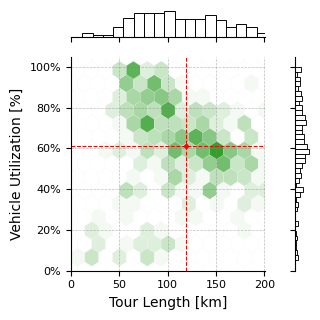

In [756]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Convert RGB tuples to matplotlib color format
suburban_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in gradients['Rural']]
suburban_cmap = LinearSegmentedColormap.from_list('suburban_cmap', suburban_gradient, N=n_shades)

vans_rural = bc[bc.area_type_agg =="Rural"]

# Ensure that the x and y axes are the same for both datasets
x_min, x_max = 0, 201
y_min, y_max = 0, 1.05  # The y-axis range as a fraction

# Calculate the mean values
mean_x = vans_rural['Tour Length (km)'].mean()
mean_y = vans_rural['Vehicle Utilization (%)'].mean()

# Function to format the y-axis labels as percentages without decimals
def to_percent(y, position):
    return f"{int(100 * y)}%"

# Create the percentage formatter
percent_formatter = FuncFormatter(to_percent)

# Set common axis limits
x_lim = (0, x_max)
y_lim = (0, y_max)

# Set a common gridsize
gridsize = 14  # Choose a gridsize that suits your data density

# Plot for the first dataset
g1 = sns.jointplot(
    data=vans_rural[vans_rural["Tour Length (km)"] < 500], 
    x='Tour Length (km)', 
    y='Vehicle Utilization (%)',
    kind='hex', 
    cmap=suburban_cmap, 
    marginal_kws=dict(bins=40, fill=True, color = "white"),
    gridsize=gridsize,
    joint_kws={'extent': x_lim + y_lim, 'edgecolors': 'whitesmoke', 'linewidths': 0.1}
)
g1.fig.set_size_inches(3.3, 3.3)
g1.ax_joint.set_xticks([0, 50, 100, 150, 200, 250])
g1.ax_joint.set_xlim([x_min, x_max])
g1.ax_joint.set_ylim([y_min, y_max])



# Draw dashed lines from the axes to the mean point
g1.ax_joint.axhline(mean_y, ls='--', lw=0.75, color='red')
g1.ax_joint.axvline(mean_x, ls='--', lw=0.75, color='red')

# Highlight the hexagon with the mean x and y values
g1.ax_joint.plot(mean_x, mean_y, '.', markersize=5, color = "red")

# Apply the percentage formatter to the y-axis
g1.ax_joint.yaxis.set_major_formatter(percent_formatter)

# Adjust the tick label size
g1.ax_joint.tick_params(axis='both', which='major', labelsize=8)
# Set the axis label sizes
g1.set_axis_labels('Tour Length [km]', 'Vehicle Utilization [%]', fontsize=10)

# Reduce the visibility of the grid
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.tight_layout()

plt.savefig("rural-hex.pdf", format='pdf', dpi=300 , bbox_inches='tight')

plt.show()




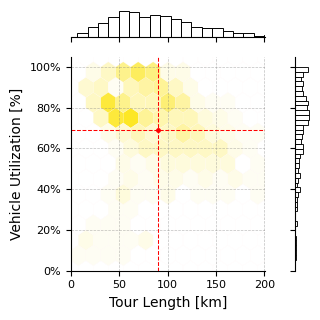

In [757]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Convert RGB tuples to matplotlib color format
suburban_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in gradients['Total']]
suburban_cmap = LinearSegmentedColormap.from_list('suburban_cmap', suburban_gradient, N=n_shades)


vans_rural = bc

# Ensure that the x and y axes are the same for both datasets
x_min, x_max = 0, 201
y_min, y_max = 0, 1.05  # The y-axis range as a fraction

# Calculate the mean values
mean_x = vans_rural['Tour Length (km)'].mean()
mean_y = vans_rural['Vehicle Utilization (%)'].mean()

# Function to format the y-axis labels as percentages without decimals
def to_percent(y, position):
    return f"{int(100 * y)}%"

# Create the percentage formatter
percent_formatter = FuncFormatter(to_percent)

# Set common axis limits
x_lim = (0, x_max)
y_lim = (0, y_max)

# Set a common gridsize
gridsize = 13  # Choose a gridsize that suits your data density

# Plot for the first dataset
g1 = sns.jointplot(
    data=vans_rural[vans_rural["Tour Length (km)"] < 500], 
    x='Tour Length (km)', 
    y='Vehicle Utilization (%)',
    kind='hex', 
    cmap=suburban_cmap, 
    marginal_kws=dict(bins=40, fill=True, color = "white"),
    gridsize=gridsize,
    joint_kws={'extent': x_lim + y_lim, 'edgecolors': 'snow', 'linewidths': 0.1}
)
g1.fig.set_size_inches(3.3, 3.3)
g1.ax_joint.set_xticks([0, 50, 100, 150, 200, 250])
g1.ax_joint.set_xlim([x_min, x_max])
g1.ax_joint.set_ylim([y_min, y_max])



# Draw dashed lines from the axes to the mean point
g1.ax_joint.axhline(mean_y, ls='--', lw=0.75, color='red')
g1.ax_joint.axvline(mean_x, ls='--', lw=0.75, color='red')

# Highlight the hexagon with the mean x and y values
g1.ax_joint.plot(mean_x, mean_y, '.', markersize=5, color = "red")

# Apply the percentage formatter to the y-axis
g1.ax_joint.yaxis.set_major_formatter(percent_formatter)

# Adjust the tick label size
g1.ax_joint.tick_params(axis='both', which='major', labelsize=8)
# Set the axis label sizes
g1.set_axis_labels('Tour Length [km]', 'Vehicle Utilization [%]', fontsize=10)

# Reduce the visibility of the grid
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.tight_layout()

plt.savefig("total-hex.pdf", format='pdf', dpi=300 , bbox_inches='tight')

plt.show()




In [ ]:
bc

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\2432286232.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bc_selected["Vehicle Utilization (%)"] = bc_selected["Vehicle Utilization (%)"] * 100
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\2432286232.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)  # Hide individual legends on each subplot
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\2432286232.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with 

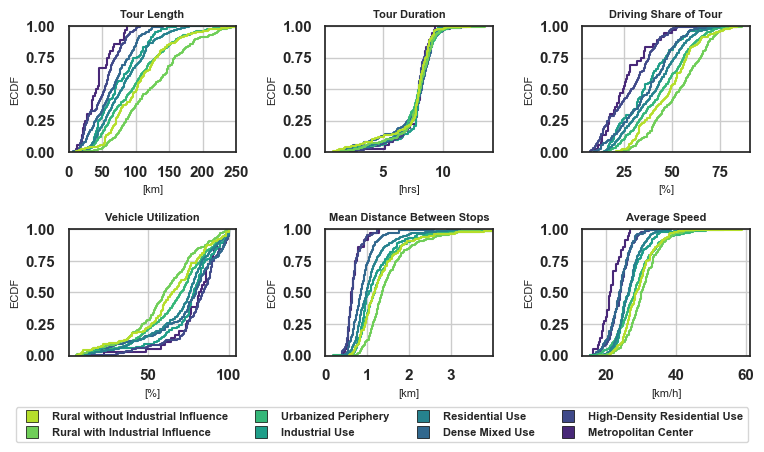

In [758]:
# Map the numbers to the area descriptions
bc['main_area_type_desc'] = bc['main_area_type'].astype(str).map(category_dict)

# Select only the necessary columns
bc_selected = bc[['Tour Length (km)', 'Tour Duration (hrs)', 'Driving Share of Tour (%)',
                  'Vehicle Utilization (%)', 'Mean Distance Between Stops (km)', 
                  'Average Speed (km/h)','main_area_type_desc']]

bc_selected["Vehicle Utilization (%)"] = bc_selected["Vehicle Utilization (%)"] * 100

sns.set_theme(style='white', palette='mako', rc={'figure.figsize':(7.8, 7.8)})

mpl.rc('font', weight='bold')

# Create a 3x2 subplot layout
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7.8, 4.25))
# fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(19, 9))

# Define the titles for the plots
plot_titles = ['Tour Length', 'Tour Duration', 
               'Driving Share of Tour', 'Vehicle Utilization', 
               'Mean Distance Between Stops', 'Average Speed']

# Define the DataFrame and x-axis column names for each subplot
x_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)', 
               'Driving Share of Tour (%)', 'Vehicle Utilization (%)', 
               'Mean Distance Between Stops (km)', 'Average Speed (km/h)']


# Define the x-axis labels
x_axis_labels = ['[km]', '[hrs]', 
                 '[%]', '[%]', 
                 '[km]', '[km/h]']

# Define the hue column name for the ECDF plot
hue_col_name = 'main_area_type_desc'

# Loop through each subplot and plot the corresponding ECDF
for i, ax in enumerate(axes.flat):
    sns.ecdfplot(data=bc_selected, x=x_axes_cols[i], ax=ax , hue=hue_col_name, palette=category_color_dict)
    ax.set_title(plot_titles[i], fontsize= 8, weight = 'bold') # 8 before ll
    ax.set_xlabel(x_axis_labels[i], fontsize= 8)  # Adding x-axis label
    ax.set_ylabel('ECDF', fontsize= 8)
    ax.grid(True) 
    ax.legend().set_visible(False)  # Hide individual legends on each subplot
    
    # Set x-axis ticks for specific plots
    if plot_titles[i] == 'Tour Length':
        ax.set_xticks(range(0, 251, 50))
        ax.set_xlim(0, 250)
    elif plot_titles[i] == 'Driving Time':
        ax.set_xticks(range(0, 8, 1))   
    elif plot_titles[i] == 'Mean Distance Between Stops': 
        ax.set_xticks(range(0, 4, 1))   
        ax.set_xlim(0, 4)

# # Create a custom legend outside the subplots
custom_legend_labels = list(category_color_dict.keys())[::-1] # Replace with actual legend labels
# fig.legend(custom_legend_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.035), fontsize= 8)

# Create a custom legend outside the subplots
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=v, markeredgewidth=0.5, markeredgecolor='black', markersize=8) for v in reversed(palette_dict.values())]
fig.legend(handles, custom_legend_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.035), fontsize= 8)

# Adjust the layout for better spacing
plt.tight_layout(rect=[0, 0.001, 1, 0.9999])  # Include space for the custom legend at the bottom

# Save the figure
plt.savefig("diff_distribution_visualization_new.pdf", dpi=300, bbox_inches='tight')
# plt.savefig("diff_distribution_visualization.png", dpi=300, bbox_inches='tight')
# Show the plots
plt.show()

In [759]:
sns.set_theme(style='white', palette='mako', rc={'figure.figsize':(7.8, 7.8)})


mpl.rc('font', weight='bold')

# Adjust the size of ticks
mpl.rc('xtick', labelsize=8)
mpl.rc('ytick', labelsize=8)

# sns.set()
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\4144431557.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\4144431557.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\4144431557.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\4144431557.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an 

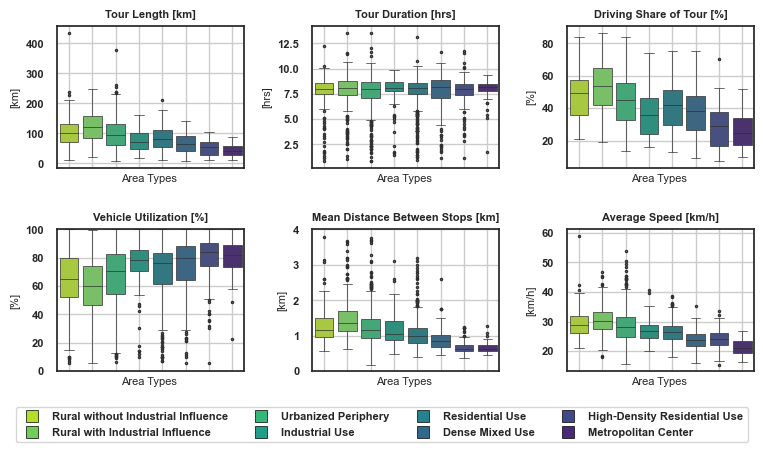

In [760]:
# Boxplot grid with fixed y-limits for Mean Distance (<=4 km) and Utilization (<=100%)
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure utilization column is in percent (scale if looks fractional)
if 'Vehicle Utilization (%)' in bc_selected.columns:
    s = pd.to_numeric(bc_selected['Vehicle Utilization (%)'], errors='coerce')
    if s.notna().any() and s.max() <= 1.5:
        bc_selected = bc_selected.copy()
        bc_selected['Vehicle Utilization (%)'] = s * 100.0

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7.8, 4.25))
order = list(reversed(palette_dict.keys()))
plot_titles = ['Tour Length [km]', 'Tour Duration [hrs]', 
               'Driving Share of Tour [%]', 'Vehicle Utilization [%]', 
               'Mean Distance Between Stops [km]', 'Average Speed [km/h]']

y_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)', 
               'Driving Share of Tour (%)', 'Vehicle Utilization (%)', 
               'Mean Distance Between Stops (km)', 'Average Speed (km/h)']

y_axis_labels = ['[km]', '[hrs]', 
                 '[%]', '[%]', 
                 '[km]', '[km/h]']


x_axis_col = 'main_area_type_desc'

for i, ax in enumerate(axes.flat):
    sns.boxplot(
        data=bc_selected, y=y_axes_cols[i], x=x_axis_col, ax=ax,
        palette=palette_dict, order=order, linewidth=0.5,
        flierprops={"marker": ".", "markersize": 3}
    )
    ax.set_title(plot_titles[i], fontsize=8, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(y_axis_labels[i], fontsize=8)
    ax.tick_params(axis='x', labelbottom=False)
    ax.grid(True)
    ax.legend().set_visible(False)
    ax.set_xlabel("Area Types \n", fontsize=8)

    # Apply requested y-limits
    if y_axes_cols[i] == 'Mean Distance Between Stops (km)':
        ax.set_ylim(0, 4)
    elif y_axes_cols[i] == 'Vehicle Utilization (%)':
        ax.set_ylim(0, 100)

handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=v,
               markeredgewidth=0.5, markeredgecolor='black', markersize=8)
    for v in reversed(palette_dict.values())
]
fig.legend(handles, custom_legend_labels, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 0.035), fontsize=8)

plt.tight_layout(rect=[0, 0.001, 1, 0.9999])
plt.savefig("box_distribution_visualization.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import ast
from scipy.spatial.distance import cdist


if isinstance(bc['service_dists'].iloc[0], str):
    bc['service_dists'] = bc['service_dists'].apply(ast.literal_eval)

# Schritt 1: Distanzen zwischen Stopps je Tour berechnen
def get_stop_segments(row):
    d = sorted(row['service_dists'].values())
    return [d[i+1] - d[i] for i in range(len(d)-1)] if len(d) > 1 else []

bc['stop_segments'] = bc.apply(get_stop_segments, axis=1)

# Schritt 2: L2-Medoid finden (Padding mit 0)
def find_l2_medoid(tour_segments):
    max_len = max(len(t) for t in tour_segments)
    padded = np.array([t + [0]*(max_len - len(t)) for t in tour_segments])
    dists = cdist(padded, padded, metric='euclidean')
    total_dist = np.sum(dists, axis=1)
    return tour_segments[np.argmin(total_dist)]

# Schritt 3: Repräsentative Tour pro Raumtyp bestimmen
area_representatives = {}
for area in bc['main_area_description'].unique():
    group = bc[bc['main_area_description'] == area]
    segments = [
        s for s in group['stop_segments']
        if isinstance(s, list) and len(s) >= 1 and all(isinstance(x, (int, float)) for x in s)
    ]
    if len(segments) < 2:
        print(f"⚠️ Überspringe '{area}' (nicht genug gültige Touren)")
        continue
    rep = find_l2_medoid(segments)
    area_representatives[area] = rep

def plot_representative_tours_with_stats(area_representatives, bc):
    sort_order = [
        "Rural without Industrial Influence",
        "Rural with Industrial Influence",
        "Urbanized Periphery",
        "Industrial Use",
        "Residential Use",
        "Dense Mixed Use",
        "High-Density Residential Use",
        "Metropolitan Center"
    ]

    reps_sorted = []
    y_labels = []
    tour_lengths = []
    avg_load_factors = []

    for k in sort_order:
        if k in area_representatives:
            rep = area_representatives[k]
            reps_sorted.append(rep)
            y_labels.append(k)
            tour_lengths.append(np.round(np.sum(rep), 1))  # km

            # Durchschnittliche Auslastung aus bc
            avg_load = bc[bc["main_area_description"] == k]["Vehicle Utilization (%)"].mean()
            avg_load_factors.append(np.round(avg_load * 100, 1))  # Prozent

    max_len = max(len(r) for r in reps_sorted)
    padded = np.array([r + [np.nan]*(max_len - len(r)) for r in reps_sorted])

    fig, ax = plt.subplots(figsize=(8, 3))
    cmap = cm.get_cmap('viridis')
    norm = mcolors.Normalize(vmin=np.nanmin(padded), vmax=np.nanmax(padded))
    cax = ax.imshow(padded, aspect='auto', cmap=cmap, norm=norm)

    # ax.set_xlim(-5,50)

    ax.set_yticks(np.arange(len(reps_sorted)))
    ax.set_yticklabels(y_labels, fontsize=10)
    ax.set_xlabel('Tour Stop Segment Index')
    ax.set_title('(a) Representative Tours')
    ax.set_xlim(0, 120)
    # # Zusatzinfos rechts daneben schreiben
    # for i, (length, load) in enumerate(zip(tour_lengths, avg_load_factors)):
    #     label = f"{load:.1f}%"
    #     ax.text(padded.shape[1] + 1, i, label, va='center', fontsize=8, color='black')

    # Farbe + Layout
    plt.colorbar(cax, label='Distance between stops [km]', ax=ax)
    plt.tight_layout()
    fig.savefig("representative_tours.pdf", dpi=300, bbox_inches='tight', format='pdf')
    plt.show()


plot_representative_tours_with_stats(area_representatives, bc)


In [ ]:
sort_order = [
    "Rural without Industrial Influence",
    "Rural with Industrial Influence",
    "Urbanized Periphery",
    "Industrial Use",
    "Residential Use",
    "Dense Mixed Use",
    "High-Density Residential Use",
    "Metropolitan Center"
]

std_matrix = []
valid_labels = []

# Finde globale max-Länge über alle Raumtypen
global_max_len = 0
for k in sort_order:
    group = bc[bc["main_area_description"] == k]
    segments = [s for s in group['stop_segments'] if isinstance(s, list) and len(s) >= 1]
    if len(segments) >= 2:
        local_max = max(len(t) for t in segments)
        global_max_len = max(global_max_len, local_max)

# Berechne gepaddete STD-Vektoren
for k in sort_order:
    group = bc[bc["main_area_description"] == k]
    segments = [s for s in group['stop_segments'] if isinstance(s, list) and len(s) >= 1]
    if len(segments) < 2:
        continue
    padded = np.array([t + [np.nan]*(global_max_len - len(t)) for t in segments])
    std = np.nanstd(padded, axis=0)
    std_matrix.append(std)
    valid_labels.append(k)

# In Heatmap umwandeln
std_padded = np.vstack(std_matrix)

fig, ax = plt.subplots(figsize=(8, 3))
cmap = cm.get_cmap('magma')
norm = mcolors.Normalize(vmin=0, vmax=np.nanmax(std_padded))
cax = ax.imshow(std_padded, aspect='auto', cmap=cmap, norm=norm)

ax.set_yticks(np.arange(len(valid_labels)))
ax.set_yticklabels(valid_labels, fontsize=10)
ax.set_xlabel('Tour Stop Segment Index')
ax.set_title("(b) Intra-class Variability of Stop-to-Stop Distances")
plt.colorbar(cax, label='Standard deviation [km]', ax=ax)
plt.tight_layout()
fig.savefig("tour_segment_variability.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.show()



In [820]:
bc['Service Duration'] = bc['Service Duration'] / 3600

In [821]:
import pandas as pd

# Strukturierter KPI-Block mit Beschreibung + Einheit
kpi_structure = {
    "Temporal Metrics": {
        "Tour Duration (hrs)": "Tour Duration [hrs]",
        "Driving Time (hrs)": "Driving Time [hrs]",
        "Service Duration": "Total Delivery Duration [hrs]"
    },
    "Tour Structure": {
        "Tour Length (km)": "Tour Length [km]",
        "Initial Delivery Distance (km)": "Initial Delivery Distance [km]",
        "service_num": "Number of Stops [#]",
        "Mean Distance Between Stops (km)": "Mean Distance Between Stops [km]",
        "max_dist_wo_init": "Maximum Segment Distance [km]",
        "delivery_area_km2": "Delivery Area [km²]",
        "Driving Share of Tour (%)": "Driving Share [%]",
        "Average Speed (km/h)": "Average Speed [km/h]",
        # wird später als Sonderfall über len() je Gruppe hinzugefügt
    },
    "Delivery Metrics": {
        "deliveries": "Deliveries [#]",        
        "deliveries_per_stop": "Deliveries per Stop [#]",
        "missed deliveries": "Missed Deliveries [#]",
        "vehicle_deliver_factor": "Vehicle Delivery Ration [%]",       
        "b2b_ration": "B2B Ratio [%]"
    },
    "Load Metrics": {
        "total_weight": "Total Weight [kg]",
        "avg_weight_per_parcel": "Avg. Weight per Parcel [kg]",
        "Vehicle Utilization (%)": "Vehicle Utilization [%]"
    },
    "Cost Metrics": {
        "vehicle_cost": "Total Vehicle Cost [€]",
        "vehicle_fix_cost": "Fixed Vehicle Cost [€]",
        "vehicle_km_cost": "Distance-based Cost [€]",
        "overtime_cost": "Overtime Cost [€]"
    }
}

# Nur numerische Spalten extrahieren, die auch im DataFrame vorhanden sind
kpi_numeric = {
    group: {
        col: label for col, label in metrics.items()
        if col in bc.columns and pd.api.types.is_numeric_dtype(bc[col])
    } for group, metrics in kpi_structure.items()
}
kpi_columns = [col for group in kpi_numeric.values() for col in group]

# Gruppierung + Aggregation
summary_df = bc.groupby("main_area_description")[kpi_columns].agg(["mean", "std", "median", "count"])

# Spaltennamen ersetzen (Ebene 0)
renaming_dict = {
    col: label for group in kpi_numeric.values() for col, label in group.items()
}
summary_df.rename(columns=renaming_dict, level=0, inplace=True)

# Total Vehicles als eigene Spalte in "Tour Structure"
vehicle_counts = bc.groupby("main_area_description").size().rename("Total Vehicles [#]")
summary_df[("Total Vehicles [#]", "count")] = vehicle_counts
summary_df[("Total Vehicles [#]", "mean")] = vehicle_counts  # fix für Kompatibilität
summary_df[("Total Vehicles [#]", "std")] = float("nan")
summary_df[("Total Vehicles [#]", "median")] = vehicle_counts

# Ergebnis: summary_df enthält alle strukturierten, numerischen KPIs + Fahrzeuganzahl
summary_df


Tour Duration [hrs]                      \
                                                  mean       std    median   
main_area_description                                                        
Dense Mixed Use                               7.592530  2.023766  8.222778   
High-Density Residential Use                  7.720010  1.508929  7.963056   
Industrial Use                                7.797908  1.602018  8.117917   
Metropolitan Center                           7.765478  1.417216  8.162778   
Residential Use                               7.700563  1.680727  8.119167   
Rural with Industrial Influence               7.744074  1.756907  8.103611   
Rural without Industrial Influence            7.475662  1.988338  7.996944   
Urbanized Periphery                           7.665898  1.732801  7.965694   

                                         Driving Time [hrs]            \
                                   count               mean       std   
main_area_description                                                   
Dense Mixed Use                      148           2.765480  1.257302   
High-Density Residential Use         139           2.158527  1.033488   
Industrial Use                       102           2.815087  1.204426   
Metropolitan Center                   36           2.054699  1.012768   
Residential Use                      439           3.121279  1.302820   
Rural with Industrial Influence      249           4.092520  1.451294   
Rural without Industrial Influence   136           3.580404  1.437579   
Urbanized Periphery                  466           3.459441  1.455711   

                                                    \
                                      median count   
main_area_description                                
Dense Mixed Use                     2.711250   148   
High-Density Residential Use        2.081944   139   
Industrial Use                      2.704861   102   
Metropolitan Center                 1.848472    36   
Residential Use                     3.026944   439   
Rural with Industrial Influence     4.075000   249   
Rural without Industrial Influence  3.377639   136   
Urbanized Periphery                 3.340833   466   

                                   Total Delivery Duration [hrs]            \
                                                            mean       std   
main_area_description                                                        
Dense Mixed Use                                         0.001341  0.000445   
High-Density Residential Use                            0.001545  0.000378   
Industrial Use                                          0.001384  0.000384   
Metropolitan Center                                     0.001586  0.000355   
Residential Use                                         0.001272  0.000394   
Rural with Industrial Influence                         0.001014  0.000357   
Rural without Industrial Influence                      0.001082  0.000397   
Urbanized Periphery                                     0.001168  0.000372   

                                    ... Distance-based Cost [€]        \
                                    ...                  median count   
main_area_description               ...                                 
Dense Mixed Use                     ...               24.657345   148   
High-Density Residential Use        ...               20.458118   139   
Industrial Use                      ...               26.504448   102   
Metropolitan Center                 ...               16.397142    36   
Residential Use                     ...               30.083565   439   
Rural with Industrial Influence     ...               45.407316   249   
Rural without Industrial Influence  ...               38.249451   136   
Urbanized Periphery                 ...               35.755804   466   

                                   Overtime Cost [€]                        \
                                    

In [830]:
summary_df.to_csv("sum_new.csv")

In [832]:
mean_df = summary_df.xs("mean", axis=1, level=1)

mean_df.to_csv("summary_df_detail_all.csv", index=True)

# # Optional: Runden für bessere Lesbarkeit
# mean_df = mean_df.round(2)

# mean_df.to_csv("summary_df_detail.csv", index=True)



In [835]:
result

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,Driving Share of Tour (%),area_type_agg,main_area_description,Cost per Parcel [€/parcel],b2b_deliveries,b2c_deliveries,Cost per Kilogram [€/kg],inefficiency_perf,inefficiency_cost,inefficiency_total
0,freight_gls_30900_veh_cep_size_m_7_3,24971,69117,12.262778,15206,8.038889,1970-01-01 06:56:11,1970-01-01 19:11:57,1970-01-01 12:15:46,1970-01-01 04:13:26,...,65.555203,Rural,Rural without Industrial Influence,3.020783,8.0,113.0,0.675279,0.566158,0.107762,0.336960
1,freight_gls_30900_veh_cep_size_m_7_2,24971,66547,11.548889,14078,7.638333,1970-01-01 06:56:11,1970-01-01 18:29:07,1970-01-01 11:32:56,1970-01-01 03:54:38,...,66.139119,Rural,Rural with Industrial Influence,3.083288,7.0,108.0,0.746527,0.588037,0.110875,0.349456
2,freight_gls_30900_veh_cep_size_l_7_1,25065,66363,11.471667,14726,7.381111,1970-01-01 06:57:45,1970-01-01 18:26:03,1970-01-01 11:28:18,1970-01-01 04:05:26,...,64.342099,Rural,Rural with Industrial Influence,3.062653,4.0,116.0,0.718539,0.604266,0.109848,0.357057
3,freight_dpd_30890_veh_cep_size_m_7_3,25228,54480,8.125556,11580,4.908889,1970-01-01 07:00:28,1970-01-01 15:08:00,1970-01-01 08:07:32,1970-01-01 03:13:00,...,60.412963,Suburban,Residential Use,2.669586,11.0,83.0,0.567907,0.570060,0.090268,0.330164
4,freight_dpd_30890_veh_cep_size_m_7_1,25228,53024,7.721111,8299,5.415833,1970-01-01 07:00:28,1970-01-01 14:43:44,1970-01-01 07:43:16,1970-01-01 02:18:19,...,70.143186,Suburban,Residential Use,3.509993,11.0,56.0,0.704396,0.621008,0.132130,0.376569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1733,freight_dhl_31535_0_veh_cep_size_m_14_7,54492,60510,1.671667,2685,0.925833,1970-01-01 15:08:12,1970-01-01 16:48:30,1970-01-01 01:40:18,1970-01-01 00:44:45,...,55.383848,Suburban,Urbanized Periphery,8.106410,6.0,16.0,1.496652,0.441837,0.361087,0.401462
1734,freight_amazon_30159_veh_cep_size_m_15_4,54918,73401,5.134167,12271,1.725556,1970-01-01 15:15:18,1970-01-01 20:23:21,1970-01-01 05:08:03,1970-01-01 03:24:31,...,33.609263,Urban,Metropolitan Center,1.889456,0.0,100.0,0.566146,0.353369,0.051408,0.202389
1735,freight_amazon_30171_veh_cep_size_m_16_4,57766,74940,4.770556,10520,1.848333,1970-01-01 16:02:46,1970-01-01 20:49:00,1970-01-01 04:46:14,1970-01-01 02:55:20,...,38.744614,Urban,High-Density Residential Use,2.231840,8.0,78.0,0.483874,0.392044,0.068463,0.230254
1736,freight_amazon_30826_veh_cep_size_m_17_6,60518,67219,1.861389,3820,0.800278,1970-01-01 16:48:38,1970-01-01 18:40:19,1970-01-01 01:51:41,1970-01-01 01:03:40,...,42.993583,Rural,Rural without Industrial Influence,5.840609,0.0,31.0,2.325442,0.419006,0.248223,0.333615


In [838]:
# # Optional: Runden für bessere Lesbarkeit
result.groupby("area_type_agg")["vehicle_cost"].sum()

area_type_agg
Rural        91139.385460
Suburban    229727.756392
Urban        70748.161184
Name: vehicle_cost, dtype: float64

In [823]:
# Gruppierte Meta-Aggregate nach Raumtyp (main_area_description)
meta_grouped = bc.groupby("main_area_description").agg({
    "veh_size": lambda x: (x == "m").sum(),   # Anzahl Medium
}).rename(columns={"veh_size": "Total Vehicles m [#]"})

# Weitere Aggregationen hinzufügen
meta_grouped["Total Vehicles l [#]"] = bc.groupby("main_area_description")["veh_size"].apply(lambda x: (x == "l").sum())
meta_grouped["Total Vehicles all [#]"] = bc.groupby("main_area_description").size()
meta_grouped["Total Tour Length [km]"] = bc.groupby("main_area_description")["Tour Length (km)"].sum()
meta_grouped["Total Number of Stops [#]"] = bc.groupby("main_area_description")["service_num"].sum()
meta_grouped["Total Number of Deliveries [#]"] = bc.groupby("main_area_description")["deliveries"].sum()

# Ergebnis sortieren (optional)
meta_grouped = meta_grouped[
    ["Total Vehicles m [#]", "Total Vehicles l [#]", "Total Vehicles all [#]",
     "Total Tour Length [km]", "Total Number of Stops [#]", "Total Number of Deliveries [#]"]
]
meta_grouped.to_csv("meta_grouped_detailed.csv", index=True)

In [824]:

# Strukturierter KPI-Block mit Beschreibung + Einheit
kpi_structure = {
    "Temporal Metrics": {
        "Tour Duration (hrs)": "Tour Duration [hrs]",
        "Driving Time (hrs)": "Driving Time [hrs]",
        "Service Duration": "Total Delivery Duration [hrs]"
    },
    "Tour Structure": {
        "Tour Length (km)": "Tour Length [km]",
        "Initial Delivery Distance (km)": "Initial Delivery Distance [km]",
        "service_num": "Number of Stops [#]",
        "Mean Distance Between Stops (km)": "Mean Distance Between Stops [km]",
        "max_dist_wo_init": "Maximum Segment Distance [km]",
        "delivery_area_km2": "Delivery Area [km²]",
        "Driving Share of Tour (%)": "Driving Share [%]",
        "Average Speed (km/h)": "Average Speed [km/h]",
        # wird später als Sonderfall über len() je Gruppe hinzugefügt
    },
    "Delivery Metrics": {
        "deliveries": "Deliveries [#]",        
        "deliveries_per_stop": "Deliveries per Stop [#]",
        "missed deliveries": "Missed Deliveries [#]",
        "vehicle_deliver_factor": "Vehicle Delivery Ration [%]",       
        "b2b_ration": "B2B Ratio [%]"
    },
    "Load Metrics": {
        "total_weight": "Total Weight [kg]",
        "avg_weight_per_parcel": "Avg. Weight per Parcel [kg]",
        "Vehicle Utilization (%)": "Vehicle Utilization [%]"
    },
    "Cost Metrics": {
        "vehicle_cost": "Total Vehicle Cost [€]",
        "vehicle_fix_cost": "Fixed Vehicle Cost [€]",
        "vehicle_km_cost": "Distance-based Cost [€]",
        "overtime_cost": "Overtime Cost [€]"
    }
}

# Nur numerische Spalten extrahieren, die auch im DataFrame vorhanden sind
kpi_numeric = {
    group: {
        col: label for col, label in metrics.items()
        if col in bc.columns and pd.api.types.is_numeric_dtype(bc[col])
    } for group, metrics in kpi_structure.items()
}
kpi_columns = [col for group in kpi_numeric.values() for col in group]

# Gruppierung + Aggregation
summary_df = bc.groupby("area_type_agg")[kpi_columns].agg(["mean", "std", "median", "count"])

# Spaltennamen ersetzen (Ebene 0)
renaming_dict = {
    col: label for group in kpi_numeric.values() for col, label in group.items()
}
summary_df.rename(columns=renaming_dict, level=0, inplace=True)

# Total Vehicles als eigene Spalte in "Tour Structure"
vehicle_counts = bc.groupby("area_type_agg").size().rename("Total Vehicles [#]")
summary_df[("Total Vehicles [#]", "count")] = vehicle_counts
summary_df[("Total Vehicles [#]", "mean")] = vehicle_counts  # fix für Kompatibilität
summary_df[("Total Vehicles [#]", "std")] = float("nan")
summary_df[("Total Vehicles [#]", "median")] = vehicle_counts

# Ergebnis: summary_df enthält alle strukturierten, numerischen KPIs + Fahrzeuganzahl
summary_df.to_csv("summary_df_area_type_agg.csv", index=True)


In [825]:
mean_df = summary_df.xs("mean", axis=1, level=1)

# Optional: Runden für bessere Lesbarkeit
mean_df = mean_df.round(2)

mean_df.to_csv("summary_df_agg.csv", index=True)

In [826]:
# Gruppierte Meta-Aggregate nach Raumtyp (main_area_description)
meta_grouped = bc.groupby("area_type_agg").agg({
    "veh_size": lambda x: (x == "m").sum(),   # Anzahl Medium
}).rename(columns={"veh_size": "Total Vehicles m [#]"})

# Weitere Aggregationen hinzufügen
meta_grouped["Total Vehicles l [#]"] = bc.groupby("area_type_agg")["veh_size"].apply(lambda x: (x == "l").sum())
meta_grouped["Total Vehicles all [#]"] = bc.groupby("area_type_agg").size()
meta_grouped["Total Tour Length [km]"] = bc.groupby("area_type_agg")["Tour Length (km)"].sum()
meta_grouped["Total Number of Stops [#]"] = bc.groupby("area_type_agg")["service_num"].sum()
meta_grouped["Total Number of Deliveries [#]"] = bc.groupby("area_type_agg")["deliveries"].sum()

# Ergebnis sortieren (optional)
meta_grouped = meta_grouped[
    ["Total Vehicles m [#]", "Total Vehicles l [#]", "Total Vehicles all [#]",
     "Total Tour Length [km]", "Total Number of Stops [#]", "Total Number of Deliveries [#]"]
]
meta_grouped.to_csv("meta_grouped_agg.csv", index=True)

In [32]:
result["vehicle_cost"].mean() / result["deliveries"].mean()

np.float64(1.7504863401045054)

In [33]:
result["Cost per Parcel [€/parcel]"] =  result["vehicle_cost"] / result["deliveries"] 


result["b2b_deliveries"] = result["deliveries"] * result["b2b_ration"]
result["b2c_deliveries"] = result["deliveries"] * (1 - result["b2b_ration"])
result["b2c_deliveries"] = result["deliveries"] * (1 - result["b2b_ration"])

result["Cost per Kilogram [€/kg]"] = result["vehicle_cost"] / result["total_weight"]

In [34]:
result["Cost per Parcel [€/parcel]"].mean()
result["Cost per Kilogram [€/kg]"] = result["vehicle_cost"] / result["total_weight"]

In [35]:
import pandas as pd


# Gruppierung nach area_type_agg
grouped_area = result.groupby("area_type_agg")[["vehicle_cost"]].mean()

# Gruppierung nach main_area_description
grouped_main = result.groupby("main_area_description")[["vehicle_cost"]].mean()

# Optional: Ergebnisse schön anzeigen
print("=== Durchschnittswerte je area_type_agg ===")
print(grouped_area.round(2))

print("\n=== Durchschnittswerte je main_area_description ===")
print(grouped_main.round(2))


=== Durchschnittswerte je area_type_agg ===
               vehicle_cost
area_type_agg              
Rural                236.73
Suburban             228.13
Urban                219.03

=== Durchschnittswerte je main_area_description ===
                                    vehicle_cost
main_area_description                           
Dense Mixed Use                           222.04
High-Density Residential Use              216.39
Industrial Use                            224.81
Metropolitan Center                       216.87
Residential Use                           226.42
Rural with Industrial Influence           240.15
Rural without Industrial Influence        230.46
Urbanized Periphery                       230.47


In [36]:
import pandas as pd


# Gruppierung nach area_type_agg
grouped_area = result.groupby("area_type_agg")[["Cost per Parcel [€/parcel]"]].mean()

# Gruppierung nach main_area_description
grouped_main = result.groupby("main_area_description")[["Cost per Parcel [€/parcel]"]].mean()

# Optional: Ergebnisse schön anzeigen
print("=== Durchschnittswerte je area_type_agg ===")
print(grouped_area.round(2))

print("\n=== Durchschnittswerte je main_area_description ===")
print(grouped_main.round(2))


=== Durchschnittswerte je area_type_agg ===
               Cost per Parcel [€/parcel]
area_type_agg                            
Rural                                2.88
Suburban                             2.14
Urban                                1.74

=== Durchschnittswerte je main_area_description ===
                                    Cost per Parcel [€/parcel]
main_area_description                                         
Dense Mixed Use                                           2.01
High-Density Residential Use                              1.54
Industrial Use                                            1.91
Metropolitan Center                                       1.40
Residential Use                                           2.03
Rural with Industrial Influence                           2.93
Rural without Industrial Influence                        2.78
Urbanized Periphery                                       2.29


In [37]:
import pandas as pd

# Funktion für IQR
def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

# Gruppierung nach Provider und area_type_agg
grouped_area_provider = (
    result.groupby(["provider", "area_type_agg"])["Cost per Parcel [€/parcel]"]
    .agg(["mean", "std", "min", "median", "max", iqr])
    .round(2)
)

# Gruppierung nach Provider und main_area_description
grouped_main_provider = (
    result.groupby(["provider", "main_area_description"])["Cost per Parcel [€/parcel]"]
    .agg(["mean", "std", "min", "median", "max", iqr])
    .round(2)
)

# Ausgabe
print("=== Durchschnitt und Streuung je Provider & area_type_agg ===")
print(grouped_area_provider)

print("\n=== Durchschnitt und Streuung je Provider & main_area_description ===")
print(grouped_main_provider)


=== Durchschnitt und Streuung je Provider & area_type_agg ===
                        mean   std   min  median    max   iqr
provider area_type_agg                                       
amazon   Rural          2.83  2.44  1.35    2.16  17.09  0.54
         Suburban       2.09  1.52  1.19    1.69  12.31  0.60
         Urban          1.65  0.75  1.14    1.39   4.98  0.31
dhl      Rural          2.02  1.86  0.98    1.60  17.62  0.47
         Suburban       1.69  1.47  0.88    1.31  12.26  0.30
         Urban          1.43  1.54  0.86    1.07  13.88  0.17
dpd      Rural          4.17  3.43  1.76    3.18  20.93  1.19
         Suburban       2.68  1.58  1.38    2.25  11.74  1.05
         Urban          2.04  1.38  1.33    1.75   9.14  0.42
fedex    Rural          5.10  5.61  1.81    2.81  19.96  1.00
         Suburban       2.23  1.42  0.96    1.89  11.76  0.87
         Urban          1.76  0.86  1.04    1.48   5.34  0.44
gls      Rural          3.54  1.40  1.93    3.16   8.38  1.65
        

In [38]:
result["Cost per Parcel [€/parcel]"].median()

np.float64(1.725538037245063)

In [39]:
import pandas as pd


# Gruppierung nach area_type_agg
grouped_area = result.groupby("area_type_agg")[["Cost per Parcel [€/parcel]", "Cost per Kilogram [€/kg]"]].mean()

# Gruppierung nach main_area_description
grouped_main = result.groupby("main_area_description")[["Cost per Parcel [€/parcel]", "Cost per Kilogram [€/kg]"]].mean()

# Optional: Ergebnisse schön anzeigen
print("=== Durchschnittswerte je area_type_agg ===")
print(grouped_area.round(2))

print("\n=== Durchschnittswerte je main_area_description ===")
print(grouped_main.round(2))


=== Durchschnittswerte je area_type_agg ===
               Cost per Parcel [€/parcel]  Cost per Kilogram [€/kg]
area_type_agg                                                      
Rural                                2.88                      0.69
Suburban                             2.14                      0.46
Urban                                1.74                      0.40

=== Durchschnittswerte je main_area_description ===
                                    Cost per Parcel [€/parcel]  \
main_area_description                                            
Dense Mixed Use                                           2.01   
High-Density Residential Use                              1.54   
Industrial Use                                            1.91   
Metropolitan Center                                       1.40   
Residential Use                                           2.03   
Rural with Industrial Influence                           2.93   
Rural without Industrial Influence 

In [40]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Spalten
cols_neg_eff = [  # je kleiner desto besser
    'Tour Length (km)',
    'Initial Delivery Distance (km)',
    'Driving Share of Tour (%)',
    'Mean Distance Between Stops (km)'
]
cols_pos_eff = [  # je größer desto besser
    'Vehicle Utilization (%)',
    'deliveries_per_stop'
]
cols_cost = ['Cost per Parcel [€/parcel]']

# Normieren
scaler = MinMaxScaler()
norm_neg_eff = pd.DataFrame(scaler.fit_transform(result[cols_neg_eff]), columns=cols_neg_eff, index=result.index)
norm_pos_eff = pd.DataFrame(scaler.fit_transform(result[cols_pos_eff]), columns=cols_pos_eff, index=result.index)
norm_cost = pd.DataFrame(scaler.fit_transform(result[cols_cost]), columns=cols_cost, index=result.index)

# Invertieren ineffizienter Metriken
norm_neg_eff_inv = 1 - norm_neg_eff

# Effizienz-Scores (je höher, desto besser)
perf_score = pd.concat([norm_pos_eff, norm_neg_eff_inv], axis=1).mean(axis=1)

# Umkehrung für Ineffizienz-Score (je höher, desto schlechter)
result['inefficiency_perf'] = 1 - perf_score
result['inefficiency_cost'] = norm_cost['Cost per Parcel [€/parcel]']
result['inefficiency_total'] = (result['inefficiency_perf'] + result['inefficiency_cost']) / 2

# Kontrolle
print(result[['inefficiency_perf', 'inefficiency_cost', 'inefficiency_total']].sort_values('inefficiency_total', ascending=False).head(10))


      inefficiency_perf  inefficiency_cost  inefficiency_total
1631           0.663772           0.959484            0.811628
1476           0.575406           1.000000            0.787703
1680           0.673089           0.808335            0.740712
1726           0.522412           0.951497            0.736954
1722           0.590761           0.818772            0.704767
1728           0.515631           0.860917            0.688274
638            0.462609           0.834828            0.648719
1481           0.626328           0.619953            0.623140
1524           0.638603           0.584820            0.611712
1448           0.614157           0.570418            0.592288


In [41]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Define color mapping
category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}

# 2) Aggregate mean metrics and counts by area type
#    y wird jetzt als echte durchschnittliche Kosten pro Paket verwendet
agg = result.groupby('main_area_description').agg(
    ineff_perf=('inefficiency_perf', 'mean'),
    cost_per_parcel=('Cost per Parcel [€/parcel]', 'mean'),
    tour_count=('vehicle_id', 'count')
)

# # 3) Scale bubble sizes by tour_count
# min_size, max_size = 100, 2000
# count_norm = (agg['tour_count'] - agg['tour_count'].min()) / (agg['tour_count'].max() - agg['tour_count'].min())
# sizes = min_size + count_norm * (max_size - min_size)

# # 4) Create the plot
# fig, ax = plt.subplots(figsize=(8, 5))

# for area in agg.index:
#     x = agg.at[area, 'ineff_perf']
#     y = agg.at[area, 'cost_per_parcel']  # echte €-Kosten
#     color = category_color_dict.get(area, 'gray')
#     size = sizes.at[area]
#     ax.scatter(x, y, s=size, color=color, alpha=0.7, edgecolor='k', linewidth=0.5)

# # 5) Add quadrant lines (medians)
# mp = agg['ineff_perf'].median()
# mc = agg['cost_per_parcel'].median()
# ax.axvline(mp, color='darkgray', linestyle='--', linewidth=1)
# ax.axhline(mc, color='darkgray', linestyle='--', linewidth=1)

# # 6) Individuelle Offsets pro Gebietstyp
# offsets = {
#     "Rural with Industrial Influence": dict(xytext=(0, 0), ha='right', va='center'),
#     "Rural without Industrial Influence": dict(xytext=(0, 0), ha='right', va='bottom'),
#     "Metropolitan Center": dict(xytext=(6,5), ha='left', va='top'),
#     "High-Density Residential Use": dict(xytext=(0, 5), ha='left', va='top'),
#     "Dense Mixed Use": dict(xytext=(-10, 8), ha='right', va='bottom'),   # nach links oben
#     "Industrial Use": dict(xytext=(0, -7), ha='center', va='top'),      # nach unten
# }
# default = dict(xytext=(5, 5), ha='left', va='bottom')

# for area in agg.index:
#     x = agg.at[area, 'ineff_perf']
#     y = agg.at[area, 'cost_per_parcel']
#     params = offsets.get(area, default)
#     ax.annotate(
#         area,
#         xy=(x, y),
#         xytext=params['xytext'],
#         textcoords='offset points',
#         ha=params['ha'],
#         va=params['va'],
#         fontsize=12,
#         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
#     )

# # 7) Legend for bubble sizes (tour count)
# # counts_legend = np.linspace(agg['tour_count'].min(), agg['tour_count'].max(), 3, dtype=int)
# # handles = []
# # for c in counts_legend:
# #     s = min_size + (c - agg['tour_count'].min()) / (agg['tour_count'].max() - agg['tour_count'].min()) * (max_size - min_size)
# #     handles.append(ax.scatter([], [], s=s, color='lightgray', edgecolor='k'))
# #     handles[-1].set_label(f"{c} tours")
# # ax.legend(handles=handles, title="Tour Count", labelspacing=1.2, loc='upper left', bbox_to_anchor=(1,1))

# # 8) Styling

# # Quadrant-Beschriftungen als Hintergrund
# # oben rechts
# ax.text(mp + (agg['ineff_perf'].max() - mp) / 2,
#         mc + (agg['cost_per_parcel'].max() - mc) / 2,
#         "Strategic Priority Zone",
#         fontsize=18, color='gray', alpha=0.3,
#         ha='center', va='center', weight='bold')

# # oben links
# ax.text(mp - (mp - agg['ineff_perf'].min()) / 2,
#         mc + (agg['cost_per_parcel'].max() - mc) / 2,
#         "Financial\nPressure Zone",
#         fontsize=18, color='gray', alpha=0.3,
#         ha='center', va='center', weight='bold')

# # unten links
# ax.text(mp - (mp - agg['ineff_perf'].min()) / 2,
#         mc - (mc - agg['cost_per_parcel'].min()) / 2,
#         "Target Operating Zone",
#         fontsize=16, color='gray', alpha=0.3,
#         ha='center', va='center', weight='bold')

# # unten rechts
# ax.text(mp + (agg['ineff_perf'].max() - mp) / 2,
#         mc - (mc - agg['cost_per_parcel'].min()) / 2,
#         "Latent\nPotential Zone",
#         fontsize=18, color='gray', alpha=0.3,
#         ha='center', va='center', weight='bold')

# ax.set_xlabel('Average Performance Inefficiency')
# ax.set_ylabel('Average Delivery Cost per Parcel [€]')
# # ax.set_title('Bubble Chart: Inefficiency by Area Type\n(Bubble size ∝ Number of Tours)', pad=15)
# ax.grid(True, linestyle=':', linewidth=0.5)
# # fig.savefig("tour_efficiency.pdf", dpi=300, bbox_inches='tight', format='pdf')

# plt.tight_layout()
# plt.show()


In [42]:
out_path = "density_split_df.parquet"
# plot_df.to_parquet(out_path, index=False, engine="pyarrow", compression="snappy")

In [43]:
plot_df_loaded = pd.read_parquet(out_path, engine="pyarrow")
plot_df_loaded

,main_area_description,ineff_perf,cost_per_parcel,tour_count,raumtyp,area_type,parcels_per_km2,area_type_group
0,Dense Mixed Use,0.343057,2.007110,148,3.0,Dense Mixed Use,638.0,Urban
1,High-Density Residential Use,0.295555,1.535349,139,2.0,High-Density Residential Use,1783.4,Urban
2,Industrial Use,0.346001,1.912546,102,5.0,Industrial Use,169.5,Suburban
3,Metropolitan Center,0.279404,1.398892,36,1.0,Metropolitan Center,2799.2,Urban
4,Residential Use,0.375000,2.032978,439,4.0,Residential Use,270.9,Suburban
5,Rural with Industrial Influence,0.470215,2.934458,249,7.0,Rural with Industrial Influence,32.2,Rural
6,Rural without Industrial Influence,0.430397,2.776257,136,8.0,Rural without Industrial Influence,26.3,Rural
7,Urbanized Periphery,0.408698,2.293209,466,6.0,Urbanized Periphery,118.4,Suburban


In [46]:
plot_df = plot_df_loaded

In [47]:
result["Cost per Parcel [€/parcel]"].mean()

np.float64(2.2304777523286625)

In [60]:
plot_df

,main_area_description,ineff_perf,cost_per_parcel,tour_count,raumtyp,area_type,parcels_per_km2,area_type_group
0,Dense Mixed Use,0.343057,2.007110,148,3.0,Dense Mixed Use,638.0,Urban
1,High-Density Residential Use,0.295555,1.535349,139,2.0,High-Density Residential Use,1783.4,Urban
2,Industrial Use,0.346001,1.912546,102,5.0,Industrial Use,169.5,Suburban
3,Metropolitan Center,0.279404,1.398892,36,1.0,Metropolitan Center,2799.2,Urban
4,Residential Use,0.375000,2.032978,439,4.0,Residential Use,270.9,Suburban
5,Rural with Industrial Influence,0.470215,2.934458,249,7.0,Rural with Industrial Influence,32.2,Rural
6,Rural without Industrial Influence,0.430397,2.776257,136,8.0,Rural without Industrial Influence,26.3,Rural
7,Urbanized Periphery,0.408698,2.293209,466,6.0,Urbanized Periphery,118.4,Suburban


Power law R2: 0.9279191046836353
R² = 0.9279191046836353


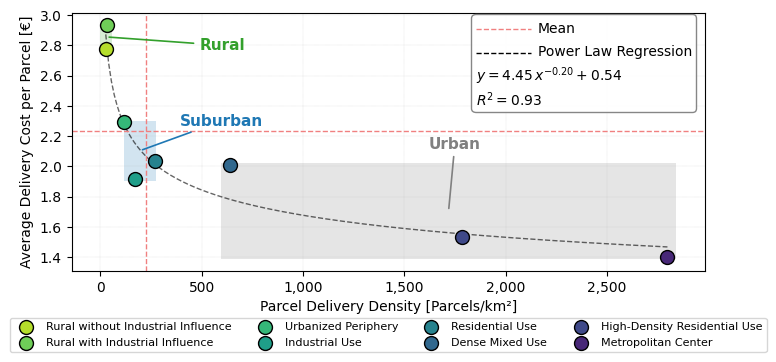

In [68]:
# --- Scatterplot: Tour inefficiency vs. parcel delivery density (with power law fit and area type background boxes) ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D
from matplotlib.offsetbox import DrawingArea, HPacker, VPacker, TextArea, AnnotationBbox
from matplotlib.patches import Rectangle
import matplotlib.ticker as ticker


# Area type mapping and colors (numeric raumtyp -> Urban/Suburban/Rural)
area_type_map = {
    1: 'Urban',
    2: 'Urban',
    3: 'Urban',
    4: 'Suburban',
    5: 'Suburban',
    6: 'Suburban',
    7: 'Rural',
    8: 'Rural',
}
area_type_colors = {'Urban': '#808080', 'Suburban': '#1f78b4', 'Rural': '#33a02c'}

# Map numeric area type to group (ensure int type)
plot_df['area_type_group'] = plot_df['raumtyp'].astype(int).map(area_type_map)

fig, ax = plt.subplots(figsize=(8, 4))

# Draw background boxes for each area type group
for group, color in area_type_colors.items():
    group_points = plot_df[plot_df['area_type_group'] == group]
    if group_points.empty:
        continue
    # Get min/max for box
    x_min, x_max = group_points['parcels_per_km2'].min(), group_points['parcels_per_km2'].max()
    y_min, y_max = group_points['cost_per_parcel'].min(), group_points['cost_per_parcel'].max()
    # Add a little padding
    x_pad = (x_max - x_min) * 0.02 if x_max > x_min else 1
    y_pad = (y_max - y_min) * 0.02 if y_max > y_min else 1
    
    # Compute global x span once, above the loop
    X_all = plot_df['parcels_per_km2'].to_numpy(dtype=float)
    global_x_span = np.nanmax(X_all) - np.nanmin(X_all)    
    
    # Inside the loop, replace the Rural special case with this
    if group == 'Rural' and len(group_points) == 2:
        x_vals = group_points['parcels_per_km2'].to_numpy(dtype=float)

        # Minimal span independent of mean to avoid degenerate boxes near zero
        min_span = max(0.02 * global_x_span, 10.0)  # 6 percent of global span or at least 50 units
        data_span = float(np.nanmax(x_vals) - np.nanmin(x_vals))
        span = max(data_span, min_span)

        mean_x = float(np.nanmean(x_vals))
        x_min = mean_x - 0.5 * span
        x_max = mean_x + 0.5 * span

        # Padding proportional to the span for a visible margin
        x_pad = 0.04 * span

        # Optional clamp to non negative densities
        x_min = max(0.0, x_min)
    rect = Rectangle((x_min - x_pad, y_min - y_pad), (x_max - x_min) + 2*x_pad, (y_max - y_min) + 2*y_pad,
                     color=color, alpha=0.2, zorder=1, linewidth=0)
    ax.add_patch(rect)
    
# Manuelle Label-Positionen
label_positions = {
    "Rural":     {"x": 600,  "y": 2.8},   # weiter rechts und oben
    "Suburban": {"x": 600, "y": 2.3},   # automatisch wie bisher
    "Urban":    {"x": 1750, "y": 2.15}     # manuell gesetzt
}

for group, color in area_type_colors.items():
    group_points = plot_df[plot_df['area_type_group'] == group]
    if group_points.empty:
        continue
    x_min, x_max = group_points['parcels_per_km2'].min(), group_points['parcels_per_km2'].max()
    y_min, y_max = group_points['cost_per_parcel'].min(), group_points['cost_per_parcel'].max()

    # Mittelpunkt der Box
    box_center_x = (x_min + x_max) / 2.0
    box_center_y = (y_min + y_max) / 2.0

    # Falls manuell gesetzt, überschreiben
    if label_positions[group]["x"] is not None:
        text_x = label_positions[group]["x"]
        text_y = label_positions[group]["y"]
    else:
        # Standard: Suburban leicht oberhalb
        text_x = box_center_x
        text_y = y_max + 0.35

    ax.annotate(
        group,
        xy=(box_center_x, box_center_y),   # Verbindungspunkt
        xytext=(text_x, text_y),           # Labelposition
        ha="center", va="center",
        fontsize=11, fontweight="bold", color=color,
        arrowprops=dict(arrowstyle="-", color=color, lw=1.2)
    )


# Scatter points
for area, color in category_color_dict.items():
    row = plot_df[plot_df['main_area_description'] == area]
    if row.empty:
        continue
    y = row['cost_per_parcel'].values[0]
    x = row['parcels_per_km2'].values[0]
    ax.scatter(x, y, color=color, edgecolor='k', s=100, label=area, zorder=3)

# Power law fit: y = a * x^b + c
def powerlaw_func(x, a, b, c):
    return a * np.power(x, b) + c

X = plot_df['parcels_per_km2'].values
Y = plot_df['cost_per_parcel'].values

# Use only positive X for power law
mask_pl = np.isfinite(X) & np.isfinite(Y) & (X > 0)
Xp, Yp = X[mask_pl], Y[mask_pl]

try:
    # Initial guess: a ~ range, b negative small, c ~ lower bound
    p0_pl = [Yp.max() - Yp.min(), -0.5, Yp.min()]
    popt_pl, _ = curve_fit(powerlaw_func, Xp, Yp, p0=p0_pl, maxfev=20000)

    x_range_pl = np.linspace(Xp.min(), Xp.max(), 200)
    y_fit_pl = powerlaw_func(x_range_pl, *popt_pl)
    ax.plot(x_range_pl, y_fit_pl, color="black", linestyle="--", linewidth=1, alpha=0.6)

    # R2
    y_pred_pl = powerlaw_func(Xp, *popt_pl)
    ss_res = np.sum((Yp - y_pred_pl) ** 2)
    ss_tot = np.sum((Yp - np.mean(Yp)) ** 2)
    r2_pl = 1.0 - ss_res / ss_tot
    print("Power law R2:", r2_pl)
except Exception as e:
    print("Power law fit failed:", e)

# Residuals and R2 for all points
residuals = Y - powerlaw_func(X, *popt_pl)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((Y - np.mean(Y))**2)
r2 = 1 - (ss_res / ss_tot)
print("R² =", r2)

# Median lines
# mp = np.median(X)
# md = np.median(Y)
mp = density_split_df["parcels_per_km2"].mean()
md= result["Cost per Parcel [€/parcel]"].mean()

ax.axvline(mp, color='lightcoral', linestyle='--', linewidth=1)
ax.axhline(md, color='lightcoral', linestyle='--', linewidth=1)

ax.set_xlabel('Parcel Delivery Density [Parcels/km²]')
ax.set_ylabel('Average Delivery Cost per Parcel [€]')
ax.grid(True, linestyle=':', linewidth=0.25)

# # Main legend for area types only (no fit in legend)
# handles, labels = ax.get_legend_handles_labels()
# area_handles_labels = [(h, l) for h, l in zip(handles, labels) if l in category_color_dict.keys()]
# if area_handles_labels:
#     area_handles, area_labels = zip(*area_handles_labels)
#     ax.legend(area_handles, area_labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True, fontsize=8)
# else:
#     ax.legend([], [], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True, fontsize=8)

# Main legend for area types only (no fit in legend)
handles, labels = ax.get_legend_handles_labels()

# Map labels to handles
label_to_handle = {l: h for h, l in zip(handles, labels)}

# Enforce order from category_color_dict
ordered_labels = [lbl for lbl in reversed(list(category_color_dict.keys())) if lbl in label_to_handle]
ordered_handles = [label_to_handle[lbl] for lbl in ordered_labels]

if ordered_handles:
    ax.legend(
        ordered_handles, 
        ordered_labels, 
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.16), 
        ncol=4, 
        frameon=True, 
        fontsize=8
    )
else:
    ax.legend([], [], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True, fontsize=8)


# Add regression function, R², and gray fit symbol as a text box in the top right
reg_label = r"$y = {:.2f} \, x^{{{:.2f}}} + {:.2f}$".format(*popt_pl)
r2_label = r"$R^2 = {:.2f}$".format(r2)
fit_label = "Power Law Regression"
median_label = "Mean"
# Create a gray dashed line symbol for the fit
fit_da = DrawingArea(40, 15, 0, 0)
fit_da.add_artist(Line2D([0, 40], [7, 7], color='black', linestyle='--', linewidth=1))
median_da = DrawingArea(40, 15, 0, 0)
median_da.add_artist(Line2D([0, 40], [7, 7], color='lightcoral', linestyle='--', linewidth=1))
median_box = HPacker(children=[median_da, TextArea(median_label)], align="center", pad=0, sep=5)
fit_box = HPacker(children=[fit_da, TextArea(fit_label)], align="center", pad=0, sep=5)

# Compose the annotation: fit, median, regression, r2
annotation_box = VPacker(children=[median_box, fit_box, TextArea(reg_label), TextArea(r2_label)], align="left", pad=0, sep=2)
props = dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='gray')
ab = AnnotationBbox(annotation_box, (0.98, 0.98), xycoords='axes fraction', box_alignment=(1,1), bboxprops=props, frameon=True)
ax.add_artist(ab)

# nach dem ax.set_xlabel(...)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("scatterplot_density_cost.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
density_split_df['area_type_group'] = density_split_df['raumtyp'].astype(str).map(category_dict)

In [ ]:
import numpy as np
from matplotlib.patches import Rectangle

# Compute per-group quantiles for parcels_per_km2
groups = ["Urban", "Suburban", "Rural"]
color_map = area_type_colors  # or use your category_color_dict mapping to these 3 labels

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
y_base = ymin + 0.06 * yr      # starting y position
y_step = 0.05 * yr             # vertical spacing between rows
bar_h  = 0.018 * yr            # thickness of the IQR box

for i, g in enumerate(groups):
    vals = density_split_df.loc[density_split_df["area_type_group"] == g, "parcels_per_km2"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        continue

    vmin = float(np.min(vals))
    vq1  = float(np.percentile(vals, 25))
    vmed = float(np.percentile(vals, 50))
    vq3  = float(np.percentile(vals, 75))
    vmax = float(np.max(vals))

    y = y_base + i * y_step
    c = color_map.get(g, "#666666")

    # min..max whisker
    ax.hlines(y, vmin, vmax, color=c, lw=2, alpha=0.9, zorder=2)

    # Q1..Q3 box
    ax.add_patch(Rectangle((vq1, y - bar_h/2.0),
                           vq3 - vq1, bar_h,
                           facecolor=c, edgecolor="none", alpha=0.25, zorder=2))

    # median marker
    ax.plot(vmed, y, marker="o", ms=4, color=c, mec="k", mew=0.5, zorder=3)

    # label
    ax.text(vmin, y + 0.9*bar_h, g, ha="right", va="bottom", fontsize=8, color=c)

# optional legend entry for the mini boxes
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color="k", lw=2, label="Density min..max"),
    Line2D([0], [0], color="k", lw=6, alpha=0.25, label="IQR"),
    Line2D([0], [0], marker="o", color="k", lw=0, label="Median", markersize=4)
]
# ax.legend(handles=legend_elems, loc="lower right", frameon=True, fontsize=8)


In [ ]:
plt.figure(figsize=(5, 4))
sns.stripplot(
    data=density_split_df,
    x="area_type_group",
    y="parcels_per_km2",
    palette=category_color_dict,
    jitter=0.25,
    alpha=0.6,
    size=3
)
plt.xlabel("Area Type")
plt.ylabel("Parcel Delivery Density [Parcels/km^2]")
plt.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Reproduzierbarkeit und Parameter
rng = np.random.default_rng(42)
n_boot = 100000
level = 0.95

# Farben
category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}

# Ellipsenfunktion auf Basis der Bootstraps der Mittelwerte
def ellipse_from_bootstrap(means, level=0.95):
    """
    means: Array der gebootstrappten Mittelwerte mit Form (B, 2)
    level: gewünschte Bedeckung, z. B. 0.95
    Rückgabe: center, width, height, angle
    """
    mu = means.mean(axis=0)
    cov = np.cov(means.T)
    # Eigenzerlegung der Kovarianz
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    # Mahalanobis Distanzen der Bootstraps
    diffs = means - mu
    inv_cov = np.linalg.inv(cov)
    md2 = np.einsum("ij,jk,ik->i", diffs, inv_cov, diffs)
    q = np.quantile(md2, level)  # Skalenfaktor^2
    a = np.sqrt(vals[0] * q)
    b = np.sqrt(vals[1] * q)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * a, 2 * b
    return mu, width, height, angle

# Aggregation wie gewünscht
agg = result.groupby('main_area_description').agg(
    ineff_perf=('inefficiency_perf', 'mean'),
    cost_per_parcel=('Cost per Parcel [€/parcel]', 'mean'),
    tour_count=('vehicle_id', 'count')
)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Legendeneinträge nur einmal
handled_labels = set()

for area, color in category_color_dict.items():
    if area not in agg.index:
        continue
    sub = result[result['main_area_description'] == area]
    if sub.empty or len(sub) < 3:
        # Für sehr kleine Stichproben keine Ellipse, nur Punkt
        mx = agg.at[area, 'ineff_perf']
        my = agg.at[area, 'cost_per_parcel']
        label = area if area not in handled_labels else None
        ax.scatter(mx, my, color=color, edgecolor='k', s=80, zorder=3, label=label)
        handled_labels.add(area)
        continue

    # Bootstrap der Mittelwerte
    vals = sub[['inefficiency_perf', 'Cost per Parcel [€/parcel]']].to_numpy()
    n = len(vals)
    means = np.empty((n_boot, 2))
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[b] = vals[idx].mean(axis=0)

    # Ellipse aus Bootstraps
    center, width, height, angle = ellipse_from_bootstrap(means, level=level)

    # Gefüllte Ellipse mit viel Alpha
    ell = Ellipse(
        xy=center, width=width, height=height, angle=angle,
        facecolor=color, edgecolor=color, alpha=0.18, linewidth=1.0, zorder=2
    )
    ax.add_patch(ell)

    # Punkt exakt auf den aggregierten Mittelwert
    mx = agg.at[area, 'ineff_perf']
    my = agg.at[area, 'cost_per_parcel']
    label = area if area not in handled_labels else None
    ax.scatter(mx, my, color=color, edgecolor='k', s=80, zorder=3, label=label, alpha=1)
    handled_labels.add(area)

# Medianlinien aus den aggregierten Werten
mp = agg['ineff_perf'].median()
mc = agg['cost_per_parcel'].median()
ax.axvline(mp, color='darkgray', linestyle='--', linewidth=1)
ax.axhline(mc, color='darkgray', linestyle='--', linewidth=1)

# aktuelle Achsengrenzen
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# horizontale und vertikale Mittelpunkte
x_left  = (x_min + mp) / 2
x_right = (x_max + mp) / 2
y_bottom = (y_min + mc) / 2
y_top    = (y_max + mc) / 2

# oben rechts
ax.text(x_right, y_top,
        "Strategic\nPriority\nZone",
        fontsize=30, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold', zorder=4)

# oben links
ax.text(x_left, y_top,
        "Financial\nPressure\nZone",
        fontsize=30, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold', zorder=4)

# unten links
ax.text(x_left, y_bottom,
        "Target\nOperating\nZone",
        fontsize=30, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold', zorder=4)

# unten rechts
ax.text(x_right, y_bottom,
        "Latent\nPotential\nZone",
        fontsize=30, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold', zorder=4)


ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),  # weiter nach unten verschieben
    ncol=4,
    frameon=True,
    fontsize=8,

)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # mehr Platz unten für die Legende

ax.set_xlabel('Average Tour Performance')
ax.set_ylabel('Average Delivery Cost per Parcel [€]')
ax.grid(True, linestyle=':', linewidth=0.5)
# ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Area Type')
# plt.tight_layout()
# plt.savefig("means_ellipse_bootstrap.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("means_ellipse_bootstrap.png", dpi=1000, bbox_inches="tight")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

order = [
    "Metropolitan Center",
    "High-Density Residential Use",
    "Dense Mixed Use",
    "Residential Use",
    "Industrial Use",
    "Urbanized Periphery",
    "Rural with Industrial Influence",
    "Rural without Industrial Influence"      
]

palette = {
    "Metropolitan Center": "#3b4cc0",
    "High-Density Residential Use": "#4b6ec2",
    "Dense Mixed Use": "#5a8ec1",
    "Residential Use": "#64a9ac",
    "Industrial Use": "#69b57a",
    "Urbanized Periphery": "#7fbe5a",
    "Rural with Industrial Influence": "#b3d23b",
    "Rural without Industrial Influence": "#e6e658",
}

x = "inefficiency_perf"
y = "Cost per Parcel [€/parcel]"

# globale Achsengrenzen einmal festlegen
xlim = (result[x].quantile(0.01), result[x].quantile(0.99))
ylim = (result[y].quantile(0.01), result[y].quantile(0.99))

g = sns.FacetGrid(
    data=result[result["main_area_description"].isin(order)],
    col="main_area_description",
    col_wrap=4,
    hue="main_area_description",
    col_order=order,   # <- Reihenfolge fix
    palette=palette,
    sharex=True,
    sharey=True,
    height=2.6
)

g.map_dataframe(
    sns.kdeplot,
    x=x, y=y,
    fill=False,
    levels=[0.1, 0.3, 0.5, 0.7, 0.9],
    thresh=0.05,
    linewidths=1.2
)

for ax, cat in zip(g.axes.flatten(), order):
    sub = result[result["main_area_description"] == cat]
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, linestyle=":", linewidth=0.5)
    ax.set_title(f"{cat}\n n={len(sub)}", fontsize=9)
    # optionale globale Medianlinien
    # ax.axvline(result[x].median(), color="0.6", linestyle="--", linewidth=0.8)
    # ax.axhline(result[y].median(), color="0.6", linestyle="--", linewidth=0.8)

g.set_xlabels("Performance Inefficiency")
g.set_ylabels("Delivery Cost per Parcel [€]")
plt.tight_layout()
# plt.savefig("kde_small_multiples.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ----------------------
# 9) Statistische Auswertung
# ----------------------

# Globale Mittelwerte
avg_cost = agg['cost_per_parcel'].mean()
avg_ineff = agg['ineff_perf'].mean()

print("=== Durchschnittswerte (über alle Area Types) ===")
print(f"Average inefficiency: {avg_ineff:.3f}")
print(f"Average cost per parcel: {avg_cost:.2f} €")
print()

# Bereichsdefinitionen für Quadranten
zones = {
    "Strategic Priority Zone (oben rechts)": {
        "inefficiency": f"> {mp:.3f}",
        "cost": f"> {mc:.2f}"
    },
    "Financial Pressure Zone (oben links)": {
        "inefficiency": f"≤ {mp:.3f}",
        "cost": f"> {mc:.2f}"
    },
    "Target Operating Zone (unten links)": {
        "inefficiency": f"≤ {mp:.3f}",
        "cost": f"≤ {mc:.2f}"
    },
    "Latent Potential Zone (unten rechts)": {
        "inefficiency": f"> {mp:.3f}",
        "cost": f"≤ {mc:.2f}"
    }
}

print("=== Zonenbereiche (Definition) ===")
for zone, cond in zones.items():
    print(f"{zone}: Inefficiency {cond['inefficiency']}, Cost {cond['cost']}")

# Optional: Zählung wie viele Area Types in welchem Quadranten liegen
def classify(x, y, mp, mc):
    if x > mp and y > mc:
        return "Strategic Priority Zone"
    elif x <= mp and y > mc:
        return "Financial Pressure Zone"
    elif x <= mp and y <= mc:
        return "Target Operating Zone"
    else:
        return "Latent Potential Zone"

# Klassifikation je Area Type
def classify(x, y, mp, mc):
    if x > mp and y > mc:
        return "Strategic Priority Zone"
    elif x <= mp and y > mc:
        return "Financial Pressure Zone"
    elif x <= mp and y <= mc:
        return "Target Operating Zone"
    else:
        return "Latent Potential Zone"

agg['zone'] = agg.apply(
    lambda r: classify(r['ineff_perf'], r['cost_per_parcel'], mp, mc), axis=1
)

print()
print("=== Area Types nach Zonen ===")
for zone, subset in agg.groupby('zone'):
    print(f"\n{zone} ({len(subset)} Area Types):")
    for area in subset.index:
        inef = subset.at[area, 'ineff_perf']
        cost = subset.at[area, 'cost_per_parcel']
        print(f"  - {area}: ineff={inef:.3f}, cost={cost:.2f} €")


In [ ]:
# Boxplot grid with fixed y-limits for Mean Distance (<=4 km) and Utilization (<=100%)
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure utilization column is in percent (scale if looks fractional)
if 'Vehicle Utilization (%)' in bc_selected.columns:
    s = pd.to_numeric(bc_selected['Vehicle Utilization (%)'], errors='coerce')
    if s.notna().any() and s.max() <= 1.5:
        bc_selected = bc_selected.copy()
        bc_selected['Vehicle Utilization (%)'] = s * 100.0

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7.8, 4.25))
order = list(reversed(palette_dict.keys()))
plot_titles = ['Tour Length [km]', 'Tour Duration [hrs]', 
               'Driving Share of Tour [%]', 'Vehicle Utilization [%]', 
               'Mean Distance Between Stops [km]', 'Average Speed [km/h]']

y_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)', 
               'Driving Share of Tour (%)', 'Vehicle Utilization (%)', 
               'Mean Distance Between Stops (km)', 'Average Speed (km/h)']

y_axis_labels = ['(km)', '(hrs)', 
                 '(%)', '(%)', 
                 '(km)', '(km/h)']

x_axis_col = 'main_area_type_desc'

for i, ax in enumerate(axes.flat):
    sns.boxplot(
        data=bc_selected, y=y_axes_cols[i], x=x_axis_col, ax=ax,
        palette=palette_dict, order=order, linewidth=0.5,
        flierprops={"marker": ".", "markersize": 3}
    )
    ax.set_title(plot_titles[i], fontsize=8, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(y_axis_labels[i], fontsize=8)
    ax.tick_params(axis='x', labelbottom=False)
    ax.grid(True)
    ax.legend().set_visible(False)
    ax.set_xlabel("Area Types \n", fontsize=8)

    # Apply requested y-limits
    if y_axes_cols[i] == 'Mean Distance Between Stops (km)':
        ax.set_ylim(0, 4)
    elif y_axes_cols[i] == 'Vehicle Utilization (%)':
        ax.set_ylim(0, 100)

handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=v,
               markeredgewidth=0.5, markeredgecolor='black', markersize=8)
    for v in reversed(palette_dict.values())
]
fig.legend(handles, custom_legend_labels, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 0.035), fontsize=8)

plt.tight_layout(rect=[0, 0.001, 1, 0.9999])
plt.savefig("box_distribution_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

<Axes: >

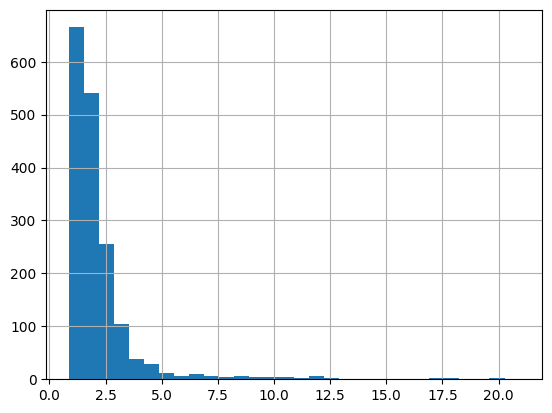

In [69]:
result["Cost per Parcel [€/parcel]"].hist(bins=30)

In [ ]:
# Plot all points from the flat list of Point objects in result['coords_list_converted']
import matplotlib.pyplot as plt
from shapely.geometry import Point

all_x = []
all_y = []
for point_list in result['coords_list']:
    for pt in point_list:
        if isinstance(pt, Point):
            all_x.append(pt.x)
            all_y.append(pt.y)

plt.figure(figsize=(10, 8))
plt.scatter(all_x, all_y, s=2, alpha=0.7)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('All Delivery Points')
plt.tight_layout()
plt.show()

In [ ]:
# Plot: black background, points colored by cost, colorbar from 1 to 5, values >5 clipped, filter by carrier
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np

# Filter DataFrame by carrier name, e.g. 'dhl'
carrier_filter = 'dhl'  # <--- change this to your desired carrier
filtered = result[result['carrier_name2'] == carrier_filter]

all_x = []
all_y = []
all_costs = []
for point_list, avg_cost in zip(filtered['coords_list'], filtered['Cost per Parcel [€/parcel]']):
    for pt in point_list:
        if isinstance(pt, Point):
            all_x.append(pt.x)
            all_y.append(pt.y)
            # Clip cost to max 5, min 1
            clipped_cost = min(max(float(avg_cost), 1), 5)
            all_costs.append(clipped_cost)
all_costs = np.array(all_costs)

plt.figure(figsize=(10, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
sc = plt.scatter(all_x, all_y, c=all_costs, cmap='plasma', s=0.25, alpha=0.8, vmin=1, vmax=5)
cbar = plt.colorbar(sc, ticks=[1,2,3,4,5])
cbar.set_label('Avg. Cost per Parcel [€/parcel]', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.set_yticklabels(['1','2','3','4','5+'], color='white')
cbar.ax.tick_params(colors='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')
# Remove axis ticks and labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.tight_layout()
plt.show()

In [117]:
# Plot: black background, points colored by cost, colorbar from 1 to 5, values >5 clipped
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np

# Filter DataFrame by carrier name, e.g. 'dhl'
# carrier_filter = 'hermes'  # <--- change this to your desired carrier
# filtered = result[result['carrier_name'] == carrier_filter]
filtered = result


all_x = []
all_y = []
all_costs = []
for point_list, avg_cost in zip(filtered['coords_list'], filtered['Cost per Parcel [€/parcel]']):
    for pt in point_list:
        if isinstance(pt, Point):
            all_x.append(pt.x)
            all_y.append(pt.y)
            # Clip cost to max 5, min 1
            clipped_cost = min(max(float(avg_cost), 1), 5)
            all_costs.append(clipped_cost)
all_costs = np.array(all_costs)



In [185]:
# 3D Hexbin-Bars: Höhe = avg. cost, Farbe = dominant region type (präzise mit sjoin, NumPy 2.0 fix)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point
from mpl_toolkits.mplot3d import Axes3D
import geopandas as gpd
from collections import Counter

# Filter DataFrame by carrier name, e.g. 'amazon'
carrier_filter = 'hermes'
# filtered = result[result['provider'] == carrier_filter]
filtered = result

# Alle Servicepunkte als GeoDataFrame
points = []
costs = []
for point_list, avg_cost in zip(filtered['coords_list'], filtered['Cost per Parcel [€/parcel]']):
    for pt in point_list:
        if isinstance(pt, Point):
            points.append(pt)
            costs.append(float(avg_cost))
gdf_points = gpd.GeoDataFrame({'cost': costs}, geometry=points, crs=regionclusters_split.crs)

# Präzise Zuordnung: sjoin zu regionclusters_split
joined = gpd.sjoin(gdf_points, regionclusters_split[['area_type','geometry']], how='left', predicate='within')

# # Hexbin-Grid berechnen
# hex_size = 10000  # 1km
# x = joined.geometry.x.values
# y = joined.geometry.y.values
# x_span = x.max() - x.min()
# gridsize = max(1, int(x_span / hex_size))

# # Hexbin: für jeden Hex die Indices der Punkte
# fig, ax = plt.subplots()
# hb = ax.hexbin(x, y, gridsize=gridsize, mincnt=1)
# plt.close(fig)
# verts = hb.get_offsets()
# # NumPy 2.0 fix: use np.ptp instead of .ptp()
# hex_radius = (np.ptp(hb.get_paths()[0].vertices[:,0]))/2

# # Für jeden Hex: Mittelwert Kosten, dominant area_type
# hex_heights = []
# hex_colors = []
# category_color_dict = {
#     "Metropolitan Center": "#482878",
#     "High-Density Residential Use": "#3f4989",
#     "Dense Mixed Use": "#31688e",
#     "Residential Use": "#26828e",
#     "Industrial Use": "#1f9e89",
#     "Urbanized Periphery": "#35b779",
#     "Rural with Industrial Influence": "#6fce58",
#     "Rural without Industrial Influence": "#b5de2b"
# }
# category_color_dict = {
#     "Metropolitan Center": "#482878",
#     "High-Density Residential Use": "#3f4989",
#     "Dense Mixed Use": "#31688e",
#     "Residential Use": "#26828e",
#     "Industrial Use": "#1f9e89",
#     "Urbanized Periphery": "#35b779",
#     "Rural with Industrial Influence": "#6fce58",
#     "Rural without Industrial Influence": "#b5de2b"
# }
# for hx, hy in verts:
#     # Punkte im Hexagon finden
#     dx = x - hx
#     dy = y - hy
#     mask = (np.abs(dx) < hex_radius) & (np.abs(dy) < hex_radius)
#     if not np.any(mask):
#         continue
#     costs_in_hex = joined.loc[mask, 'cost']
#     types_in_hex = joined.loc[mask, 'area_type']
#     avg_cost = costs_in_hex.mean()
#     # Dominanter area_type
#     if not types_in_hex.isnull().all():
#         dom_type = types_in_hex.value_counts().idxmax()
#         color = category_color_dict.get(dom_type, '#888888')
#     else:
#         color = '#888888'
#     hex_heights.append((hx, hy, avg_cost, color))

# # 3D-Plot
# fig = plt.figure(figsize=(12, 10))
# ax = fig.add_subplot(111, projection='3d')
# for hx, hy, height, color in hex_heights:
#     ax.bar3d(hx, hy, 0, hex_size, hex_size, height, color=color, alpha=0.9, shade=True)

# ax.set_xlabel('X Coordinate')
# ax.set_ylabel('Y Coordinate')
# ax.set_zlabel('Avg. Cost per Parcel [€/parcel]')
# ax.set_title('3D Hexbin: Avg. Cost per Parcel by Region')
# plt.tight_layout()
# plt.show()

In [768]:
sns.set()
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [783]:
# Hexbin-Grid berechnen
hex_size = 10000  # 10km
x = joined.geometry.x.values
y = joined.geometry.y.values
x_span = x.max() - x.min()
gridsize = max(1, int(x_span / hex_size))

# Hexbin: für jeden Hex die Indices der Punkte
fig, ax = plt.subplots()
hb = ax.hexbin(x, y, gridsize=gridsize, mincnt=1)
plt.close(fig)
verts = hb.get_offsets()
# NumPy 2.0 fix: use np.ptp instead of .ptp()
hex_radius = (np.ptp(hb.get_paths()[0].vertices[:,0]))/2

# Für jeden Hex: Mittelwert Kosten, dominant area_type
hex_heights = []
hex_colors = []
category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}
for hx, hy in verts:
    # Punkte im Hexagon finden
    dx = x - hx
    dy = y - hy
    mask = (np.abs(dx) < hex_radius) & (np.abs(dy) < hex_radius)
    if not np.any(mask):
        continue
    costs_in_hex = joined.loc[mask, 'cost']
    types_in_hex = joined.loc[mask, 'area_type']
    avg_cost = costs_in_hex.mean()
    # Dominanter area_type
    if not types_in_hex.isnull().all():
        dom_type = types_in_hex.value_counts().idxmax()
        color = category_color_dict.get(dom_type, '#888888')
    else:
        color = '#888888'
    hex_heights.append((hx, hy, avg_cost, color))

In [784]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

# Deine Daten: hex_heights enthält (hx, hy, avg_cost, color)
hx = np.array([h[0] for h in hex_heights])
hy = np.array([h[1] for h in hex_heights])
costs = np.array([h[2] for h in hex_heights])

# Gitter für Interpolation erstellen
grid_x, grid_y = np.mgrid[hx.min():hx.max():200j, hy.min():hy.max():200j]

# Interpolation der Kostenwerte
grid_z = griddata((hx, hy), costs, (grid_x, grid_y), method='cubic')




In [785]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import shapely
from shapely.geometry import Polygon, MultiPolygon

import geopandas as gpd
from scipy.interpolate import griddata

from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from matplotlib.patches import Patch

from shapely.ops import unary_union



# # Optional: if cubic returns NaN at the borders, fill with nearest
# if np.isnan(grid_z).any():
#     grid_z_nearest = griddata((hx, hy), costs, (grid_x, grid_y), method="nearest")
#     nan_mask = np.isnan(grid_z)
#     grid_z[nan_mask] = grid_z_nearest[nan_mask]

# 2) Helper to add polygons of regionclusters_split on z=0
def _rotate_xy(xa, ya, cx, cy, deg):
    """Rotate arrays xa, ya around center (cx, cy) by deg degrees."""
    xa = np.asarray(xa, dtype=float)
    ya = np.asarray(ya, dtype=float)
    theta = np.deg2rad(float(deg))
    ct, st = np.cos(theta), np.sin(theta)
    dx = xa - cx
    dy = ya - cy
    xr = cx + ct * dx - st * dy
    yr = cy + st * dx + ct * dy
    return xr, yr

def _transform_xy(xa, ya, cx, cy, rotate_deg=0.0,
                  swap_xy=False, mirror_x=False, mirror_y=False):
    """Apply swap, rotation around (cx, cy), and optional mirroring."""
    xa = np.asarray(xa, dtype=float)
    ya = np.asarray(ya, dtype=float)

    if swap_xy:
        xa, ya = ya, xa

    if rotate_deg:
        xa, ya = _rotate_xy(xa, ya, cx, cy, rotate_deg)

    if mirror_x:
        xa = 2.0 * cx - xa
    if mirror_y:
        ya = 2.0 * cy - ya

    return xa, ya

def _draw_polygon3d(ax3d, geom, z=0.01, facecolor=(1,1,1,0.8),
                    edgecolor=(0,0,0,1), alpha=1.0, lw=0.8,
                    rotate_deg=0.0, origin=None,
                    swap_xy=False, mirror_x=False, mirror_y=False,
                    zsort_mode="max", sort_zpos=None):
    """
    Draw a single Shapely Polygon or MultiPolygon at height z.
    Supports rotation, swap of X and Y, mirroring, and sort priority.
    """
    if geom is None or geom.is_empty:
        return

    # choose center for rotation and mirroring
    if origin is None:
        c = geom.centroid
        cx, cy = float(c.x), float(c.y)
    else:
        cx, cy = float(origin[0]), float(origin[1])

    parts = [geom] if geom.geom_type == "Polygon" else list(getattr(geom, "geoms", []))
    for poly in parts:
        ex_x, ex_y = poly.exterior.coords.xy
        ex_x, ex_y = _transform_xy(ex_x, ex_y, cx, cy, rotate_deg, swap_xy, mirror_x, mirror_y)
        verts_ex = [(float(x), float(y), float(z)) for x, y in zip(ex_x, ex_y)]
        coll = Poly3DCollection([verts_ex], facecolors=facecolor,
                                edgecolors=edgecolor, linewidths=lw, alpha=alpha)
        coll.set_clip_on(False)
        coll.set_zsort(zsort_mode)
        if sort_zpos is not None:
            coll.set_sort_zpos(float(sort_zpos))
        ax3d.add_collection3d(coll)

        for interior in poly.interiors:
            in_x, in_y = interior.coords.xy
            in_x, in_y = _transform_xy(in_x, in_y, cx, cy, rotate_deg, swap_xy, mirror_x, mirror_y)
            verts_in = [(float(x), float(y), float(z)) for x, y in zip(in_x, in_y)]
            hole = Poly3DCollection([verts_in], facecolors=(1,1,1,0),
                                    edgecolors=edgecolor, linewidths=max(0.5*lw, 0.3), alpha=1)
            hole.set_clip_on(False)
            hole.set_zsort(zsort_mode)
            if sort_zpos is not None:
                hole.set_sort_zpos(float(sort_zpos))
            ax3d.add_collection3d(hole)

def add_polygons_on_z0(ax3d, gdf, color_map,
                       edgecolor=(0.4, 0.4, 0.4, 1.0),
                       default_color=(0.85, 0.85, 0.85, 1.0),
                       alpha=1.0, draw_legend=True, z0=0.0,
                       swap_xy=False, rotate_deg=0.0,
                       mirror_x=False, mirror_y=False,
                       force_back=False):
    """
    Draw all polygons from gdf on z=z0.
    Rotation, swap, mirroring supported.
    force_back sets a very low sort position so these stay behind others.
    """
    # pick area type column
    area_col = None
    for cand in ["area_type", "main_area_type_name", "raumtyp", "main_area_description"]:
        if cand in gdf.columns:
            area_col = cand
            break

    # global center for consistent transform across all polygons
    minx, miny, maxx, maxy = gdf.total_bounds
    origin = (0.5*(float(minx)+float(maxx)), 0.5*(float(miny)+float(maxy)))

    used = set()
    back_bias = -1e6 if force_back else None

    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        at = row.get(area_col, None) if area_col else None
        fc = color_map.get(at, default_color)

        _draw_polygon3d(ax3d, geom, z=z0, facecolor=fc, edgecolor=edgecolor, alpha=alpha, lw=0.35,
                        rotate_deg=rotate_deg, origin=origin,
                        swap_xy=swap_xy, mirror_x=mirror_x, mirror_y=mirror_y,
                        zsort_mode="min" if force_back else "max", sort_zpos=back_bias)

        if at in color_map:
            used.add(at)

    if draw_legend and used:
        patches = [Patch(facecolor=color_map[k], edgecolor=edgecolor, label=k) for k in sorted(used)]
        ax3d.legend(handles=patches, loc="upper left", bbox_to_anchor=(1.02, 1.0),
                    frameon=False, title="Area type")




def make_hub_union(hubs_df, radius_m=800.0, circle_sides=32):
    disks = []
    for _, r in hubs_df.iterrows():
        x = float(r["X"]); y = float(r["Y"])
        try:
            d = Point(x, y).buffer(radius_m, quad_segs=circle_sides)  # shapely 1
        except TypeError:
            d = Point(x, y).buffer(radius_m, resolution=circle_sides)  # shapely 2
        disks.append(d)
    if not disks:
        return None
    return unary_union(disks)

def punch_holes_under_hubs(gdf, hub_union):
    """Subtrahiert die Hub Union nur bei tatsächlich betroffenen Polygonen."""
    if hub_union is None or hub_union.is_empty:
        return gdf.copy()
    out = gdf.copy()
    # nur die schneidenden Polygone anfassen, sonst bleibt es schnell
    idx = out.sindex.query(hub_union, predicate="intersects")
    out.loc[idx, "geometry"] = out.loc[idx, "geometry"].difference(hub_union)
    return out

# Rotation des Grids um 90 Grad um den Mittelpunkt
def rotate_grid(xg, yg, cx, cy, deg):
    th = np.deg2rad(deg)
    ct, st = np.cos(th), np.sin(th)
    dx = xg - cx
    dy = yg - cy
    xr = cx + ct*dx - st*dy
    yr = cy + st*dx + ct*dy
    return xr, yr

In [796]:
# --- Provider-Farben (DP/DHL = DHL) ---
prov_colors = {
    "dhl":      "#FFCC00",
    "dp/dhl":   "#FFCC00",
    "dpd":      "#E3000B",
    "gls":      "#1C3F95",
    "ups":      "#392312",
    "hermes":   "#00A0E1",
    "amazon":   "#00A8E1",
    "fedex":    "#4D148C"
}

# --- robust: Hubs -> Union mit kleiner Sicherheitsmarge ---
def make_hub_union(hubs_df, radius_m=600.0, grow=1.01, eps=2.0, circle_sides=64):
    disks = []
    R = float(radius_m) * float(grow)   # 1–2% größer
    for _, r in hubs_df.iterrows():
        x, y = float(r["X"]), float(r["Y"])
        try:
            d = Point(x, y).buffer(R, quad_segs=circle_sides)
        except TypeError:
            d = Point(x, y).buffer(R, resolution=circle_sides)
        disks.append(d)
    U = unary_union(disks)
    # winzig aufdicken, damit "touches" zu echter Überlappung wird
    U = U.buffer(float(eps))
    return U

# --- Polygone minus Hub-Union (mit Reparatur) ---
def punch_holes_under_hubs(gdf, hub_union):
    gdf = gdf.copy()
    # leichte Geometrie-Reparatur gegen invalide Polygone
    gdf["geometry"] = gdf.geometry.buffer(0)
    out_rows = []
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        # nur schneiden, wenn wirklich Überschneidung besteht
        if geom.intersects(hub_union):
            new_geom = geom.difference(hub_union)
        else:
            new_geom = geom
        if new_geom is None or new_geom.is_empty:
            continue
        new_row = row.copy()
        new_row.geometry = new_geom
        out_rows.append(new_row)
    return gpd.GeoDataFrame(out_rows, crs=gdf.crs)


In [818]:
import numpy as np
from shapely.geometry import Point
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Falls noch nicht vorhanden – gleiche Transformation wie bei deinen Polygons
def _rotate_xy(xa, ya, cx, cy, deg):
    th = np.deg2rad(float(deg))
    c, s = np.cos(th), np.sin(th)
    dx, dy = xa - cx, ya - cy
    return cx + c*dx - s*dy, cy + s*dx + c*dy

def _transform_xy(xa, ya, cx, cy, rotate_deg=0.0, swap_xy=False, mirror_x=False, mirror_y=False):
    xa = np.asarray(xa, float); ya = np.asarray(ya, float)
    if swap_xy: xa, ya = ya, xa
    if rotate_deg: xa, ya = _rotate_xy(xa, ya, cx, cy, rotate_deg)
    if mirror_x: xa = 2*cx - xa
    if mirror_y: ya = 2*cy - ya
    return xa, ya

def add_hub_flags(ax3d, hubs_df, prov_colors, origin,
                  rotate_deg=0.0, swap_xy=False, mirror_x=False, mirror_y=False,
                  z0=0.0, eps=1e-3,
                  pole_h_frac=0.18,   # Anteil der Z-Spanne für die Mast-Höhe
                  flag_w=800.0,       # Breite des Fähnchens (m, in deiner CRS)
                  flag_h=450.0,       # Höhe des Fähnchens (m)
                  edgecolor=(0,0,0,1), pole_lw=1.2, flag_lw=0.8,
                  label_key="Typ", label_fs=8, label_dz=0.02,
                  grid=None):
    """
    Zeichnet für jeden Hub ein Fähnchen:
      - Mast ab z0+eps bis z0+eps+H
      - Rechteck (Fahne) in Anbieter-Farbe am Mastkopf
    prov_colors: dict (anbieter -> farbe)
    origin: (cx,cy), damit Rotation wie bei Basemap identisch ist
    grid: optional (Xr, Yr, Z) – dann heben wir die Fahnen-Basis über die Oberfläche
    """
    cx, cy = origin
    zmin, zmax = ax3d.get_zlim()
    zspan = (zmax - zmin) if (zmax > zmin) else 1.0
    H = pole_h_frac * zspan

    # optional über die Oberfläche anheben
    def base_z_at(xr, yr):
        if grid is None:
            return z0 + eps
        Xr, Yr, Z = grid
        # nächster Gitterpunkt
        i = np.argmin(np.abs(Xr[:,0] - xr))
        j = np.argmin(np.abs(Yr[0,:] - yr))
        z_here = float(Z[i, j]) if np.isfinite(Z[i, j]) else z0
        return max(z0 + eps, z_here + 0.03*zspan)
    
    def normalize_provider(s: str) -> str:
        s = str(s).strip().lower()
        # unify common aliases
        if s in ("dp dhl", "dpdhl", "deutsche post", "deutsche post/dhl"):
            return "dp/dhl"
        if s in ("gpd",):
            return "dpd"
        return s

    # 1) Add normalized provider and priority
    tmp = hubs_df.copy()
    tmp["prov_norm"] = tmp["Anbieter"].map(normalize_provider)

    # Priority: DHL first (0), most others in middle (1), GLS (2), DPD last (3)
    priority_map = {"ups":5, "hermes":6, "dp/dhl": 4, "dhl": 3,"fedex":7, "gls": 0, "dpd": 1}
    tmp["priority"] = tmp["prov_norm"].map(priority_map).fillna(10).astype(int)

    # Optional: stable tie-breakers
    tmp["_order_idx"] = np.arange(len(tmp))

    # 2) Sort by priority (and keep stable order within groups)
    hubs_sorted = tmp.sort_values(["priority", "_order_idx"], kind="mergesort")
    
    LEFT_LABEL_PROVIDERS = {"dpd", "fedex"}


    for _, r in hubs_sorted.iterrows():
        x = float(r["X"]); y = float(r["Y"])

        # Anbieter -> Farbe (robust mappen)
        lab = str(r.get("Anbieter", "")).strip().lower()
        if lab in ("dp/dhl"): lab = "dhl"
        color = prov_colors.get(lab, "#FFCC00")

        # transformierte Hub-Position (gleich wie Basemap)
        xt, yt = _transform_xy(np.array([x]), np.array([y]),
                               cx, cy, rotate_deg, swap_xy, mirror_x, mirror_y)
        xt, yt = float(xt[0]), float(yt[0])

        z_base = base_z_at(xt, yt)
        z_top  = z_base + H

        # 1) Mast
        line = ax3d.plot([xt, xt], [yt, yt], [z_base, z_top],
                         color=color, linewidth=pole_lw*3, solid_capstyle="round", zorder=1000, alpha=1)[0]
        line.set_zorder(116)
        line.set_rasterized(True)
        
        line.set_path_effects([
        pe.Stroke(linewidth=pole_lw*3.15, foreground="k"),
        pe.Normal()
        ])       

        
        # sinnvolle Offsets relativ zur Ausdehnung der Szene
        x_span = ax3d.get_xlim()[1] - ax3d.get_xlim()[0]
        y_span = ax3d.get_ylim()[1] - ax3d.get_ylim()[0]
        dx = 0.01 * x_span
        dy = 0.00 * y_span
        
        ha = "left"
        x_text = xt + dx
        if lab in LEFT_LABEL_PROVIDERS:
            x_text = xt - dx
            ha = "right"

        # Text an der Mastspitze platzieren
        txt = ax3d.text(x_text, yt + dy, z_top,
                        lab.strip().upper(),
                        ha=ha, va="center",
                        fontsize=8, color="black",
                        zorder=116, clip_on=False,
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))


In [2]:
hubs = pd.read_csv("KEP-hubs_v3.csv", sep=";")
hubs

,X,Y,Anbieter,Bezeichnun,Typ,Straße,Postleitzahl,Ort
0,559605.059550,5.801323e+06,DHL,Paketzentrum / Zustellbasis Anderten,PZ/ZB,Kleiner Holzhägen 2,30559,Hannover_Anderten
1,549686.455778,5.804338e+06,DHL,Zustellbasis Hannover am Güterbahnhof,ZB,Gertrud-Knebusch-Straße 11,30167,Hannover_Güterbahnhof
2,548255.731128,5.800066e+06,DHL,Zustellbasis Hannover-Süd,ZB,Mercedesstraße 5,30453,Hannover_Süd
3,553326.446313,5.790296e+06,DHL,Brief- und Logistikzentrum in Pattensen (Hanno...,BZ,Ludwig-Erhard-Str. 39,30982,Pattensen
4,532555.807673,5.817483e+06,DP/DHL,"Deutsche Post, Neustadt",ZSP,Justus-von-Liebig-Straße,31535,Neustadt_am_Rübenberge
5,538668.436409,5.811042e+06,DP/DHL,"Deutsche Post, Garbsen",ZSP,Molkereistraße 13,30826,Garbsen
6,547039.230776,5.811060e+06,Hermes,Hermes LC Hannover Langenhagen,PZ,Münchner Str. 39,30855,Langenhagen
7,538731.347746,5.808451e+06,Amazon,Amazon Logistics HAJ8 in Garbsen,PZ,Grabenfeldstraße,30826,Garbsen
8,564735.633715,5.804057e+06,DPD,DPD Paketzentrum in Lehrte,PZ,Europastraße 1,31275,Lehrte
9,555795.773975,5.792960e+06,GLS,GLS in Hannover Laatzen,PZ,Koldinger Straße 1,30880,Laatzen


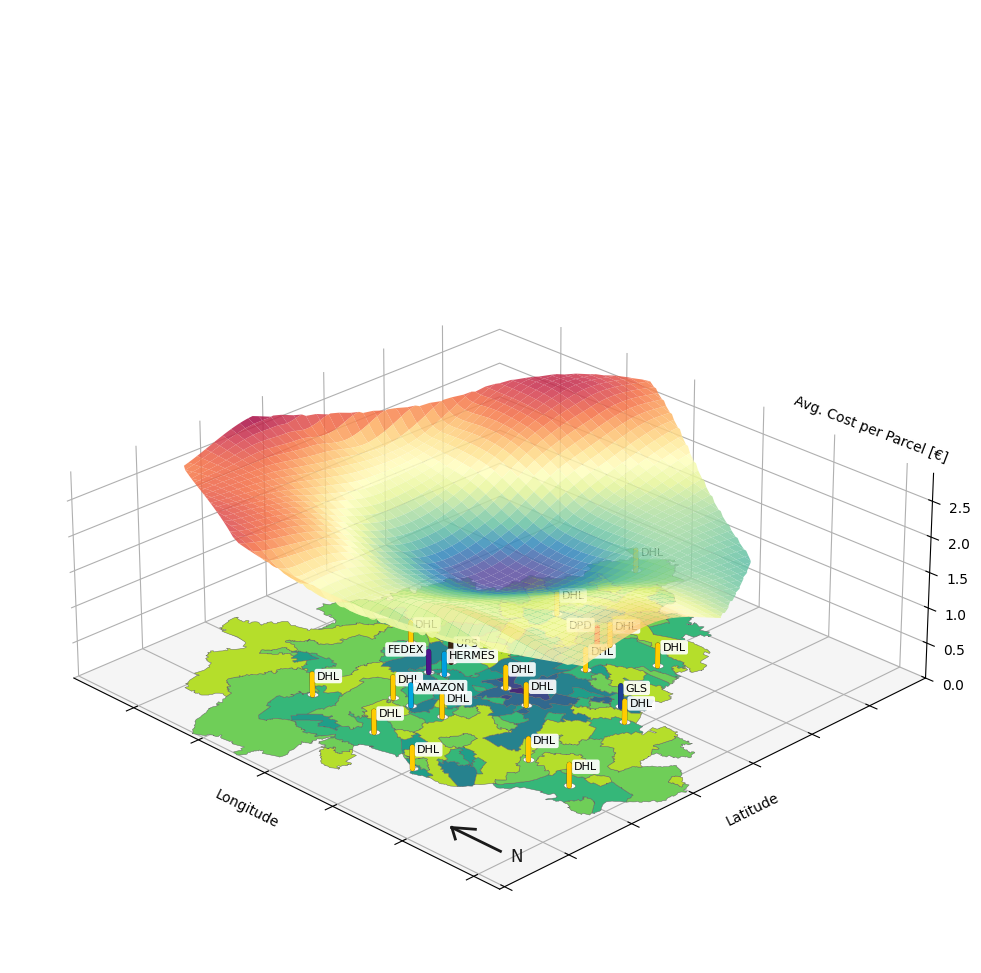

In [819]:
from shapely.geometry import Point, Polygon, MultiPolygon
from scipy.interpolate import griddata

from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib import patheffects as pe

# # Build interpolation grid for a smooth surface
# grid_x, grid_y = np.mgrid[hx.min():hx.max():200j, hy.min():hy.max():200j]
# grid_z = griddata((hx, hy), costs, (grid_x, grid_y), method="cubic")

# Do not fill holes. Mask invalid values so they are not plotted.
grid_z_masked = np.ma.masked_invalid(grid_z)

# Optional: restrict color range to finite costs only
finite_costs = costs[np.isfinite(costs)]
vmin = float(np.nanmin(finite_costs))
vmax = float(np.nanmax(finite_costs))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# hub_radius = 600.0 
# hub_union = make_hub_union(hubs, radius_m=hub_radius, circle_sides=64)
# # 2 Basemap ausstanzen
# base_cols = ["area_type", "geometry"] if "area_type" in regionclusters_split.columns else ["geometry"]
# base_punched = punch_holes_under_hubs(regionclusters_split[base_cols], hub_union)

hub_radius = 600.0
hub_union = make_hub_union(hubs, radius_m=hub_radius, grow=1.005, eps=0)

base_cols = ["area_type","geometry"] if "area_type" in regionclusters_split.columns else ["geometry"]
base_punched = punch_holes_under_hubs(regionclusters_split[base_cols], hub_union)

# common origin so that polygons and hubs rotate the same way
minx, miny, maxx, maxy = regionclusters_split.total_bounds
origin = (0.5*(minx+maxx), 0.5*(miny+maxy))

# 3 Basemap zeichnen, wie gehabt
add_polygons_on_z0(
    ax, base_punched, category_color_dict,
    alpha=1, draw_legend=False, z0=0.0,
    swap_xy=False, rotate_deg=90.0, mirror_x=False, mirror_y=False,
    force_back=True
)

# Mittelpunkt fuer die Rotation
cx = 0.5 * (float(grid_x.min()) + float(grid_x.max()))
cy = 0.5 * (float(grid_y.min()) + float(grid_y.max()))

# 90 Grad drehen
Xr, Yr = rotate_grid(grid_x, grid_y, cx, cy, 90.0)

# Surface geplottet mit rotierten Koordinaten
surf = ax.plot_surface(
    Xr, Yr, grid_z_masked,
    cmap="Spectral_r",
    linewidth=0,
    antialiased=True,
    alpha=0.85,
    vmin=vmin, vmax=vmax
)
surf.set_rasterized(True)
surf.set_zorder(99999)  # hinter die Fahnen

grid_for_flags = (Xr, Yr, grid_z_masked)

add_hub_flags(
    ax3d=ax,
    hubs_df=hubs,
    prov_colors=prov_colors,        # dein Anbieter->Farbe dict
    origin=origin,
    rotate_deg=90.0, swap_xy=False, mirror_x=False, mirror_y=False,
    z0=-0.10, eps=1e-3,
    pole_h_frac=0.1,               # Höhe der Masten (relativ zur Z-Spanne)
    flag_w=800.0, flag_h=450.0,     # Größe der Fahne in Metern
    edgecolor=(0,0,0,1),
    label_key="Typ",                # zeigt z.B. „ZB“, „PZ“, „ZSP“
    label_fs=8,
    grid=grid_for_flags             # weglassen, wenn keine Surface
)

# # Colorbar tied to the actual surface
# cb = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12, pad=0.08)
# cb.set_label("Avg. Cost [EUR per parcel]")

ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_zlabel("Avg. Cost per Parcel [EUR per Parcel]")
# ax.set_title("Smoothed Surface of Avg. Cost per Parcel over Base Map")

ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), np.diag([1, 1, 0.5, 1]))

# Optional: lighten x,y panes for a cleaner look
ax.xaxis.pane.set_edgecolor((1, 1, 1, 0))
ax.yaxis.pane.set_edgecolor((1, 1, 1, 0))
ax.xaxis.pane.set_facecolor((1, 1, 1, 0))
ax.yaxis.pane.set_facecolor((1, 1, 1, 0))

# Build legend for shapefile area types below the plot
# Use the same color dict you pass into add_polygons_on_z0
legend_labels = list(category_color_dict.keys())
legend_colors = [category_color_dict[k] for k in legend_labels]

# Create square marker handles similar to your snippet
handles = [
    Line2D([0], [0],
           marker="s", linestyle="",
           color="w",
           markerfacecolor=c,
           markeredgewidth=0.5,
           markeredgecolor="black",
           markersize=8)
    for c in legend_colors
]

# 8) Remove x,y ticks and labels, keep z label
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)


# --- North arrow along +x at the lower edge ---
# start near the lower-left edge on the z=0 plane
x0 = float(grid_x.min()) + 53000.0   # small offset from the very edge if desire5
y0 = float(grid_y.min()) - 2500.0    # very close to the bottom
z0 = 0.0

# arrow length as fraction of x span
x_span = float(grid_x.max() - grid_x.min())
L = max(1.0, 0.1 * x_span)          # 5 percent of x span
x_tip = min(x0 + L, float(grid_x.max()) - 0.01 * x_span)

# main shaft along +x
ax.plot([x0, x_tip], [y0, y0], [z0, z0], color="k", linewidth=2)

# arrow head dimensions
h = 0.28 * L   # head length
w = 0.23 * L   # head half width

# arrow head as a simple V pointing to +x
ax.plot([x0, x0 + h], [y0, y0 - w], [z0, z0], color="k", linewidth=2)
ax.plot([x0, x0 + h], [y0, y0 + w], [z0, z0], color="k", linewidth=2)

# label "N" just beyond the tip
ax.text(x_tip + 0.2 * L, y0, z0, "N", color="k", fontsize=12,
        ha="left", va="center")

# Pull z label inside the axes
# ax.zaxis.set_rotate_label(False)              # keep label upright
ax.set_zlabel("")  # avoid duplicate
ax.text2D(0.82, 0.56, "Avg. Cost per Parcel [€]",
          transform=ax.transAxes, rotation=-21,
          va="center", ha="left")

ax.view_init(elev=25, azim=-45)  # y-axis up equals North up

# Limits and view
ax.set_xlim(float(grid_x.min()+2000), float(grid_x.max()-3000))
ax.set_ylim(float(grid_y.min()-8500), float(grid_y.max()+4200))
ax.set_zlim(0.0, float(np.nanmax(finite_costs)))

for coll in ax.collections:  # auch Poly3DCollection
    try:
        coll.set_rasterized(True)
    except Exception:
        pass

plt.tight_layout()
# fig.savefig("cost_surface_2.svg",
#             format="svg", bbox_inches="tight", pad_inches=0.02, transparent=True)
plt.show()


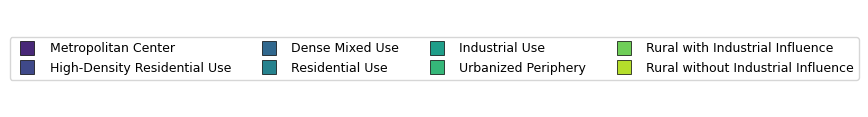

In [661]:
# ========= 1) Standalone legend for area types =========
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Inputs
# category_color_dict = {"Metropolitan Center":"#482878", ...}
legend_labels = list(category_color_dict.keys())
legend_colors = [category_color_dict[k] for k in legend_labels]

# Build handles
handles = [
    Line2D([0], [0], marker="s", linestyle="", color="w",
           markerfacecolor=c, markeredgewidth=0.5, markeredgecolor="black",
           markersize=10)
    for c in legend_colors
]

# Create a compact legend figure
fig_leg = plt.figure(figsize=(8, 1.0))  # width and height as you need
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis("off")

fig_leg.legend(
    handles, legend_labels,
    loc="center",
    ncol=4,                       # adjust number of columns
    frameon=True,
    fontsize=9
)

fig_leg.tight_layout(pad=0.1)
# Save if needed
# fig_leg.savefig("legend_area_types.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
fig_leg.savefig("legend_area_types.svg", bbox_inches="tight", pad_inches=0.02)
plt.show()


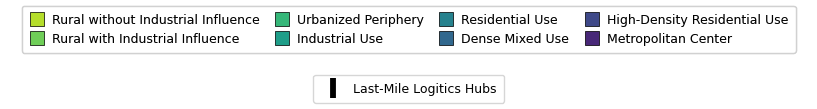

In [750]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Inputs: category_color_dict = {"Metropolitan Center":"#482878", ...}
labels_area = list(category_color_dict.keys())[::-1]
colors_area = [category_color_dict[k] for k in labels_area]

# Square handles for area types
handles_area = [
    Line2D([0], [0],
           marker="s", linestyle="", color="w",
           markerfacecolor=c, markeredgewidth=0.5, markeredgecolor="black",
           markersize=10)
    for c in colors_area
]

# Black line handle for LSP Hub
# vertical hub handle
hub_handle = Line2D(
    [0], [0],
    marker="|", linestyle="",
    color="black",
    markersize=14,       # height of the vertical bar in legend
    markeredgewidth=4.2  # thickness of the bar
)
hub_label = "Last-Mile Logitics Hubs"

# Figure
fig = plt.figure(figsize=(8, 0.925))
ax = fig.add_subplot(111)
ax.axis("off")

# Top legend  two rows of four  centered
leg1 = fig.legend(
    handles_area, labels_area,
    loc="upper center",
    ncol=4,
    frameon=True,
    fontsize=9,
    handlelength=1.2,
    handletextpad=0.6,
    columnspacing=1.2,
    borderpad=0.6
)
ax.add_artist(leg1)

# Bottom legend  single centered entry for hub
fig.legend(
    [hub_handle], [hub_label],
    loc="lower center",
    ncol=1,
    frameon=True,
    fontsize=9,
    handlelength=2.0,
    handletextpad=0.6,
    borderpad=0.6
)

fig.tight_layout(pad=0.1)
fig.savefig("legend_area_types_2x4_plus_hub.svg", bbox_inches="tight", pad_inches=0.02)
plt.show()


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46744\2486949398.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.get_cmap(cmap_name))


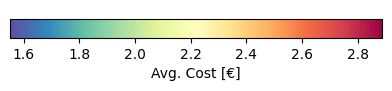

In [662]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import LinearLocator, FormatStrFormatter

cmap_name = "Spectral_r"

fig_cb, ax_cb = plt.subplots(figsize=(4.8, 0.6))  # wide and low
ax_cb.axis("off")

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.get_cmap(cmap_name))
sm.set_array([])

cbar = fig_cb.colorbar(
    sm, ax=ax_cb,
    orientation="horizontal",
    fraction=1.0, pad=0.2
)
cbar.set_label("Avg. Cost [€]", labelpad=4)

# # exactly 8 ticks
# cbar.locator = LinearLocator(numticks=8)
# cbar.formatter = FormatStrFormatter("%.2f")
# cbar.update_ticks()

# optional place ticks and label at bottom
cbar.ax.xaxis.set_ticks_position("bottom")
cbar.ax.xaxis.set_label_position("bottom")

# save as SVG
mpl.rcParams["svg.fonttype"] = "none"
fig_cb.savefig("colorbar_costs.svg", format="svg",
               bbox_inches="tight", pad_inches=0.02, transparent=True)
plt.show()


In [856]:
hubs

,X,Y,Anbieter,Bezeichnun,Typ,Straße,Postleitzahl,Ort
0,559605.059550,5.801323e+06,DHL,Paketzentrum / Zustellbasis Anderten,PZ/ZB,Kleiner Holzhägen 2,30559,Hannover_Anderten
1,549686.455778,5.804338e+06,DHL,Zustellbasis Hannover am Güterbahnhof,ZB,Gertrud-Knebusch-Straße 11,30167,Hannover_Güterbahnhof
2,548255.731128,5.800066e+06,DHL,Zustellbasis Hannover-Süd,ZB,Mercedesstraße 5,30453,Hannover_Süd
3,553326.446313,5.790296e+06,DHL,Brief- und Logistikzentrum in Pattensen (Hanno...,BZ,Ludwig-Erhard-Str. 39,30982,Pattensen
4,532555.807673,5.817483e+06,DP/DHL,"Deutsche Post, Neustadt",ZSP,Justus-von-Liebig-Straße,31535,Neustadt_am_Rübenberge
5,538668.436409,5.811042e+06,DP/DHL,"Deutsche Post, Garbsen",ZSP,Molkereistraße 13,30826,Garbsen
6,547039.230776,5.811060e+06,Hermes,Hermes LC Hannover Langenhagen,PZ,Münchner Str. 39,30855,Langenhagen
7,538731.347746,5.808451e+06,Amazon,Amazon Logistics HAJ8 in Garbsen,PZ,Grabenfeldstraße,30826,Garbsen
8,564735.633715,5.804057e+06,DPD,DPD Paketzentrum in Lehrte,PZ,Europastraße 1,31275,Lehrte
9,555795.773975,5.792960e+06,GLS,GLS in Hannover Laatzen,PZ,Koldinger Straße 1,30880,Laatzen


EPSG:4326


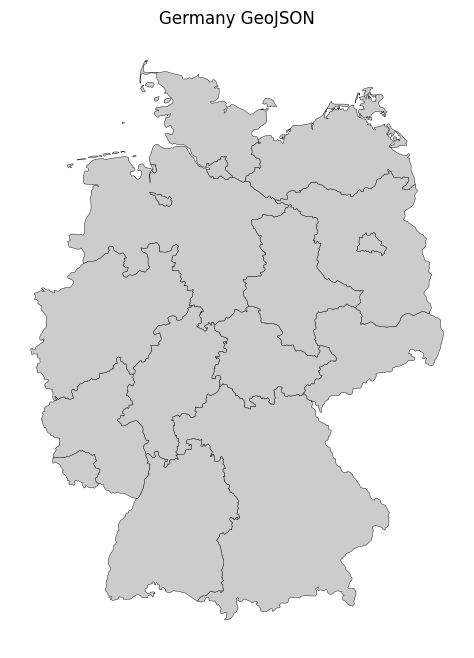

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

# GeoJSON einlesen
gdf_de = gpd.read_file("de.json")

# CRS prüfen
print(gdf_de.crs)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
gdf_de.plot(ax=ax, color="#cccccc", edgecolor="black", linewidth=0.3)

ax.set_title("Germany GeoJSON")
ax.set_axis_off()
plt.show()


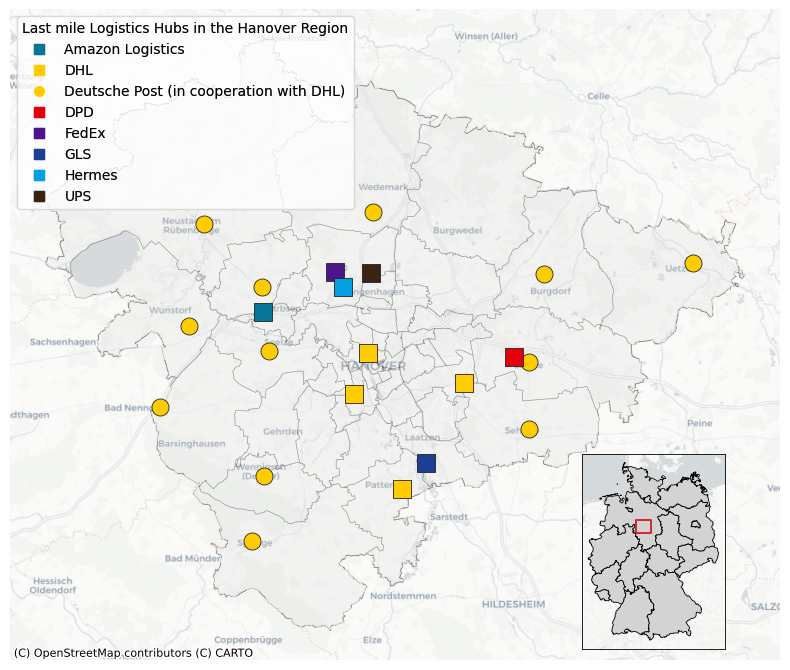

In [17]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import contextily as ctx
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as mpatches


# Fixed provider colors
prov_colors = {
    "dhl":    "#FFCC00",
    "dp/dhl": "#FFCC00",
    "dpd":    "#E3000B",
    "gls":    "#1C3F95",
    "ups":    "#392312",
    "hermes": "#00A0E1",
    "amazon": "#077498",
    "fedex":  "#4D148C",
    "other":  "#7f7f7f"
}

# Marker mapping
prov_markers = {
    "dhl": "s",
    "dp/dhl": "o",
    "dpd": "s",
    "gls": "s",
    "ups": "s",
    "hermes": "s",
    "amazon": "s",
    "fedex": "s",
    "other": "s"
}

# Legend labels
prov_labels = {
    "dhl": "DHL",
    "dp/dhl": "Deutsche Post (in cooperation with DHL)",
    "dpd": "DPD",
    "gls": "GLS",
    "ups": "UPS",
    "hermes": "Hermes",
    "amazon": "Amazon Logistics",
    "fedex": "FedEx",
    "other": "Other"
}

# Normalize X Y if needed
if "# X" in hubs.columns and "# Y" in hubs.columns:
    hubs = hubs.rename(columns={"# X": "X", "# Y": "Y"})

# Build GeoDataFrame for hubs (assume EPSG:25832)
hub_geom = [Point(float(x), float(y)) for x, y in zip(hubs["X"], hubs["Y"])]
hubs_gdf = gpd.GeoDataFrame(hubs.copy(), geometry=hub_geom, crs="EPSG:25832")

# Ensure areas have CRS, then project both to Web Mercator for tiles
if gdf_areas.crs is None:
    gdf_areas = gdf_areas.set_crs(epsg=25832)
gdf_areas_3857 = gdf_areas.to_crs(epsg=3857)
hubs_gdf_3857 = hubs_gdf.to_crs(epsg=3857)

hubs_sorted = hubs_gdf_3857.sort_values(["Anbieter"]) 
hubs_sorted["hub_id"] = np.arange(1, len(hubs_sorted) + 1)

# Classify provider to keys
def provider_key(raw: str) -> str:
    s = str(raw).strip().lower()
    if "dp/dhl" in s or s.startswith("dp ") or s == "dp" or "deutsche post" in s:
        return "dp/dhl"
    if "dhl" in s or "wl" in s:
        return "dhl"
    if "dpd" in s:
        return "dpd"
    if "gls" in s:
        return "gls"
    if "ups" in s:
        return "ups"
    if "hermes" in s:
        return "hermes"
    if "amazon" in s:
        return "amazon"
    if "fedex" in s:
        return "fedex"
    return "other"

hubs_sorted["prov_key"] = hubs_sorted["Anbieter"].apply(provider_key)

# Plot main map
fig, ax = plt.subplots(figsize=(8, 8))

gdf_areas_3857.plot(
    ax=ax,
    color="#dddddd",
    alpha=0.25,
    edgecolor="black",
    linewidth=0.4,
    zorder=1
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=gdf_areas_3857.crs.to_string(),
    attribution_size=8,
    zorder=0
)

present_keys = list(np.unique(hubs_sorted["prov_key"]))
for k in present_keys:
    sub = hubs_sorted[hubs_sorted["prov_key"] == k]
    ax.scatter(
        sub.geometry.x, sub.geometry.y,
        marker=prov_markers.get(k, "o"),
        facecolor=prov_colors.get(k, prov_colors["other"]),
        edgecolor="#222222",
        linewidth=0.6,
        s=150,
        zorder=3,
        label=prov_labels.get(k, k)
    )
    
# import matplotlib.patheffects as pe
# for _, r in hubs_sorted.iterrows():
#     provider = r["prov_key"]
#     fontcolor = "black" if provider in ["dhl", "dp/dhl"] else "white"

#     ax.text(
#         r.geometry.x, r.geometry.y,
#         str(int(r["hub_id"])),
#         fontsize=8,
#         ha="center", va="center",
#         zorder=4,
#         color=fontcolor
#     )

handles = [
    mlines.Line2D([], [], color=prov_colors.get(k, prov_colors["other"]),
                  marker=prov_markers.get(k, "o"),
                  linestyle="", markersize=7)
    for k in present_keys
]
labels = [prov_labels.get(k, k) for k in present_keys]
leg = ax.legend(handles, labels, title="Last mile Logistics Hubs in the Hanover Region",
                loc="upper left", frameon=True, framealpha=0.5)
ax.add_artist(leg)

ax.get_yaxis().set_visible(False)
ax.get_xaxis().set_visible(False)
for s in ["left", "bottom", "right", "top"]:
    ax.spines[s].set_visible(False)

ax.set_aspect("equal", adjustable="box")
plt.tight_layout()

# -------- Inset map of Germany using your existing 'germany' --------
# Ensure CRS and project to 3857
if gdf_de.crs is None:
    # set to your known source CRS if needed, else assume WGS84
    gdf_de = gdf_de.set_crs(epsg=4326)
gdf_de_3857 = gdf_de.to_crs(epsg=3857)

# Region bbox from main map
minx, miny, maxx, maxy = gdf_areas_3857.total_bounds
region_rect = gpd.GeoDataFrame({"geometry": [box(minx, miny, maxx, maxy)]}, crs=gdf_areas_3857.crs)

# Inset axes
ax_in = inset_axes(ax, width="30%", height="30%", loc="lower right", borderpad=0.8)

# Germany outline
gdf_de_3857.plot(ax=ax_in,  facecolor="lightgray", edgecolor="black", linewidth=0.6, zorder=1)

# Basemap without labels for clarity
try:
    ctx.add_basemap(
        ax_in,
        source=ctx.providers.CartoDB.PositronNoLabels,
        crs=gdf_de_3857.crs.to_string(),
        attribution=False,
        zorder=0
    )
except Exception:
    pass

# Draw region bbox
region_rect.boundary.plot(ax=ax_in, edgecolor="#d62728", linewidth=1.4, zorder=2)

# Fit inset to Germany extent with small padding
gxmin, gymin, gxmax, gymax = gdf_de_3857.total_bounds
padx = (gxmax - gxmin) * 0.05
pady = (gymax - gymin) * 0.05
ax_in.set_xlim(gxmin - padx, gxmax + padx)
ax_in.set_ylim(gymin - pady, gymax + pady)

# Inset styling
ax_in.set_xticks([])
ax_in.set_yticks([])
for s in ["left", "bottom", "right", "top"]:
    ax_in.spines[s].set_visible(True)
    ax_in.spines[s].set_linewidth(0.6)
    ax_in.spines[s].set_edgecolor("black")
    

        
# fig.savefig("logistics_hubs_mobiltum.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02, transparent=True)

plt.show()


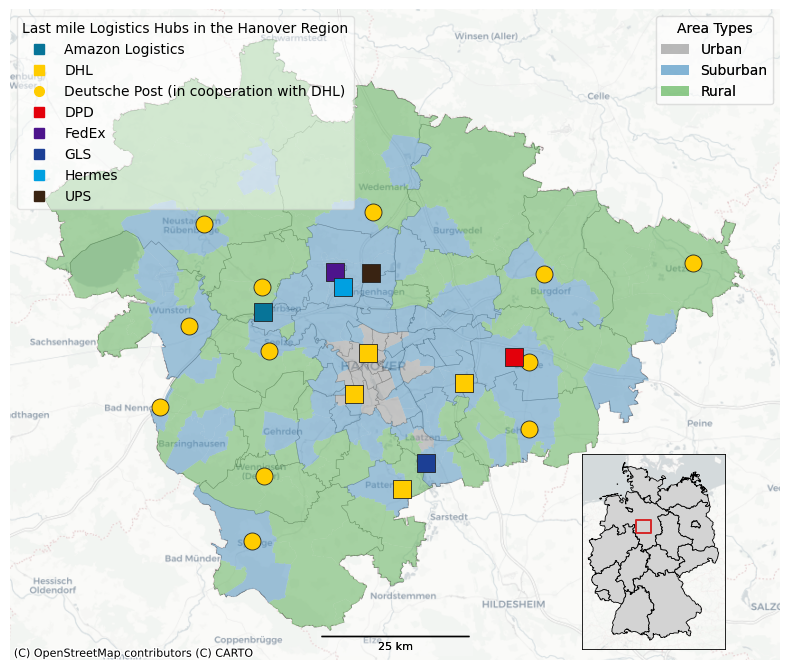

In [35]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import contextily as ctx
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as mpatches# add near the other imports
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.font_manager import FontProperties

# place this block just before fig.savefig(...)
# --- Dynamic scalebar in meters for EPSG:3857 ---

def add_dynamic_scalebar(ax, location='lower left'):
    # Map extent in data units (meters in EPSG:3857)
    x0, x1 = ax.get_xlim()
    width_m = float(abs(x1 - x0))

    # Target bar length as a fraction of map width
    target = width_m * 0.25

    # Nice candidate lengths in meters
    nice_lengths_km = np.array([0.2, 0.5, 1, 2, 5, 10, 20, 25, 50, 100])
    lengths_m = nice_lengths_km * 1000.0
    bar_len_m = float(lengths_m[np.argmin(np.abs(lengths_m - target))])

    # Label as km with minimal trailing zeros
    label_km = bar_len_m / 1000.0
    label_str = f"{label_km:g} km"

    fp = FontProperties(size=8, weight='regular')

    scalebar = AnchoredSizeBar(
        transform=ax.transData,
        size=bar_len_m,                 # length of the bar in data units
        label=label_str,
        loc=location,                   # 'lower left', 'lower right', etc.
        pad=0.4,
        borderpad=0.4,
        sep=4,
        frameon=False,
        color='black',                  # bar and label color
        fontproperties=fp,              # set font via constructor for compatibility
        fill_bar=True                   # draw a filled bar
    )

    ax.add_artist(scalebar)

    # Add white translucent background rectangle behind the scalebar
    # Determine position of the bar in pixel coordinates
    renderer = ax.figure.canvas.get_renderer()
    bbox = scalebar.get_tightbbox(renderer)
    inv = ax.transAxes.inverted()
    bbox_axes = mpatches.Rectangle(
        (bbox.x0 / ax.figure.bbox.width, bbox.y0 / ax.figure.bbox.height),
        (bbox.width / ax.figure.bbox.width),
        (bbox.height / ax.figure.bbox.height),
        transform=ax.figure.transFigure,
        facecolor='white',
        alpha=0.2,
        zorder=scalebar.zorder - 1,
        linewidth=0,
    )
    ax.add_artist(bbox_axes)

    # Re-add scalebar on top (to ensure it’s drawn over the background)
    ax.add_artist(scalebar)


# Fixed provider colors
prov_colors = {
    "dhl":    "#FFCC00",
    "dp/dhl": "#FFCC00",
    "dpd":    "#E3000B",
    "gls":    "#1C3F95",
    "ups":    "#392312",
    "hermes": "#00A0E1",
    "amazon": "#077498",
    "fedex":  "#4D148C",
    "other":  "#7f7f7f"
}

# Marker mapping
prov_markers = {
    "dhl": "s",
    "dp/dhl": "o",
    "dpd": "s",
    "gls": "s",
    "ups": "s",
    "hermes": "s",
    "amazon": "s",
    "fedex": "s",
    "other": "s"
}

# Legend labels
prov_labels = {
    "dhl": "DHL",
    "dp/dhl": "Deutsche Post (in cooperation with DHL)",
    "dpd": "DPD",
    "gls": "GLS",
    "ups": "UPS",
    "hermes": "Hermes",
    "amazon": "Amazon Logistics",
    "fedex": "FedEx",
    "other": "Other"
}

# Normalize X Y if needed
if "# X" in hubs.columns and "# Y" in hubs.columns:
    hubs = hubs.rename(columns={"# X": "X", "# Y": "Y"})

# Build GeoDataFrame for hubs (assume EPSG:25832)
hub_geom = [Point(float(x), float(y)) for x, y in zip(hubs["X"], hubs["Y"])]
hubs_gdf = gpd.GeoDataFrame(hubs.copy(), geometry=hub_geom, crs="EPSG:25832")

# Ensure areas have CRS, then project both to Web Mercator for tiles
if gdf_areas.crs is None:
    gdf_areas = gdf_areas.set_crs(epsg=25832)
gdf_areas_3857 = gdf_areas.to_crs(epsg=3857)
hubs_gdf_3857 = hubs_gdf.to_crs(epsg=3857)

hubs_sorted = hubs_gdf_3857.sort_values(["Anbieter"]) 
hubs_sorted["hub_id"] = np.arange(1, len(hubs_sorted) + 1)

# Classify provider to keys
def provider_key(raw: str) -> str:
    s = str(raw).strip().lower()
    if "dp/dhl" in s or s.startswith("dp ") or s == "dp" or "deutsche post" in s:
        return "dp/dhl"
    if "dhl" in s or "wl" in s:
        return "dhl"
    if "dpd" in s:
        return "dpd"
    if "gls" in s:
        return "gls"
    if "ups" in s:
        return "ups"
    if "hermes" in s:
        return "hermes"
    if "amazon" in s:
        return "amazon"
    if "fedex" in s:
        return "fedex"
    return "other"

hubs_sorted["prov_key"] = hubs_sorted["Anbieter"].apply(provider_key)

# Plot main map
fig, ax = plt.subplots(figsize=(8, 8))

gdf_areas_3857.plot(
    ax=ax,
    color="#dddddd",
    alpha=0.25,
    edgecolor="black",
    linewidth=0.4,
    zorder=1
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=gdf_areas_3857.crs.to_string(),
    attribution_size=8,
    zorder=0
)

present_keys = list(np.unique(hubs_sorted["prov_key"]))
for k in present_keys:
    sub = hubs_sorted[hubs_sorted["prov_key"] == k]
    ax.scatter(
        sub.geometry.x, sub.geometry.y,
        marker=prov_markers.get(k, "o"),
        facecolor=prov_colors.get(k, prov_colors["other"]),
        edgecolor="#222222",
        linewidth=0.6,
        s=150,
        zorder=3,
        label=prov_labels.get(k, k)
    )
    
# import matplotlib.patheffects as pe
# for _, r in hubs_sorted.iterrows():
#     provider = r["prov_key"]
#     fontcolor = "black" if provider in ["dhl", "dp/dhl"] else "white"

#     ax.text(
#         r.geometry.x, r.geometry.y,
#         str(int(r["hub_id"])),
#         fontsize=8,
#         ha="center", va="center",
#         zorder=4,
#         color=fontcolor
#     )

handles = [
    mlines.Line2D([], [], color=prov_colors.get(k, prov_colors["other"]),
                  marker=prov_markers.get(k, "o"),
                  linestyle="", markersize=7)
    for k in present_keys
]
labels = [prov_labels.get(k, k) for k in present_keys]
leg = ax.legend(handles, labels, title="Last mile Logistics Hubs in the Hanover Region",
                loc="upper left", frameon=True, framealpha=0.5)
ax.add_artist(leg)

ax.get_yaxis().set_visible(False)
ax.get_xaxis().set_visible(False)
for s in ["left", "bottom", "right", "top"]:
    ax.spines[s].set_visible(False)

ax.set_aspect("equal", adjustable="box")
plt.tight_layout()

# -------- Inset map of Germany using your existing 'germany' --------
# Ensure CRS and project to 3857
if gdf_de.crs is None:
    # set to your known source CRS if needed, else assume WGS84
    gdf_de = gdf_de.set_crs(epsg=4326)
gdf_de_3857 = gdf_de.to_crs(epsg=3857)

# Region bbox from main map
minx, miny, maxx, maxy = gdf_areas_3857.total_bounds
region_rect = gpd.GeoDataFrame({"geometry": [box(minx, miny, maxx, maxy)]}, crs=gdf_areas_3857.crs)

# Inset axes
ax_in = inset_axes(ax, width="30%", height="30%", loc="lower right", borderpad=0.8)

# Germany outline
gdf_de_3857.plot(ax=ax_in,  facecolor="lightgray", edgecolor="black", linewidth=0.6, zorder=1)

# Basemap without labels for clarity
try:
    ctx.add_basemap(
        ax_in,
        source=ctx.providers.CartoDB.PositronNoLabels,
        crs=gdf_de_3857.crs.to_string(),
        attribution=False,
        zorder=0
    )
except Exception:
    pass

# Draw region bbox
region_rect.boundary.plot(ax=ax_in, edgecolor="#d62728", linewidth=1.4, zorder=2)

# Fit inset to Germany extent with small padding
gxmin, gymin, gxmax, gymax = gdf_de_3857.total_bounds
padx = (gxmax - gxmin) * 0.05
pady = (gymax - gymin) * 0.05
ax_in.set_xlim(gxmin - padx, gxmax + padx)
ax_in.set_ylim(gymin - pady, gymax + pady)

# Inset styling
ax_in.set_xticks([])
ax_in.set_yticks([])
for s in ["left", "bottom", "right", "top"]:
    ax_in.spines[s].set_visible(True)
    ax_in.spines[s].set_linewidth(0.6)
    ax_in.spines[s].set_edgecolor("black")
    

category_color_dict_agg = {
    'Urban': '#808080',      # Grau
    'Suburban': '#1f78b4',  # Blau
    'Rural': '#33a02c'       # Grün
}
# colors for the groups (tweak as you like)

area_alpha = 0.4

regionclusters_3857 = regionclusters.to_crs(epsg=3857)


# make sure plotting order doesn't hide basemap (plot areas at zorder=0.5 so basemap=0, areas above basemap but behind hubs)
for grp in ['Rural', 'Suburban', 'Urban', 'All']:
    sub = regionclusters_3857[regionclusters_3857['area_type_agg'] == grp]
    if len(sub):
        sub.plot(ax=ax, color=category_color_dict_agg.get(grp, '#cccccc'), alpha=area_alpha,
                 edgecolor=None, linewidth=0.0, zorder=1)  # zorder=1 (below hubs which use zorder=3)

# add a small legend for area groups (patches)
patches = []
for grp in ['Urban', 'Suburban', 'Rural']:
    patches.append(mpatches.Patch(facecolor=category_color_dict_agg.get(grp, '#cccccc'),
                                 edgecolor='none',
                                 alpha=area_alpha,
                                 label=grp))
if patches:
    leg2 = ax.legend(handles=patches, title='Area Types', loc='upper right',
                     frameon=True, framealpha=0.4)
    ax.add_artist(leg2)
    
add_dynamic_scalebar(ax, location='lower center')
# Slight shadow effect under the bar label to improve readability
try:
    import matplotlib.patheffects as pe
    for artist in ax.artists:
        if isinstance(artist, AnchoredSizeBar):
            artist.txt_label.set_path_effects([pe.withStroke(linewidth=2, foreground='white')])
except Exception:
    pass
        
fig.savefig("logistics_hubs_mobiltum.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02, transparent=True)

plt.show()
